# At this time, in this eda, we are analysing below lists before finalizing our dataset

### Datasets:
1. Tiny ImageNet,
3. ImageNet-21K-P Winter21

| **Stage** | **Analysis Area**             | **Detailed Analysis Steps**                                                                                                                                                                               | **Status**        |
|----------:| ----------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |-------------------|
|     **A** | **Dataset Structure**         | **1.** Dataset Overview / Summary  <br> **2.** Dataset Split Analysis                                                                                                                                     | Done              |
|     **B** | **Class Analysis**            | **3.** Class / Synset Analysis  <br> **4.** Images per Class Analysis  <br> **5.** Class Distribution and Class Imbalance Analysis  <br> **6.** Class Coverage Across Splits                              | Done   |
|     **C** | **Image Properties**          | **7.** Image Dimensions Analysis  <br> **8.** Aspect Ratio Distribution  <br> **9.** Image Mode / Channel Analysis  <br> **10.** RGB Mean and Standard Deviation  <br> **11.** Pixel Intensity Statistics | Done           |
|     **D** | **Image Quality**             | **12.** Brightness, Contrast and Sharpness Analysis                                                                                                                                                       | Done           |
|     **E** | **Anomalies / Leakage**       | **13.** Statistical Outlier Detection  <br> **14.** Corrupted Image Detection  <br> **15.** Duplicate Image and Data Leakage Detection                                                                    | Done           |
|     **F** | **Class Variation**           | **16.** Intra-Class Variation Analysis  <br> **17.** Inter-Class Variation Analysis                                                                                                                       | Done           |
|     **G** | **Dataset Difficulty**        | **18.** Dataset Difficulty Comparison                                                                                                                                                                     | Done           |

## Imports

In [1]:
from src.dataset.tiny_imagenet_dataset import TinyImageNetLoader, TINY_ROOT
from src.dataset.imagenet21k_p_dataset import ImageNet21KPLoader, IMAGENET21K_P_ROOT

from src.eda.dataset_structure import dataset_summary, train_test_split_analysis
from src.eda.class_analysis import class_analysis, images_per_class_analysis, class_distribution_analysis

/Users/sumanneupane/Documents/MIT in AI/Semister 4/cnn_vs_pc_cnn/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Dataset

In [2]:
tiny_imagenet = TinyImageNetLoader(
    seed=42
).load()

In [4]:
imagenet_21k_p = ImageNet21KPLoader(
    mode="sample",
    sample_classes=200,
    train_images_per_class=None,
    seed=42,
).load()


ImageNet-21K-P Winter21 Sample
-------------------------------------------------------
Classes               : 200
Train images/class    : ALL
Expected train        : depends on selected classes
Validation/class      : 50
Expected validation   : 10,000
Output folder         : data/imagenet21k_p/images
-------------------------------------------------------


Building ImageNet-21K-P sample: 100%|██████████| 200/200 [00:01<00:00, 187.59class/s, wnid=n14765422]


In [5]:
dataset_list = [
    tiny_imagenet,
    imagenet_21k_p,
]

## A. Dataset Structure

#### 1. Dataset Overview / Summary

In [6]:
overview = dataset_summary.dataset_overview(dataset_list=dataset_list)
overview

,Dataset,Train Images,Validation Images,Test Images,Total Images,Number of Classes
0,tiny_imagenet,100000,10000,10000,120000,200
1,imagenet21k_p,203329,5000,5000,213329,200


#### 2. Train, Validation and Test Split Analysis

In [7]:
split_analysis = train_test_split_analysis.dataset_split_analysis(dataset_list=dataset_list)

split_analysis

,Dataset,Train Images,Train %,Validation Images,Validation %,Test Images,Test %,Total Images
0,tiny_imagenet,100000,83.33,10000,8.33,10000,8.33,120000
1,imagenet21k_p,203329,95.31,5000,2.34,5000,2.34,213329


## B. Class Analysis

#### 3. Number of Classes / Class-Synset Mapping Analysis

In [8]:
_, class_mappings = class_analysis.class_synset_analysis(dataset_list=dataset_list)

In [9]:
class_mappings["tiny_imagenet"].head(10)

,Class Index,Class / Synset ID,Class Name
0,0,n01443537,"[goldfish, Carassius auratus]"
1,1,n01629819,"[European fire salamander, Salamandra salaman..."
2,2,n01641577,"[bullfrog, Rana catesbeiana]"
3,3,n01644900,"[tailed frog, bell toad, ribbed toad, taile..."
4,4,n01698640,"[American alligator, Alligator mississipiensis]"
5,5,n01742172,"[boa constrictor, Constrictor constrictor]"
6,6,n01768244,[trilobite]
7,7,n01770393,[scorpion]
8,8,n01774384,"[black widow, Latrodectus mactans]"
9,9,n01774750,[tarantula]


In [11]:
class_mappings["imagenet21k_p"].head(10)

,Class Index,Class / Synset ID,Class Name
0,0,n00288000,dressage
1,1,n00448748,figure_skating
2,2,n00468480,football
3,3,n01339801,cytomegalovirus
4,4,n01535690,white-crowned_sparrow
5,5,n01543632,Java_sparrow
6,6,n01568294,American_redstart
7,7,n01574801,rusty_blackbird
8,8,n01593028,bushtit
9,9,n01605630,hawk


#### 4. Images per Class Analysis

In [12]:
images_per_class, class_counts = images_per_class_analysis.images_per_class_analysis(dataset_list=dataset_list)

images_per_class

,Dataset,Split,Label Status,Total Images,Classes,Min Images/Class,Max Images/Class,Mean Images/Class,Median Images/Class,Std Images/Class
0,tiny_imagenet,Train,Labelled,100000,200,500,500,500.0,500.0,0.0
1,tiny_imagenet,Validation,Labelled,10000,200,50,50,50.0,50.0,0.0
2,tiny_imagenet,Test,Unlabelled,10000,N/A,N/A,N/A,N/A,N/A,N/A
3,imagenet21k_p,Train,Labelled,203329,200,454,2419,1016.64,1063.0,340.67
4,imagenet21k_p,Validation,Labelled,5000,200,25,25,25.0,25.0,0.0
5,imagenet21k_p,Test,Labelled,5000,200,25,25,25.0,25.0,0.0


#### 5. Class Distribution and Class Imbalance Analysis

In [13]:
class_distribution, class_distribution_details = class_distribution_analysis.class_distribution_analysis(
    dataset_list=dataset_list)

class_distribution

,Dataset,Split,Label Status,Total Images,Classes,Min Images/Class,Max Images/Class,Mean Images/Class,Median Images/Class,Std Images/Class,Imbalance Ratio,Coefficient of Variation,Distribution Status
0,tiny_imagenet,Train,Labelled,100000,200,500,500,500.0,500.0,0.0,1.0,0.0,Balanced
1,tiny_imagenet,Validation,Labelled,10000,200,50,50,50.0,50.0,0.0,1.0,0.0,Balanced
2,tiny_imagenet,Test,Unlabelled,10000,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
3,imagenet21k_p,Train,Labelled,203329,200,454,2419,1016.64,1063.0,340.67,5.328,0.335,Imbalanced
4,imagenet21k_p,Validation,Labelled,5000,200,25,25,25.0,25.0,0.0,1.0,0.0,Balanced
5,imagenet21k_p,Test,Labelled,5000,200,25,25,25.0,25.0,0.0,1.0,0.0,Balanced


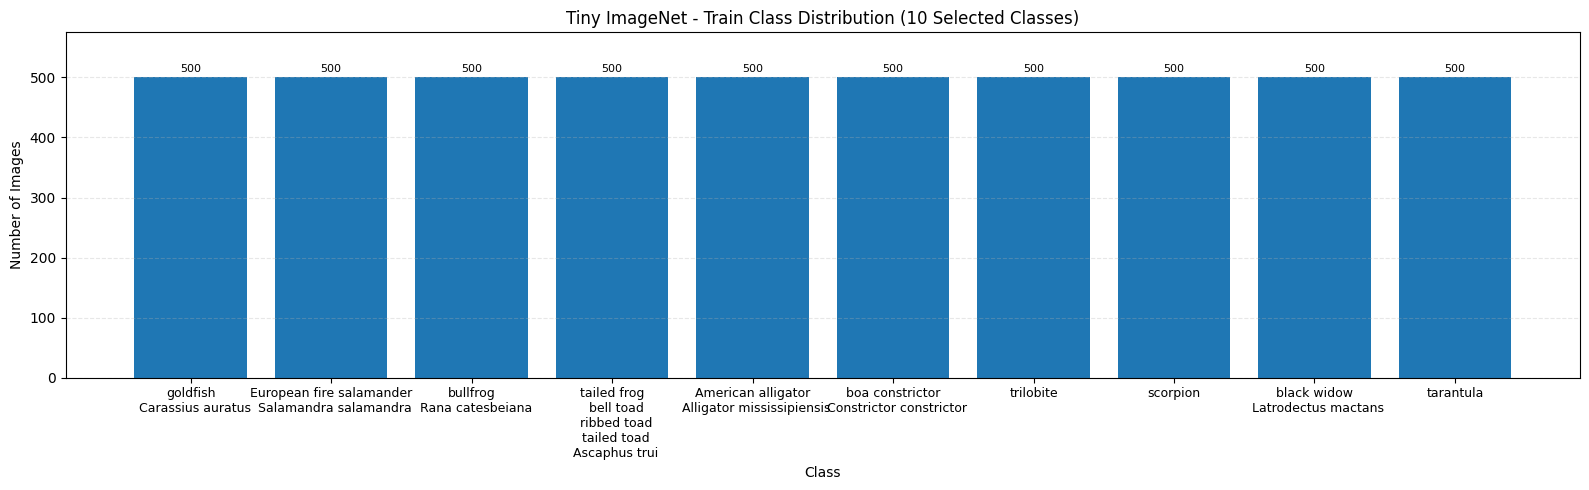

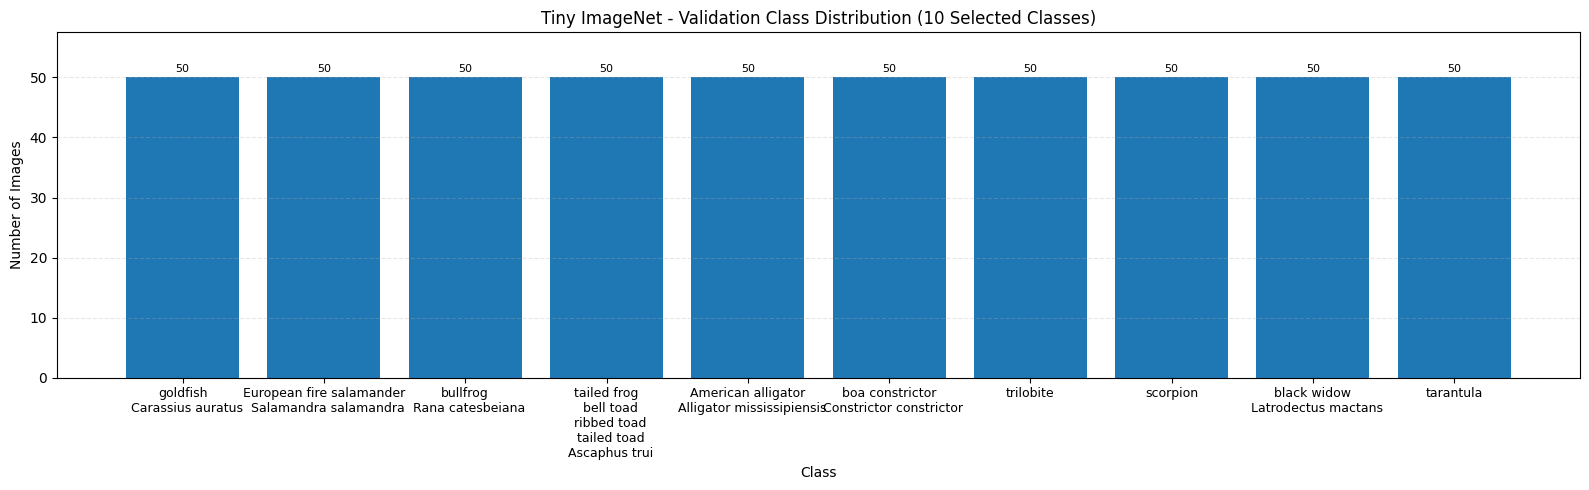

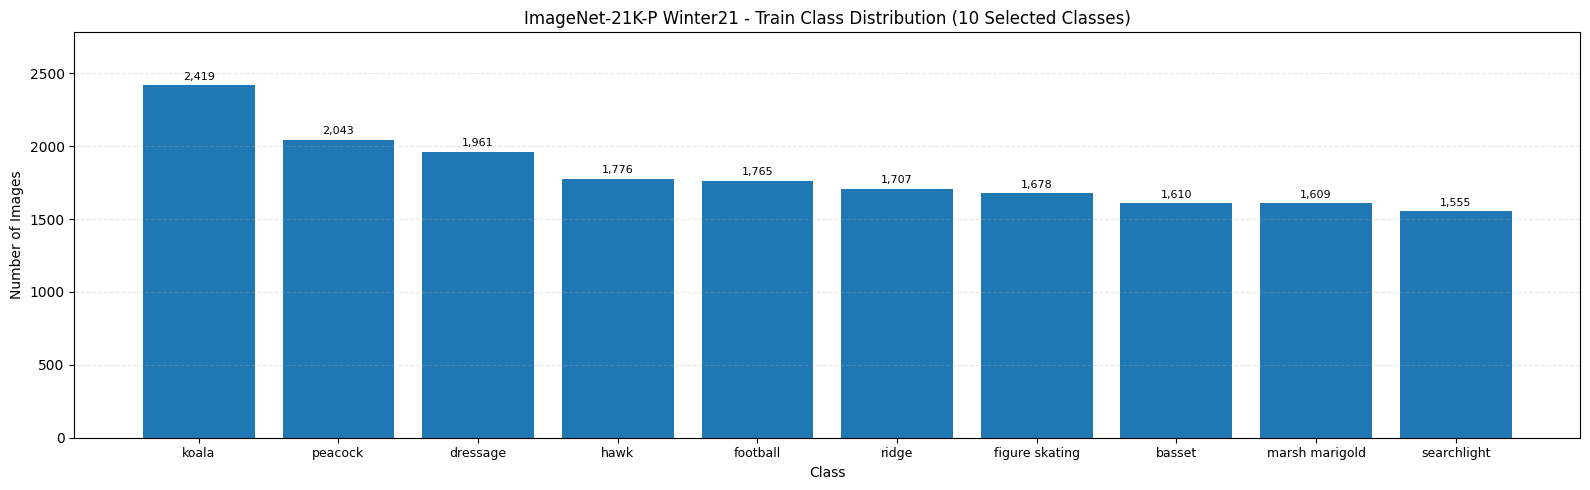

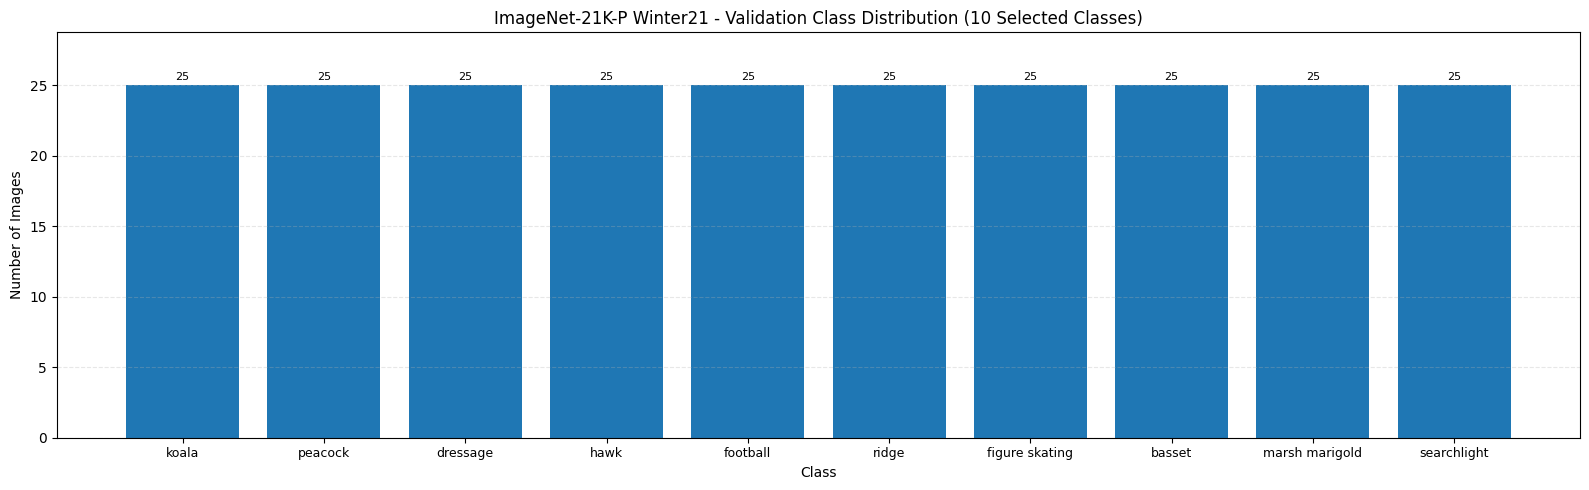

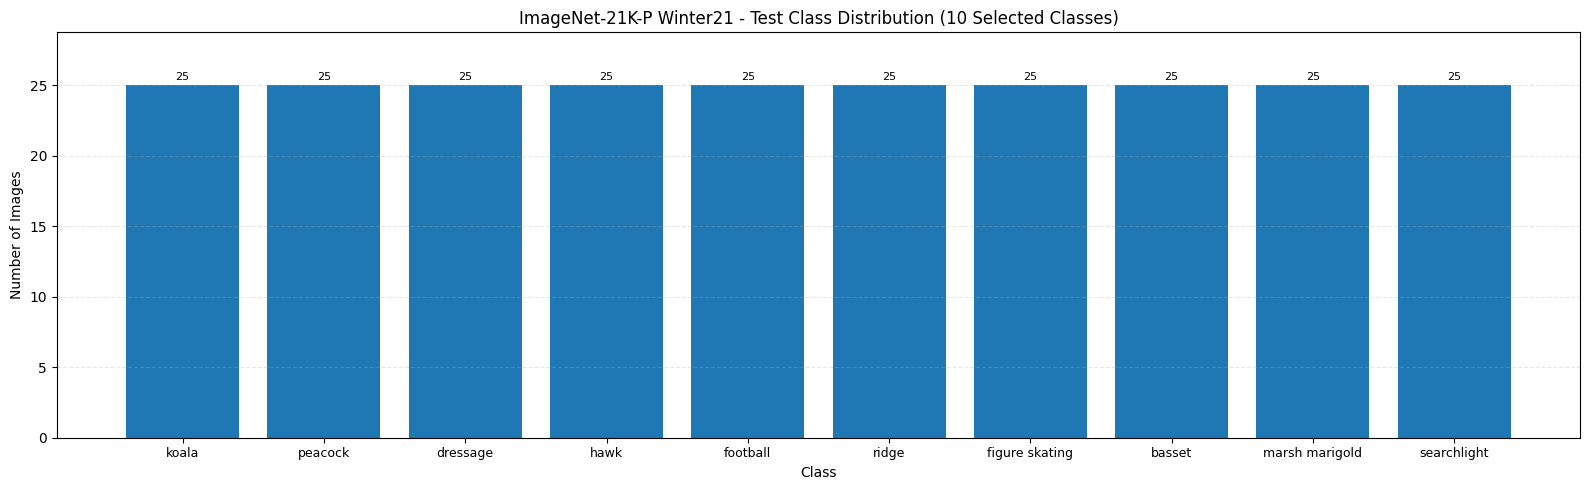

In [14]:
class_distribution_analysis.plot_class_distribution(
    class_distribution_details,
    sample_n=10
)

#### 6. Class Coverage Across Splits

In [15]:
import src.eda.class_analysis.class_coverage_analysis as class_coverage_analysis

class_coverage, class_coverage_details = (
    class_coverage_analysis.class_coverage_analysis(dataset_list=dataset_list)
)

class_coverage

,Dataset,Train Classes,Validation Classes,Test Classes,Validation Coverage (%),Test Coverage (%),All Labelled Splits Coverage (%),Missing in Validation,Missing in Test,Extra in Validation,Extra in Test,Coverage Status
0,tiny_imagenet,200,200,N/A,100.0,N/A,100.0,0,N/A,0,N/A,Complete for Labelled Splits
1,imagenet21k_p,200,200,200,100.0,100.0,100.0,0,0,0,0,Complete


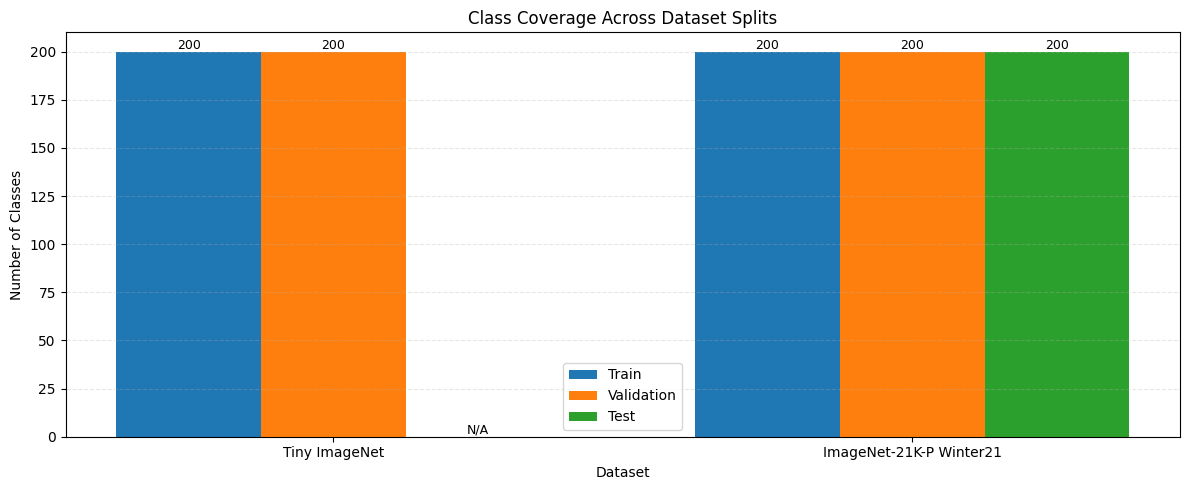

In [16]:
class_coverage_analysis.plot_class_coverage(
    class_coverage
)

## C. Image Properties

#### 7. Image Dimensions Analysis

In [17]:
import src.eda.image_properties.image_dimensions_analysis as image_dimensions_analysis

image_dimensions, image_dimension_details = (
    image_dimensions_analysis.image_dimensions_analysis(
        dataset_list=dataset_list,
        max_images=None,
        seed=42,
    )
)

image_dimensions

  0%|          | 0/2 [00:00<?, ?it/s]

42:tiny_imagenet:Train
42:tiny_imagenet:Validation
42:tiny_imagenet:Test


 50%|█████     | 1/2 [00:20<00:20, 20.10s/it]

42:imagenet21k_p:Train
42:imagenet21k_p:Validation
42:imagenet21k_p:Test


100%|██████████| 2/2 [03:43<00:00, 111.66s/it]


,Dataset,Split,Total Images,Analyzed Images,Skipped Images,Min Width,Max Width,Mean Width,Median Width,Min Height,Max Height,Mean Height,Median Height,Unique Resolutions
0,tiny_imagenet,Train,100000,100000,0,64,64,64.00,64.0,64,64,64.00,64.0,1
1,tiny_imagenet,Validation,10000,10000,0,64,64,64.00,64.0,64,64,64.00,64.0,1
2,tiny_imagenet,Test,10000,10000,0,64,64,64.00,64.0,64,64,64.00,64.0,1
3,imagenet21k_p,Train,203329,203329,0,17,6152,414.56,450.0,25,4992,360.40,359.0,36123
4,imagenet21k_p,Validation,5000,5000,0,37,4272,412.28,419.5,40,3278,358.88,353.0,2236
5,imagenet21k_p,Test,5000,5000,0,50,4992,412.82,426.0,45,3504,357.83,357.0,2216


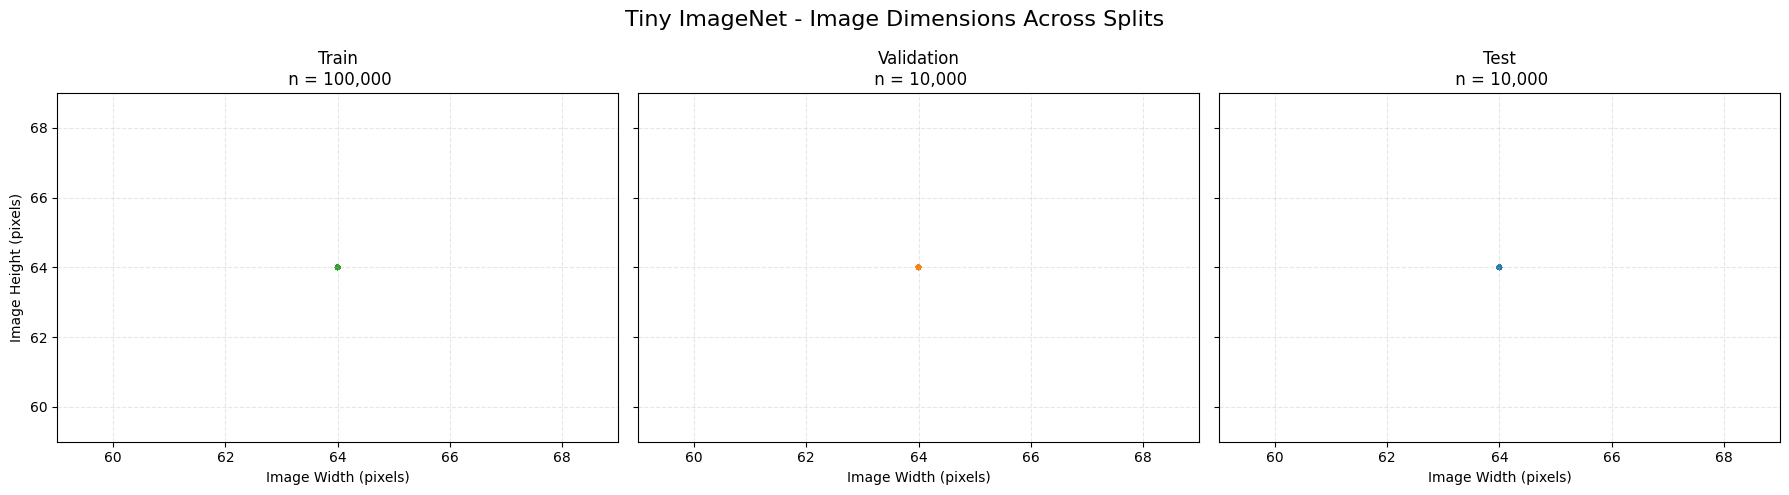

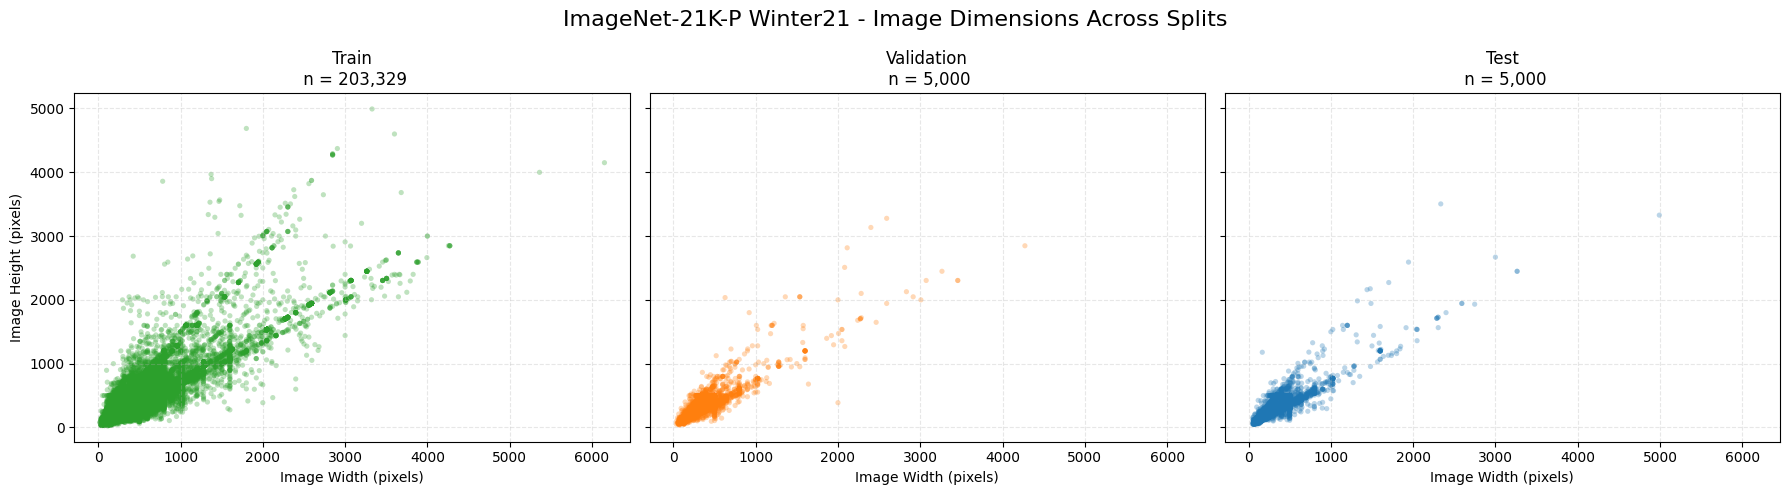

In [18]:
image_dimensions_analysis.plot_image_dimensions(
    image_dimension_details
)

#### 8. Aspect Ratio Distribution

In [19]:
import src.eda.image_properties.aspect_ratio_analysis as aspect_ratio_analysis

aspect_ratio, aspect_ratio_details = (
    aspect_ratio_analysis.aspect_ratio_analysis(
        image_dimension_details
    )
)

aspect_ratio

100%|██████████| 3/3 [00:00<00:00, 89.41it/s]


,Dataset,Split,Analyzed Images,Min Aspect Ratio,Max Aspect Ratio,Mean Aspect Ratio,Median Aspect Ratio,Std Aspect Ratio,Portrait (%),Near Square (%),Landscape (%)
0,tiny_imagenet,Train,100000,1.000,1.000,1.000,1.000,0.000,0.00,100.00,0.00
1,tiny_imagenet,Validation,10000,1.000,1.000,1.000,1.000,0.000,0.00,100.00,0.00
2,tiny_imagenet,Test,10000,1.000,1.000,1.000,1.000,0.000,0.00,100.00,0.00
3,imagenet21k_p,Train,203329,0.100,8.333,1.197,1.333,0.347,24.99,10.16,64.85
4,imagenet21k_p,Validation,5000,0.308,5.155,1.198,1.333,0.353,25.10,10.16,64.74
5,imagenet21k_p,Test,5000,0.142,4.464,1.195,1.333,0.348,25.48,9.52,65.00


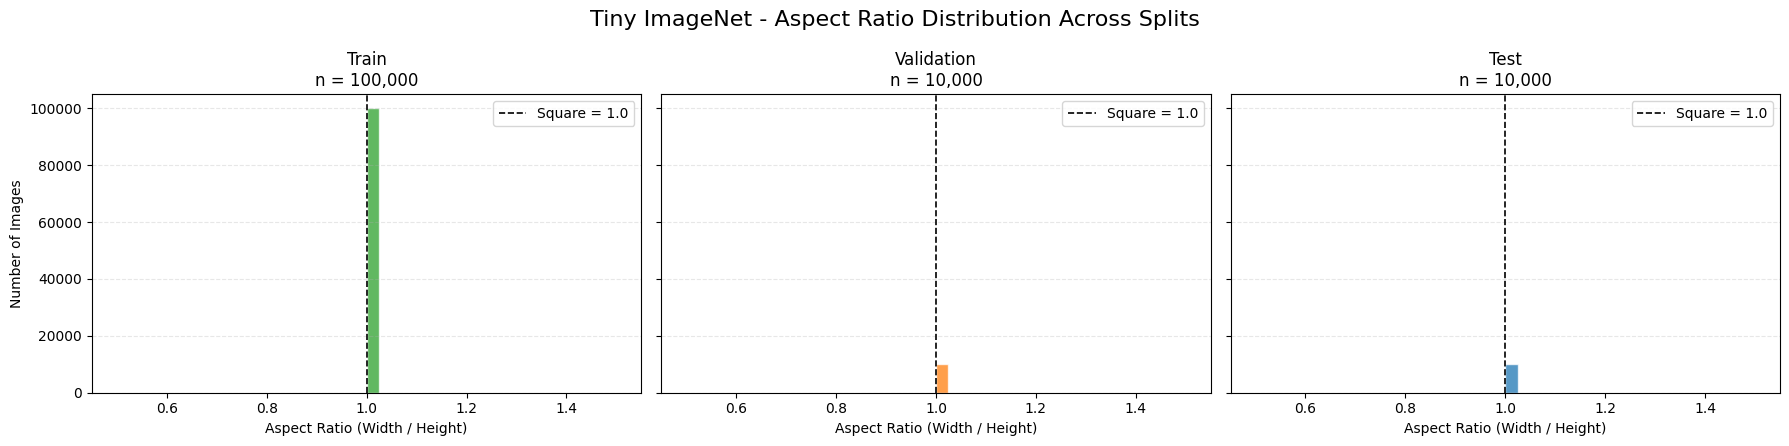

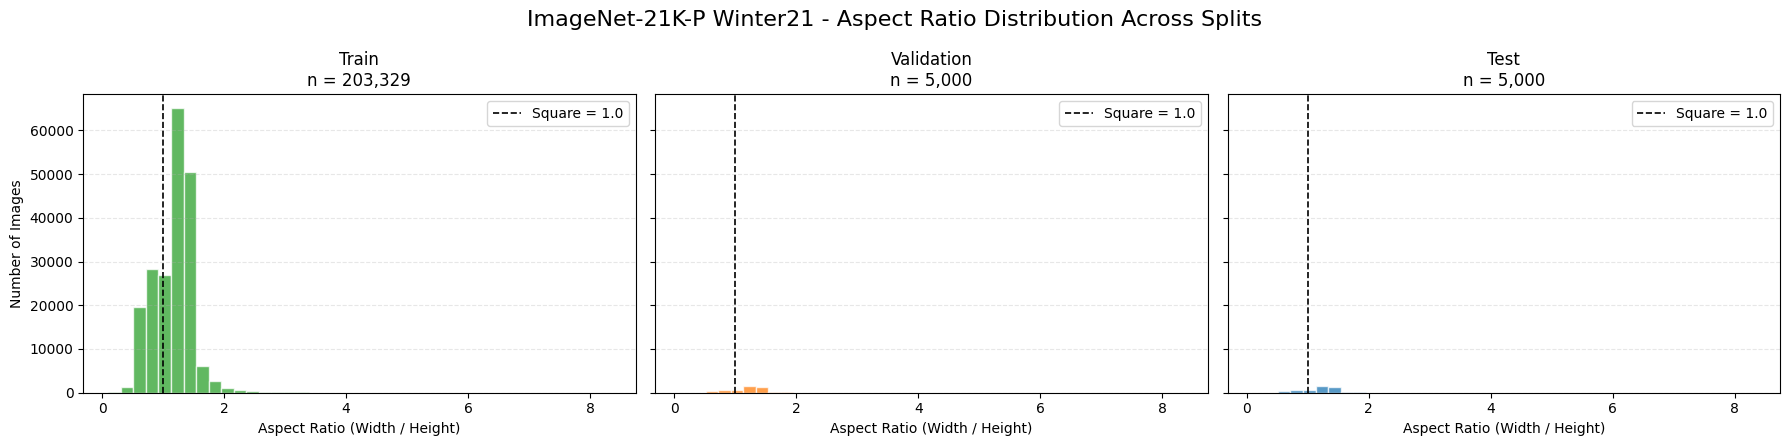

In [20]:
aspect_ratio_analysis.plot_aspect_ratio_distribution(
    aspect_ratio_details
)

#### 9. Image Mode / Channel Analysis

In [21]:
import src.eda.image_properties.image_mode_channel_analysis as image_mode_channel_analysis

image_modes, image_mode_details = (
    image_mode_channel_analysis.image_mode_channel_analysis(
        dataset_list=dataset_list,
        max_images=None,
        seed=42,
    )
)

image_modes

100%|██████████| 3/3 [03:22<00:00, 67.60s/it] 


,Dataset,Split,Total Images,Analyzed Images,Skipped Images,Unique Modes,Most Common Mode,RGB (%),Grayscale (%),RGBA (%),Other (%)
0,tiny_imagenet,Train,100000,100000,0,1,RGB,100.0,0.0,0.0,0.0
1,tiny_imagenet,Validation,10000,10000,0,1,RGB,100.0,0.0,0.0,0.0
2,tiny_imagenet,Test,10000,10000,0,1,RGB,100.0,0.0,0.0,0.0
3,imagenet21k_p,Train,203329,203329,0,1,RGB,100.0,0.0,0.0,0.0
4,imagenet21k_p,Validation,5000,5000,0,1,RGB,100.0,0.0,0.0,0.0
5,imagenet21k_p,Test,5000,5000,0,1,RGB,100.0,0.0,0.0,0.0


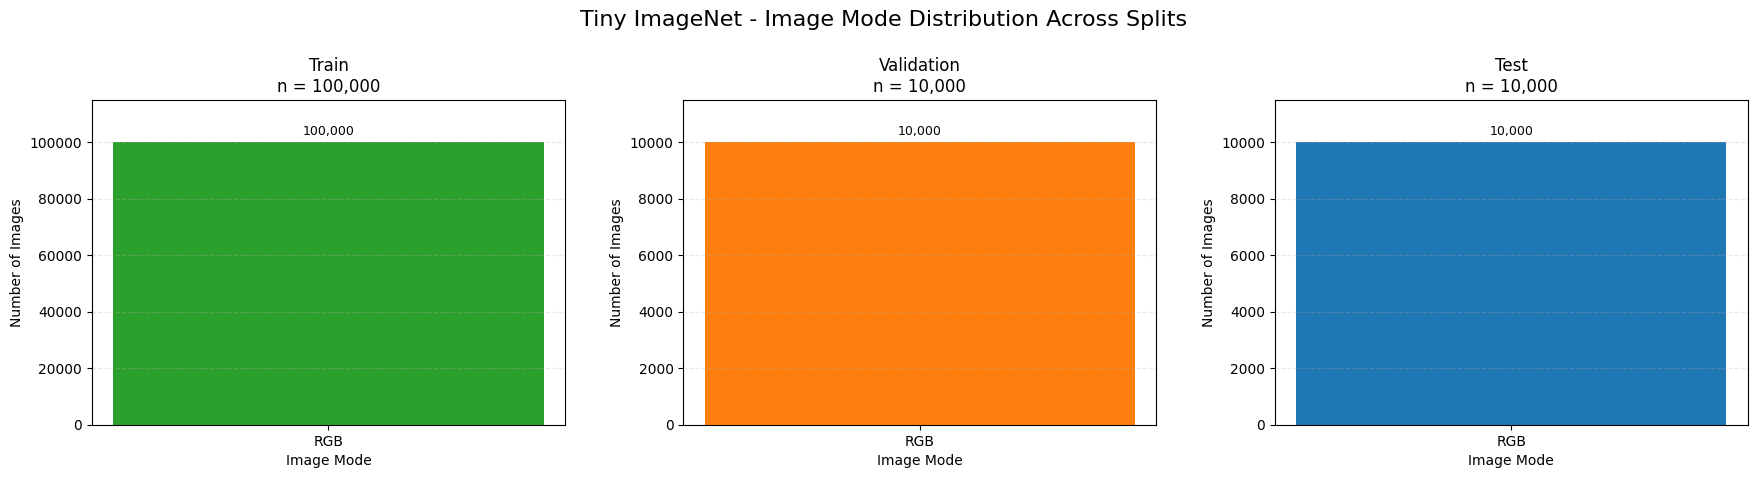

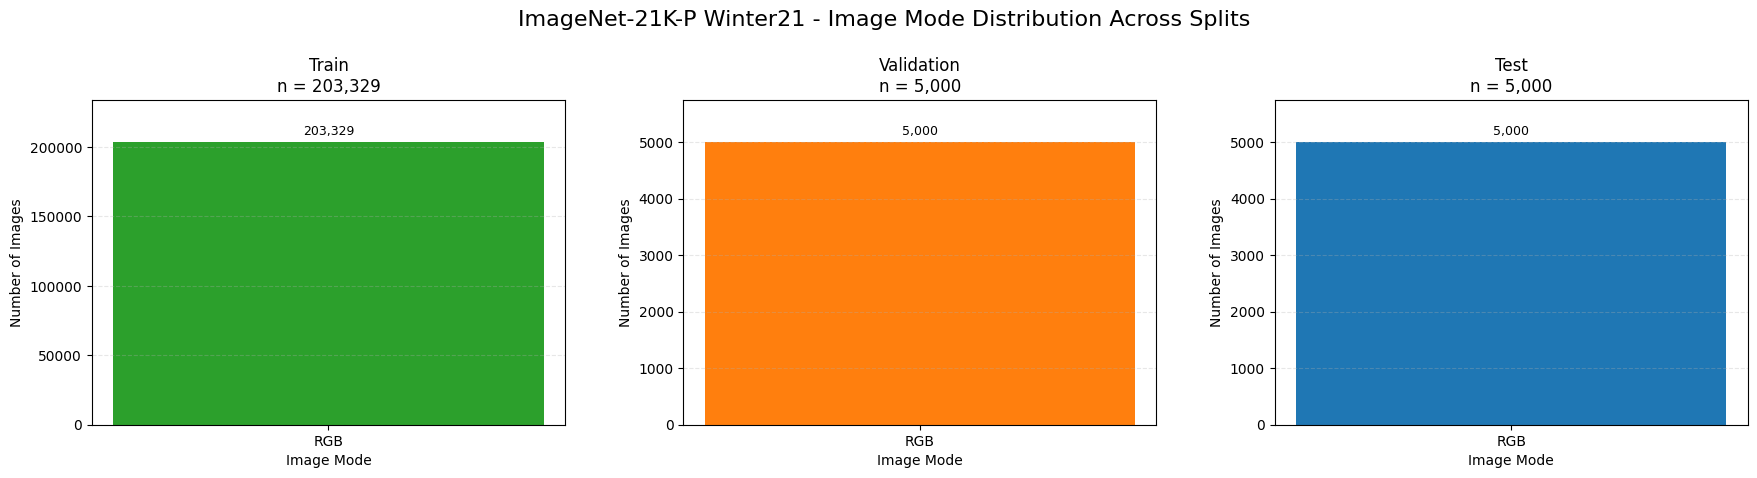

In [22]:
image_mode_channel_analysis.plot_image_modes(
    image_mode_details
)

#### 10. RGB Mean and Standard Deviation

In [23]:
import src.eda.image_properties.rgb_mean_std_analysis as rgb_mean_std_analysis

rgb_stats = rgb_mean_std_analysis.rgb_mean_std_analysis(
    dataset_list=dataset_list,
    max_images=None,
    seed=42,
)

rgb_stats

100%|██████████| 3/3 [13:32<00:00, 270.90s/it]


,Dataset,Split,Total Images,Analyzed Images,Skipped Images,Mean R,Mean G,Mean B,Std R,Std G,Std B
0,tiny_imagenet,Train,100000,100000,0,0.4802,0.4481,0.3975,0.2764,0.2689,0.2816
1,tiny_imagenet,Validation,10000,10000,0,0.4824,0.4495,0.3981,0.2765,0.2691,0.2825
2,tiny_imagenet,Test,10000,10000,0,0.4718,0.4415,0.3921,0.2751,0.2678,0.2793
3,imagenet21k_p,Train,203329,203329,0,0.4865,0.4674,0.4090,0.2881,0.2810,0.3014
4,imagenet21k_p,Validation,5000,5000,0,0.4806,0.4637,0.4083,0.2882,0.2797,0.3028
5,imagenet21k_p,Test,5000,5000,0,0.4817,0.4608,0.4043,0.2864,0.2781,0.2975


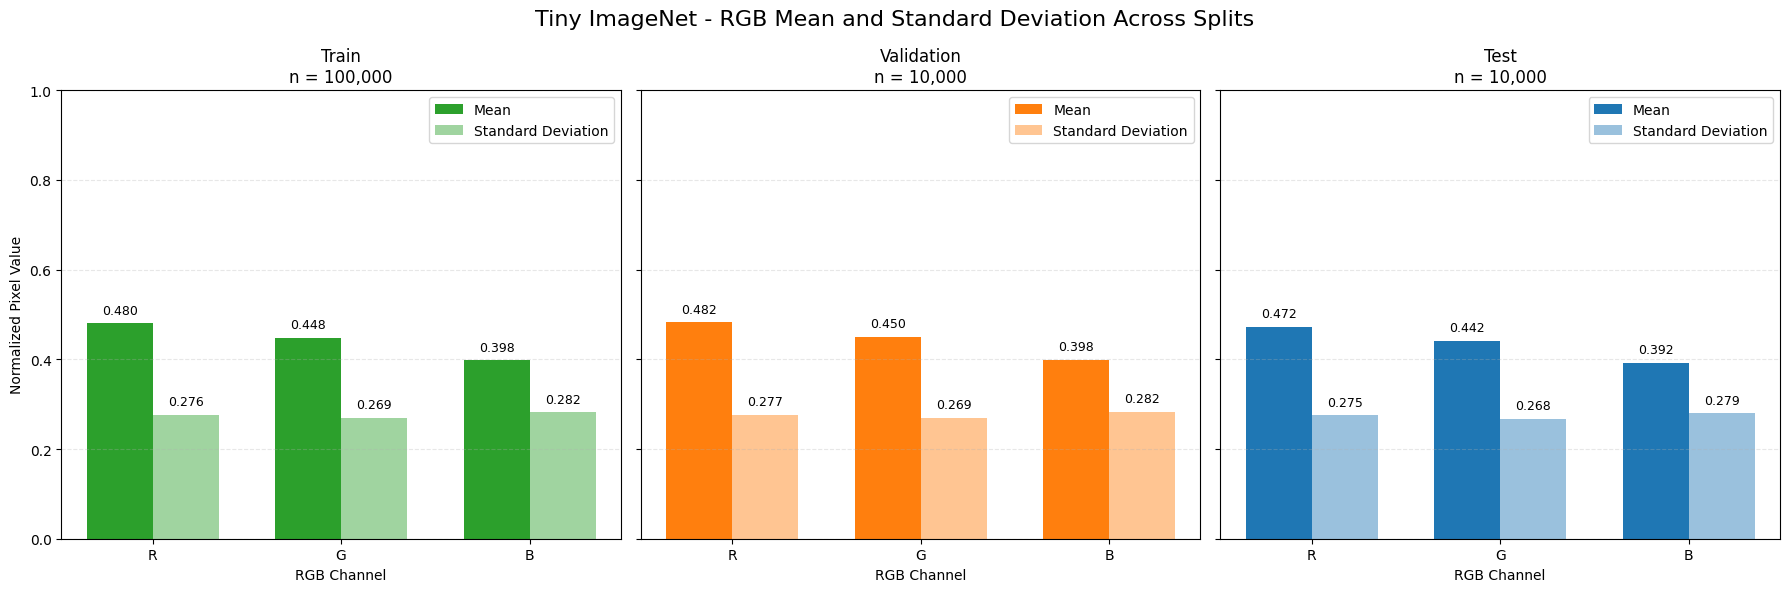

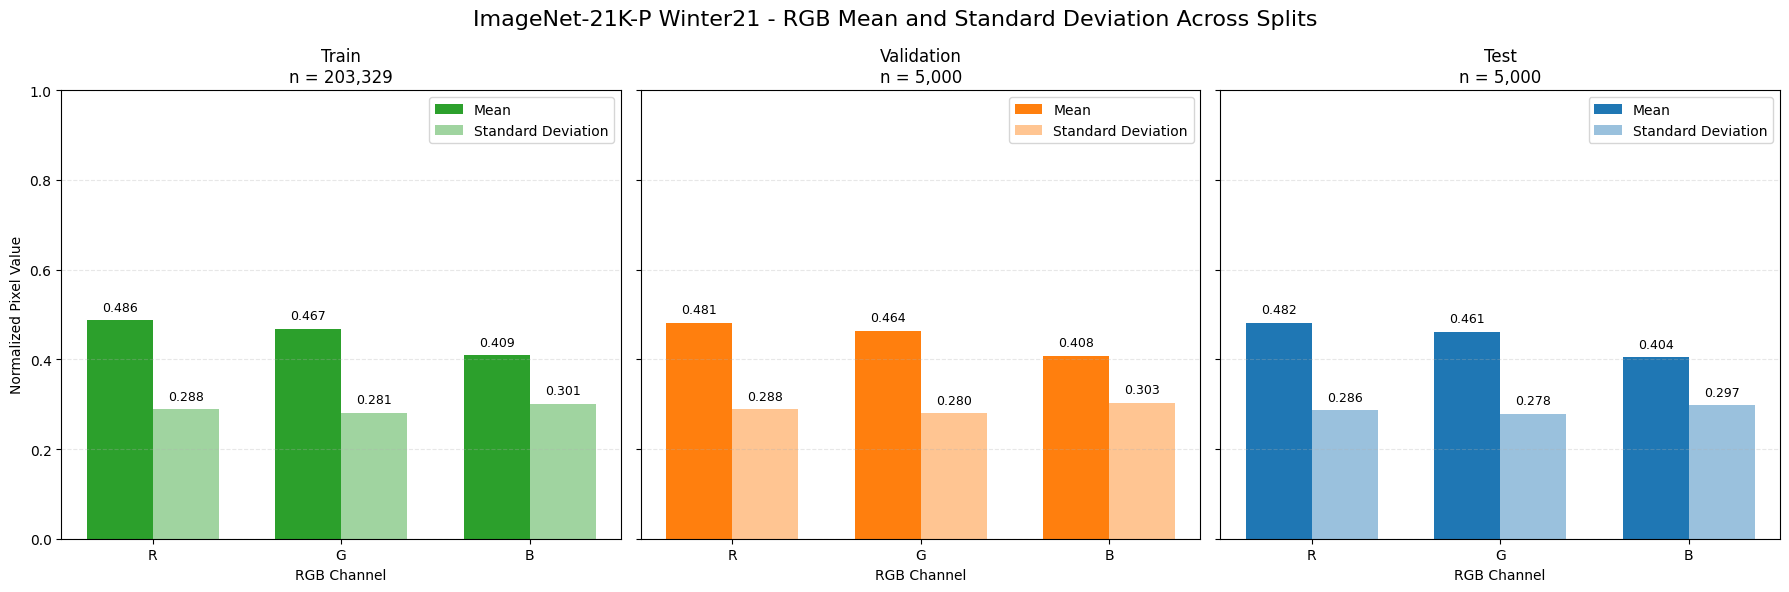

In [24]:
rgb_mean_std_analysis.plot_rgb_mean_std(
    rgb_stats
)

#### 11. Pixel Intensity Statistics

In [25]:
import src.eda.image_properties.pixel_intensity_analysis as pixel_intensity_analysis

pixel_intensity_stats, pixel_intensity_details = (
    pixel_intensity_analysis.pixel_intensity_analysis(
        dataset_list=dataset_list,
        max_images=None,
        seed=42,
    )
)

pixel_intensity_stats

100%|██████████| 3/3 [16:29<00:00, 329.81s/it]


,Dataset,Split,Total Images,Analyzed Images,Skipped Images,Total Pixels,Min Intensity,Max Intensity,Mean Intensity,Median Intensity,Std Intensity,5th Percentile,25th Percentile,75th Percentile,95th Percentile
0,tiny_imagenet,Train,100000,100000,0,409600000,0.0,1.0,0.4519,0.4395,0.2627,0.0527,0.2363,0.6465,0.9160
1,tiny_imagenet,Validation,10000,10000,0,40960000,0.0,1.0,0.4535,0.4395,0.2629,0.0527,0.2402,0.6504,0.9160
2,tiny_imagenet,Test,10000,10000,0,40960000,0.0,1.0,0.4449,0.4316,0.2616,0.0488,0.2324,0.6387,0.9043
3,imagenet21k_p,Train,203329,203329,0,38679342155,0.0,1.0,0.4665,0.4473,0.2750,0.0527,0.2441,0.6699,0.9746
4,imagenet21k_p,Validation,5000,5000,0,985957978,0.0,1.0,0.4624,0.4434,0.2747,0.0527,0.2402,0.6582,0.9824
5,imagenet21k_p,Test,5000,5000,0,969609428,0.0,1.0,0.4606,0.4434,0.2722,0.0488,0.2402,0.6621,0.9629


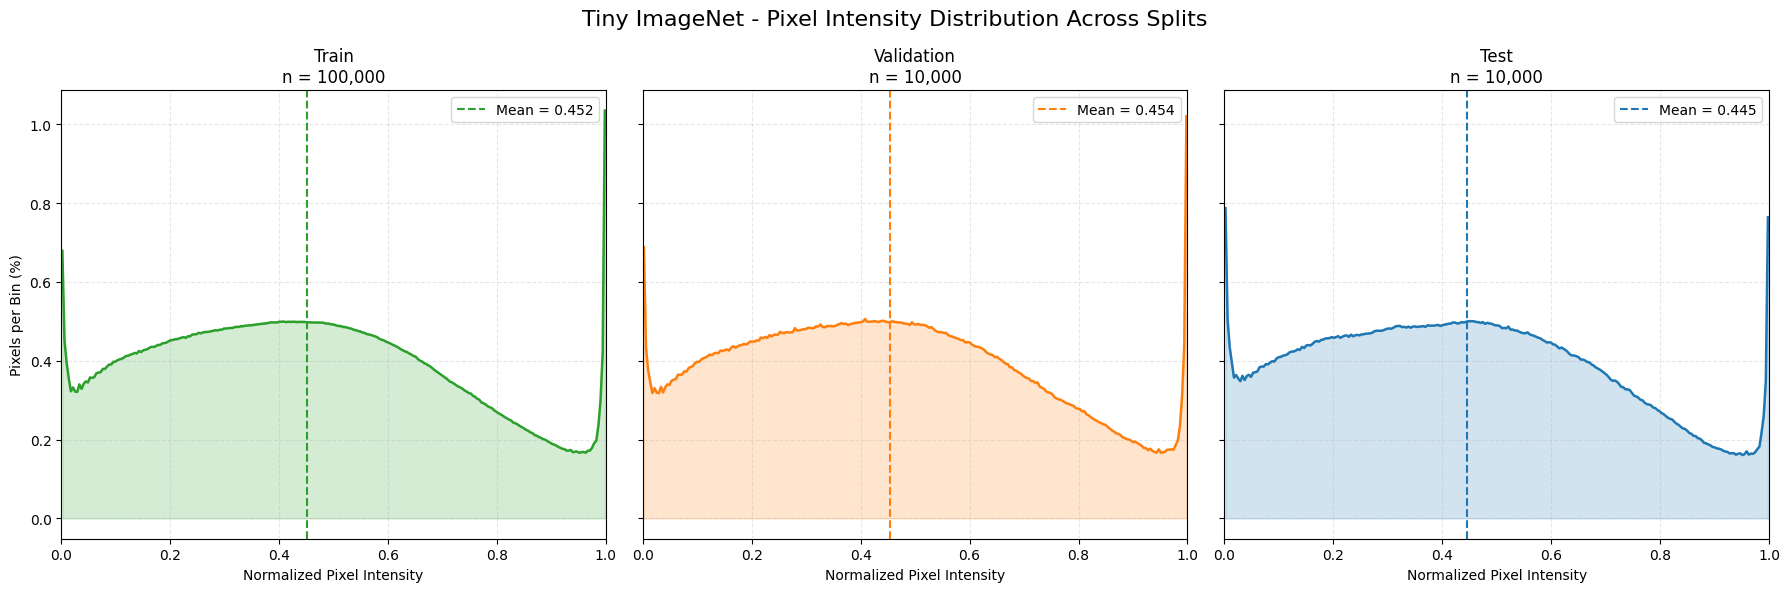

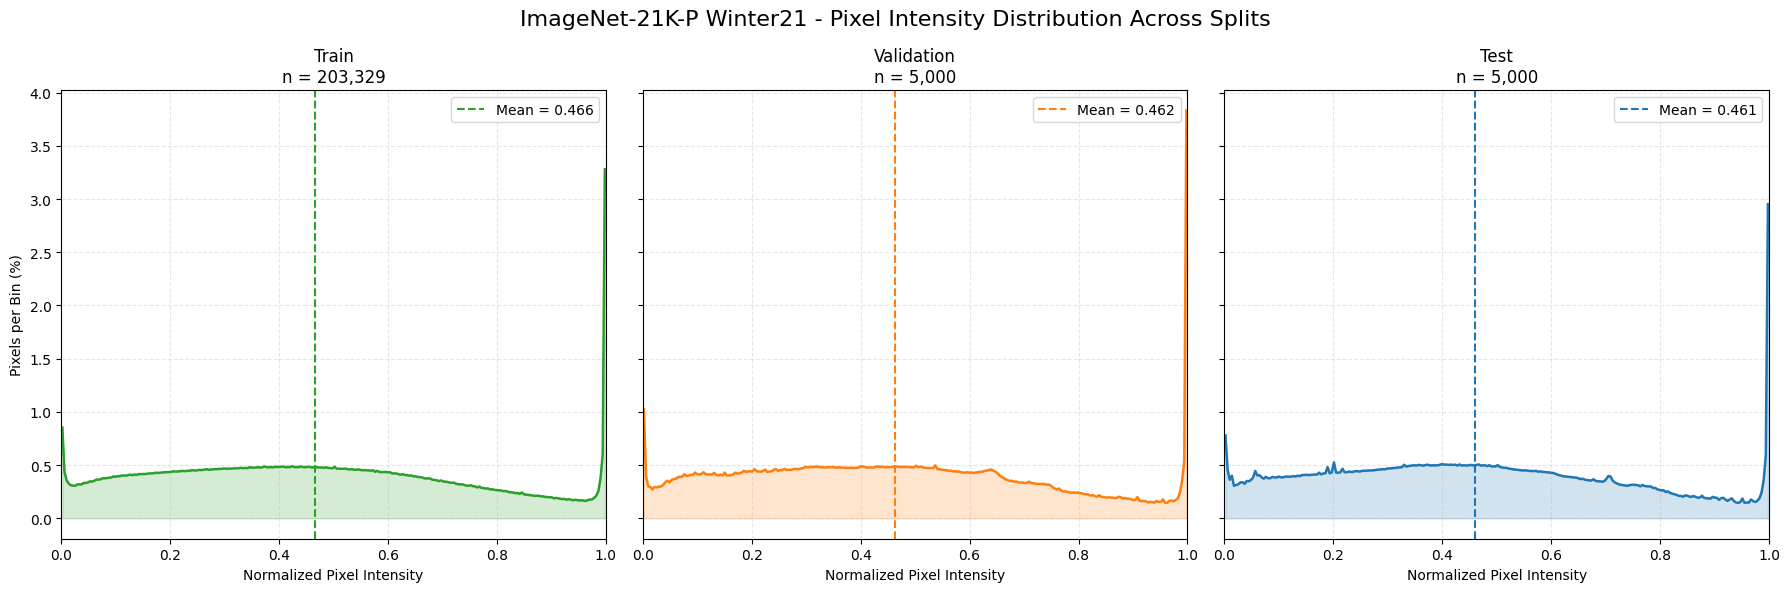

In [26]:
pixel_intensity_analysis.plot_pixel_intensity_distribution(
    pixel_intensity_details
)

## D. Image Properties

#### 12. Brightness, Contrast and Sharpness Analysis

In [27]:
import src.eda.image_quality.image_quality_analysis as image_quality_analysis

image_quality_stats, image_quality_details = (
    image_quality_analysis.image_quality_analysis(
        dataset_list=dataset_list,
        max_images=None,
        seed=42,
    )
)

image_quality_stats

Train: 100%|█████████▉| 99854/100000 [00:19<00:00, 5089.69it/s]
                                                               
Validation:  99%|█████████▊| 9871/10000 [00:02<00:00, 4310.43it/s]
                                                                  
Train: 100%|█████████▉| 203316/203329 [08:14<00:00, 411.52it/s]
                                                               
Validation:  99%|█████████▉| 4954/5000 [00:14<00:00, 374.89it/s]
                                                                
100%|██████████| 2/2 [09:06<00:00, 273.37s/it]            


,Dataset,Split,Total Images,Analyzed Images,Skipped Images,Mean Brightness,Median Brightness,Std Brightness,Mean Contrast,Median Contrast,Std Contrast,Mean Sharpness,Median Sharpness,Std Sharpness
0,tiny_imagenet,Train,100000,100000,0,0.4519,0.4503,0.1275,0.2221,0.2216,0.0584,0.141883,0.117483,0.105852
1,tiny_imagenet,Validation,10000,10000,0,0.4535,0.4506,0.1283,0.2219,0.2218,0.0580,0.140731,0.116711,0.104544
2,tiny_imagenet,Test,10000,10000,0,0.4449,0.4482,0.1237,0.2232,0.2226,0.0572,0.154214,0.129794,0.110502
3,imagenet21k_p,Train,203329,203329,0,0.4815,0.4649,0.1601,0.2273,0.2252,0.0629,0.039511,0.023155,0.050921
4,imagenet21k_p,Validation,5000,5000,0,0.4831,0.4665,0.1593,0.2263,0.2238,0.0627,0.039592,0.023107,0.052558
5,imagenet21k_p,Test,5000,5000,0,0.4775,0.4609,0.1614,0.2239,0.2218,0.0630,0.039171,0.022995,0.052920


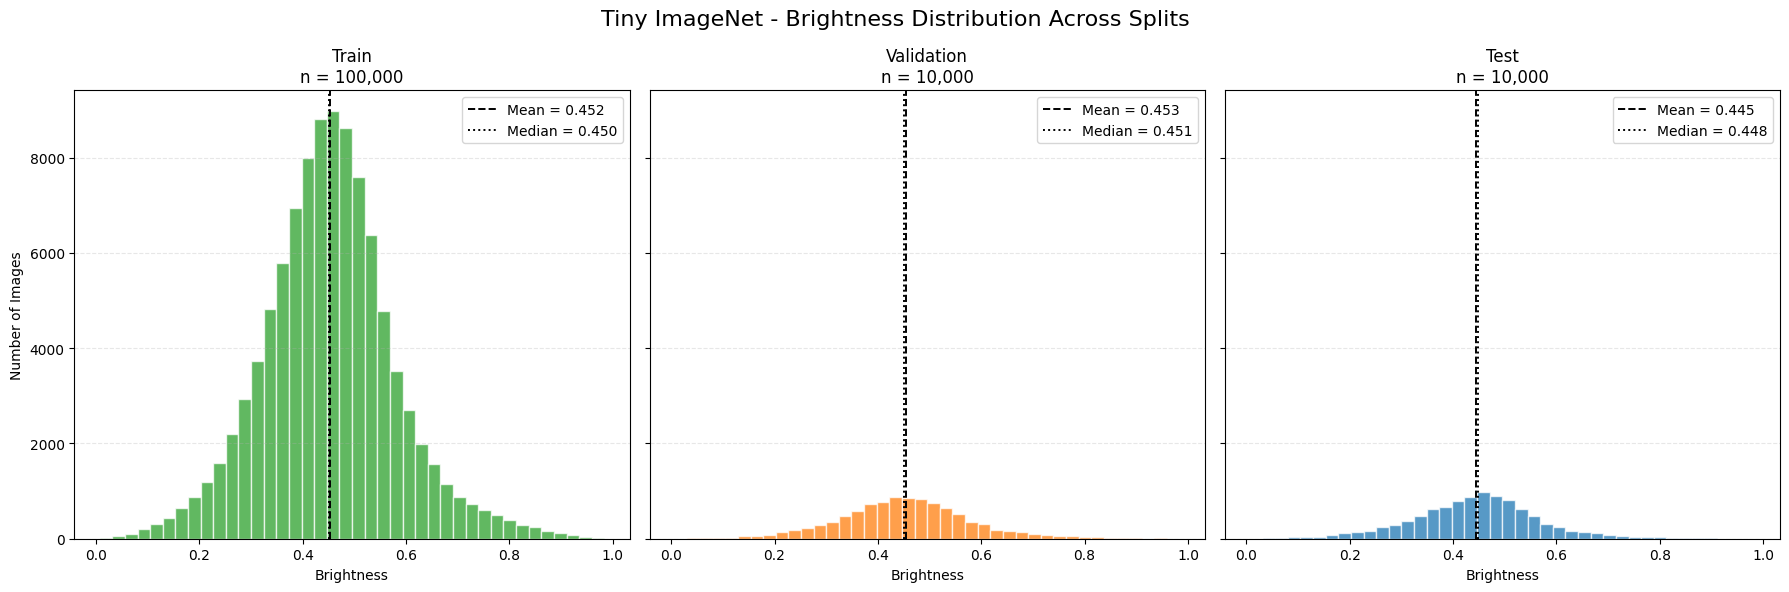

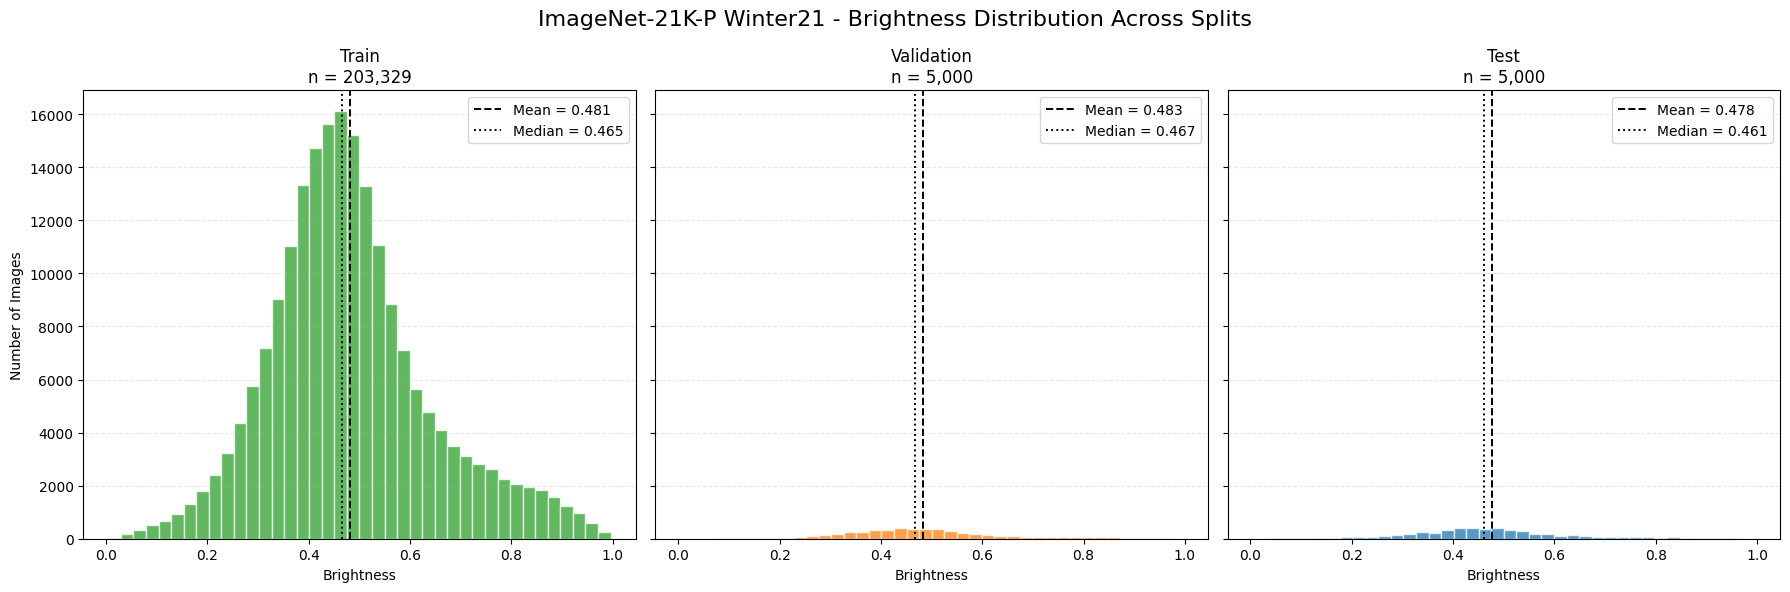

In [28]:
image_quality_analysis.plot_quality_metric_distribution(
    image_quality_details,
    "Brightness",
)

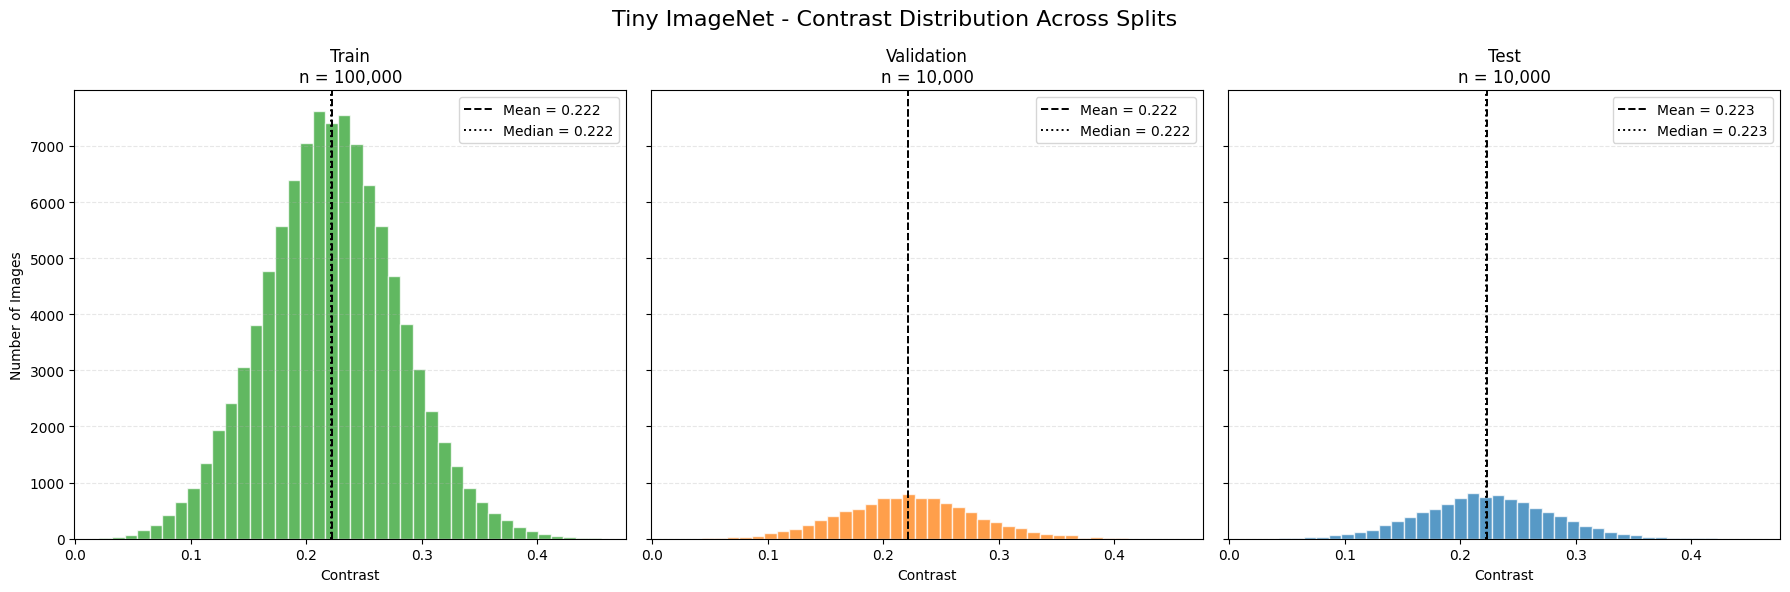

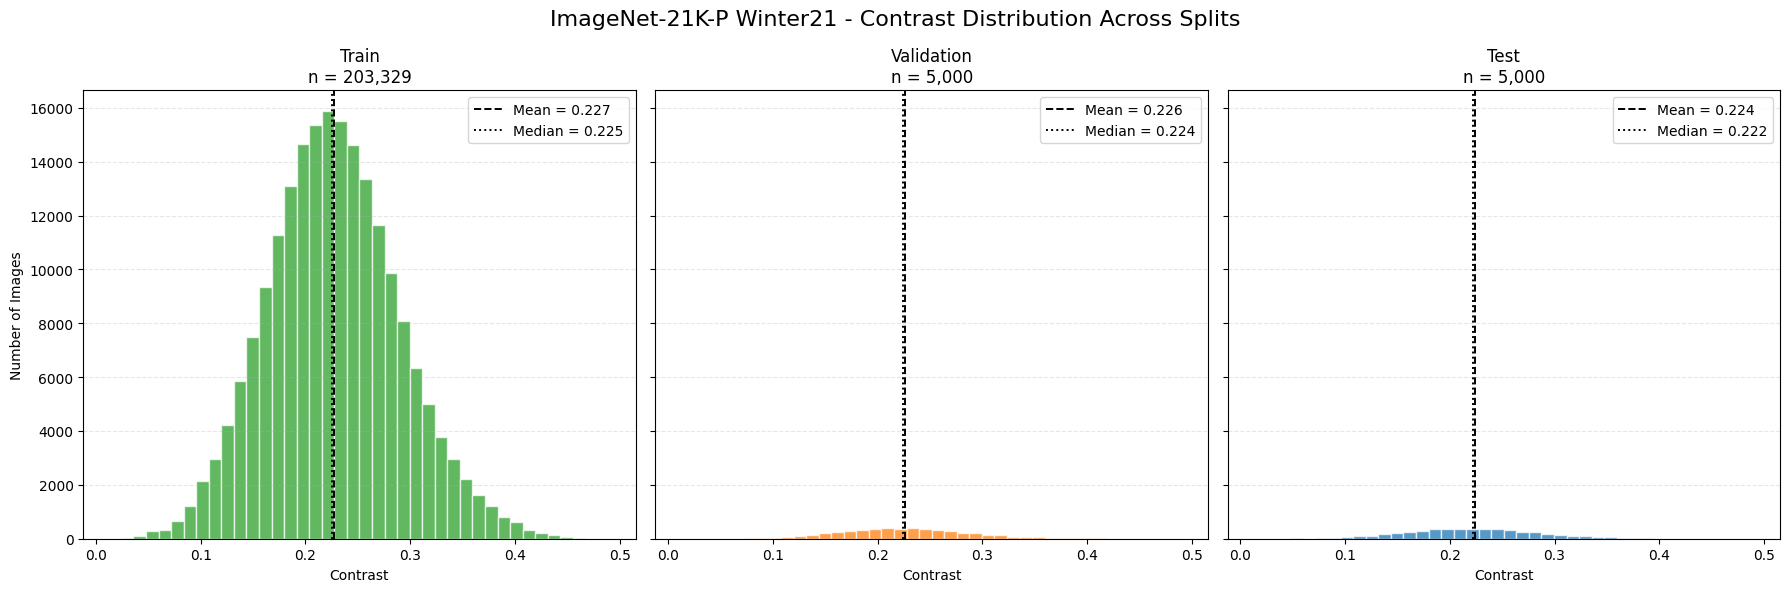

In [29]:
image_quality_analysis.plot_quality_metric_distribution(
    image_quality_details,
    "Contrast",
)

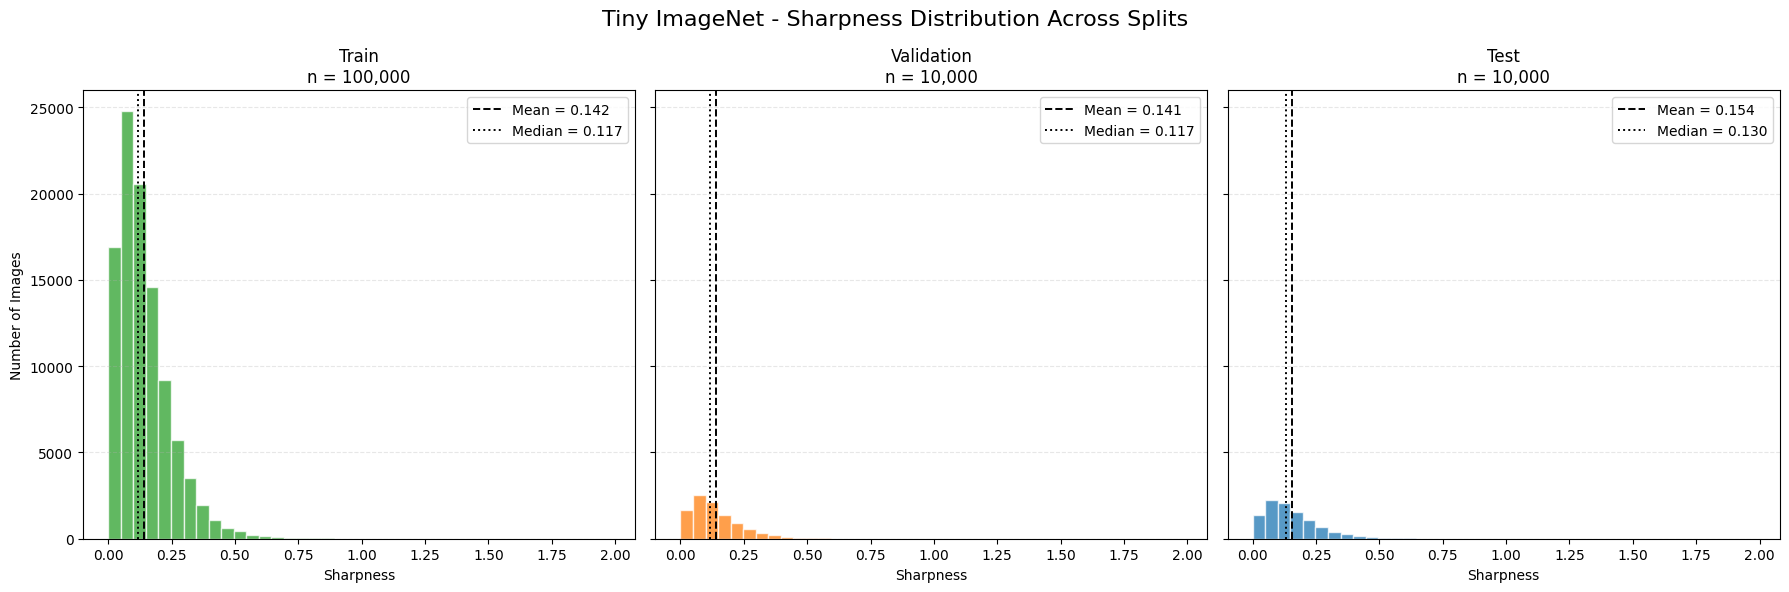

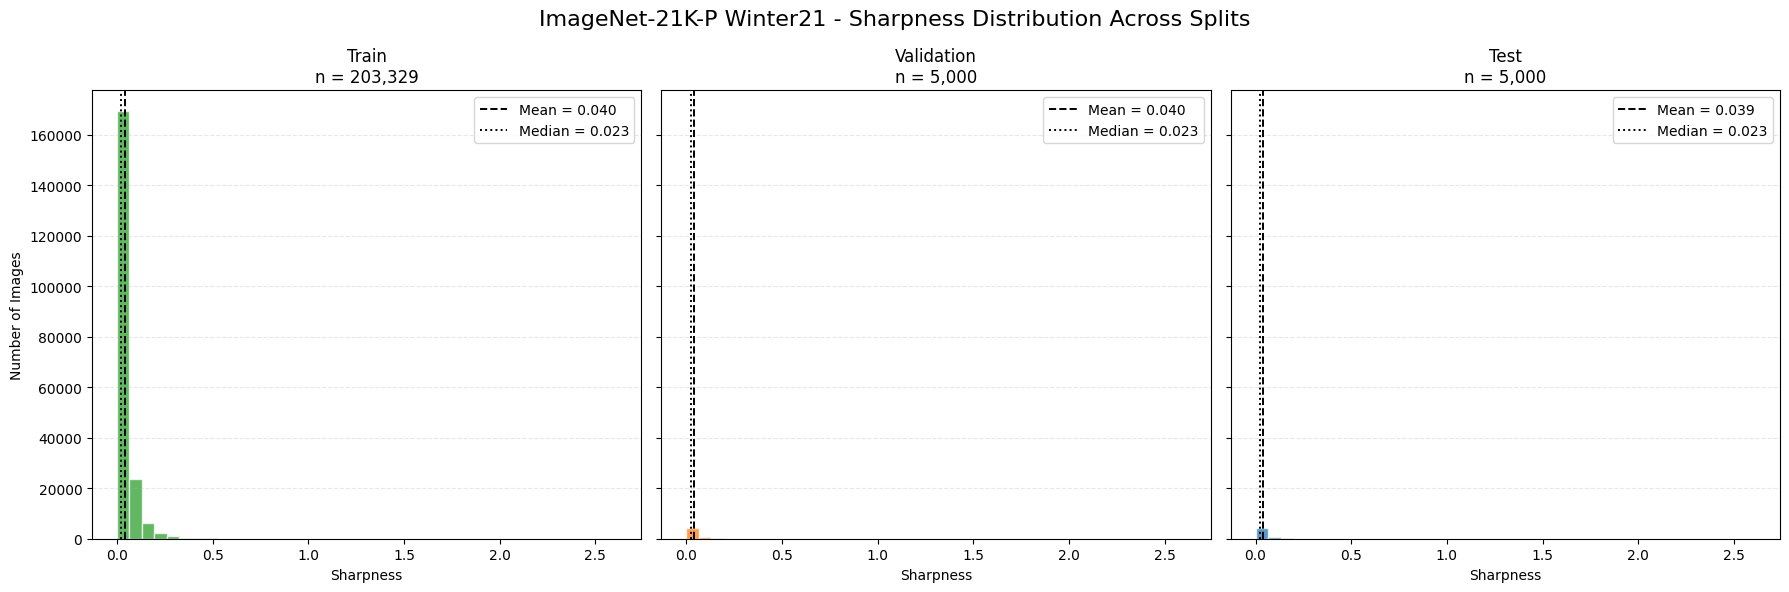

In [30]:
image_quality_analysis.plot_quality_metric_distribution(
    image_quality_details,
    "Sharpness",
)

## E. Anomalies / Leakage

#### 13. Statistical Outlier Detection

In [31]:
import src.eda.anomalies_leakage.statistical_outlier_analysis as statistical_outlier_analysis

outlier_stats, outlier_details, outlier_thresholds = (
    statistical_outlier_analysis.statistical_outlier_analysis(
        image_dimension_details,
        image_quality_details,
        iqr_multiplier=1.5,
    )
)

outlier_stats

imagenet21k_p splits: 100%|██████████| 3/3 [00:01<00:00,  2.03it/s]


,Dataset,Split,Analyzed Images,Outlier Images,Outlier (%),Width Outliers,Width Outlier (%),Height Outliers,Height Outlier (%),Aspect Ratio Outliers,Aspect Ratio Outlier (%),Brightness Outliers,Brightness Outlier (%),Contrast Outliers,Contrast Outlier (%),Sharpness Outliers,Sharpness Outlier (%)
0,tiny_imagenet,Train,100000,7303,7.30,0,0.00,0,0.00,0,0.00,3175,3.17,905,0.91,3362,3.36
1,tiny_imagenet,Validation,10000,719,7.19,0,0.00,0,0.00,0,0.00,290,2.90,89,0.89,352,3.52
2,tiny_imagenet,Test,10000,659,6.59,0,0.00,0,0.00,0,0.00,281,2.81,97,0.97,292,2.92
3,imagenet21k_p,Train,203329,33949,16.70,5125,2.52,5525,2.72,1762,0.87,8762,4.31,2002,0.98,15750,7.75
4,imagenet21k_p,Validation,5000,842,16.84,134,2.68,150,3.00,56,1.12,213,4.26,47,0.94,382,7.64
5,imagenet21k_p,Test,5000,885,17.70,143,2.86,143,2.86,57,1.14,276,5.52,53,1.06,358,7.16


In [32]:
outlier_details["tiny_imagenet"]["Train"][
    outlier_details["tiny_imagenet"]["Train"]["Is Outlier"]
].head(5)

,Image Index,Width,Height,Aspect Ratio,Brightness,Contrast,Sharpness,Width Outlier,Height Outlier,Aspect Ratio Outlier,Brightness Outlier,Contrast Outlier,Sharpness Outlier,Outlier Count,Is Outlier,Outlier Metrics
75,75,64,64,1.0,0.176243,0.053831,0.006319,False,False,False,False,True,False,1,True,Contrast
87,87,64,64,1.0,0.901652,0.153137,0.018691,False,False,False,True,False,False,1,True,Brightness
96,96,64,64,1.0,0.514833,0.066202,0.008405,False,False,False,False,True,False,1,True,Contrast
107,107,64,64,1.0,0.919090,0.141514,0.014122,False,False,False,True,False,False,1,True,Brightness
117,117,64,64,1.0,0.080252,0.076914,0.002454,False,False,False,True,False,False,1,True,Brightness


In [44]:
outlier_details["imagenet21k_p"]["Train"][
    outlier_details["imagenet21k_p"]["Train"]["Is Outlier"]
].head(5)

,Image Index,Width,Height,Aspect Ratio,Brightness,Contrast,Sharpness,Width Outlier,Height Outlier,Aspect Ratio Outlier,Brightness Outlier,Contrast Outlier,Sharpness Outlier,Outlier Count,Is Outlier,Outlier Metrics
9,9,1181,800,1.476250,0.418429,0.281432,0.004637,True,True,False,False,False,False,2,True,"Width, Height"
11,11,2160,1440,1.500000,0.404545,0.168579,0.009508,True,True,False,False,False,False,2,True,"Width, Height"
24,24,500,399,1.253133,0.414489,0.232577,0.163353,False,False,False,False,False,True,1,True,Sharpness
62,62,478,500,0.956000,0.495568,0.340853,0.108685,False,False,False,False,False,True,1,True,Sharpness
87,87,295,221,1.334842,0.527963,0.224678,0.109359,False,False,False,False,False,True,1,True,Sharpness


In [34]:
outlier_details["imagenet21k_p"]["Train"][
    outlier_details["imagenet21k_p"]["Train"]["Is Outlier"]
].head(5)

,Image Index,Width,Height,Aspect Ratio,Brightness,Contrast,Sharpness,Width Outlier,Height Outlier,Aspect Ratio Outlier,Brightness Outlier,Contrast Outlier,Sharpness Outlier,Outlier Count,Is Outlier,Outlier Metrics
9,9,1181,800,1.476250,0.418429,0.281432,0.004637,True,True,False,False,False,False,2,True,"Width, Height"
11,11,2160,1440,1.500000,0.404545,0.168579,0.009508,True,True,False,False,False,False,2,True,"Width, Height"
24,24,500,399,1.253133,0.414489,0.232577,0.163353,False,False,False,False,False,True,1,True,Sharpness
62,62,478,500,0.956000,0.495568,0.340853,0.108685,False,False,False,False,False,True,1,True,Sharpness
87,87,295,221,1.334842,0.527963,0.224678,0.109359,False,False,False,False,False,True,1,True,Sharpness


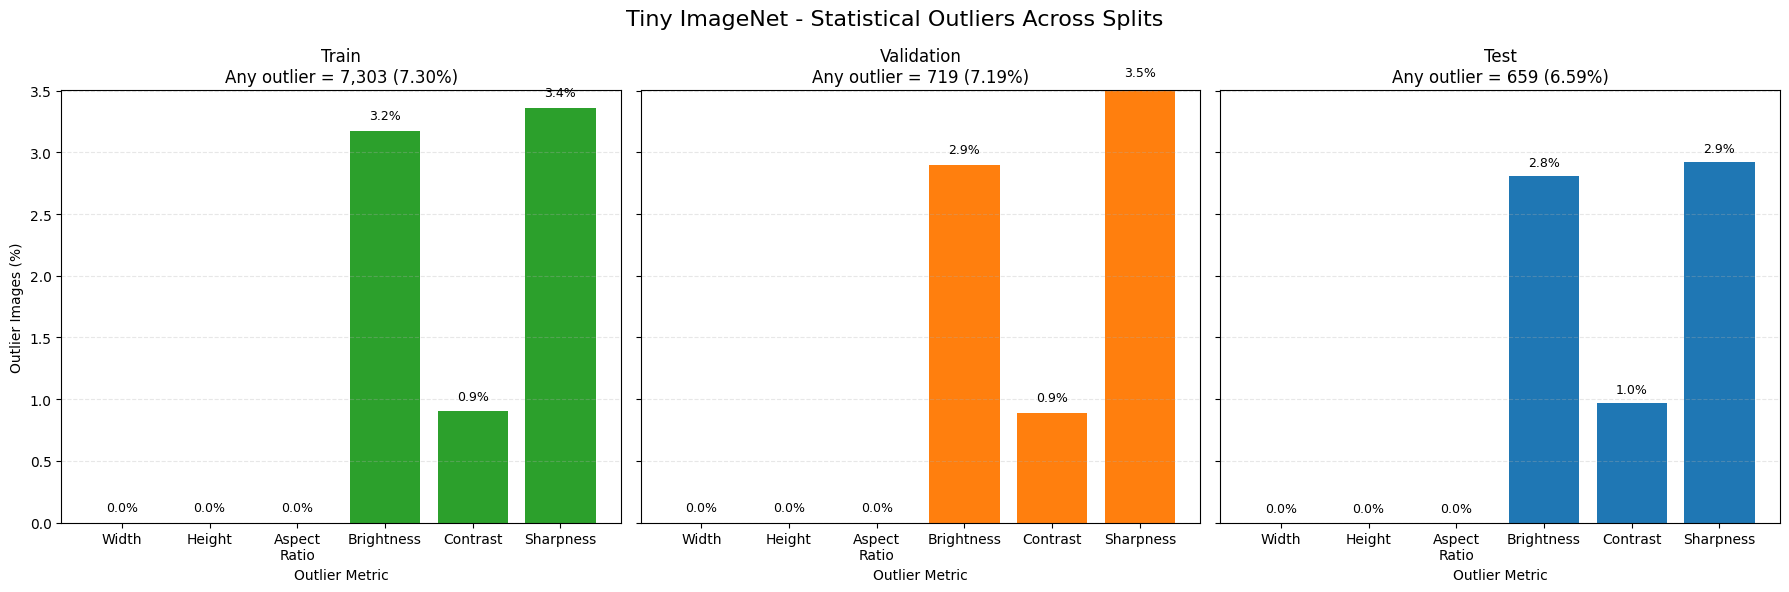

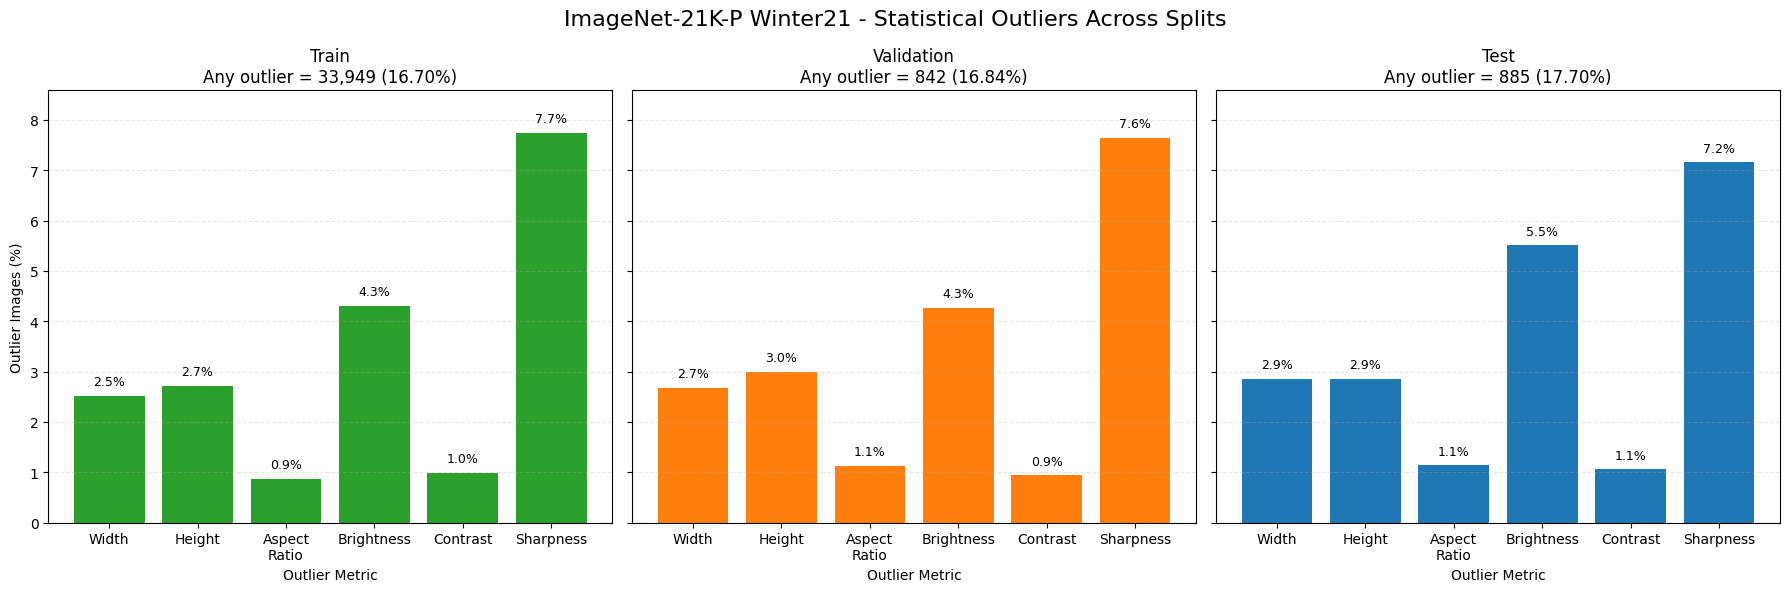

In [35]:
statistical_outlier_analysis.plot_statistical_outliers(
    outlier_details
)

#### 14. Corrupted Image Detection

In [36]:
import src.eda.anomalies_leakage.corrupted_image_analysis as corrupted_image_analysis

corruption_stats, corrupted_details = (
    corrupted_image_analysis.corrupted_image_analysis(
        dataset_list=dataset_list,
        max_images=None,
        seed=42,
    )
)

corruption_stats

Train:  99%|█████████▉| 99438/100000 [00:15<00:00, 5942.27it/s]
                                                               
Validation:  96%|█████████▌| 9597/10000 [00:02<00:00, 4754.58it/s]
                                                                  
Train: 100%|█████████▉| 203279/203329 [03:13<00:00, 894.74it/s]
                                                               
Validation:  99%|█████████▉| 4944/5000 [00:05<00:00, 877.07it/s]
                                                                
100%|██████████| 2/2 [03:45<00:00, 112.57s/it]            


,Dataset,Split,Total Images,Analyzed Images,Valid Images,Corrupted Images,Corrupted (%),Integrity Status
0,tiny_imagenet,Train,100000,100000,100000,0,0.0,Passed
1,tiny_imagenet,Validation,10000,10000,10000,0,0.0,Passed
2,tiny_imagenet,Test,10000,10000,10000,0,0.0,Passed
3,imagenet21k_p,Train,203329,203329,203329,0,0.0,Passed
4,imagenet21k_p,Validation,5000,5000,5000,0,0.0,Passed
5,imagenet21k_p,Test,5000,5000,5000,0,0.0,Passed


In [38]:
corrupted_details["imagenet21k_p"]["Train"]

""


In [45]:
corrupted_details["imagenet21k_p"]["Train"][
    "Error Type"
].value_counts()

KeyError: 'Error Type'

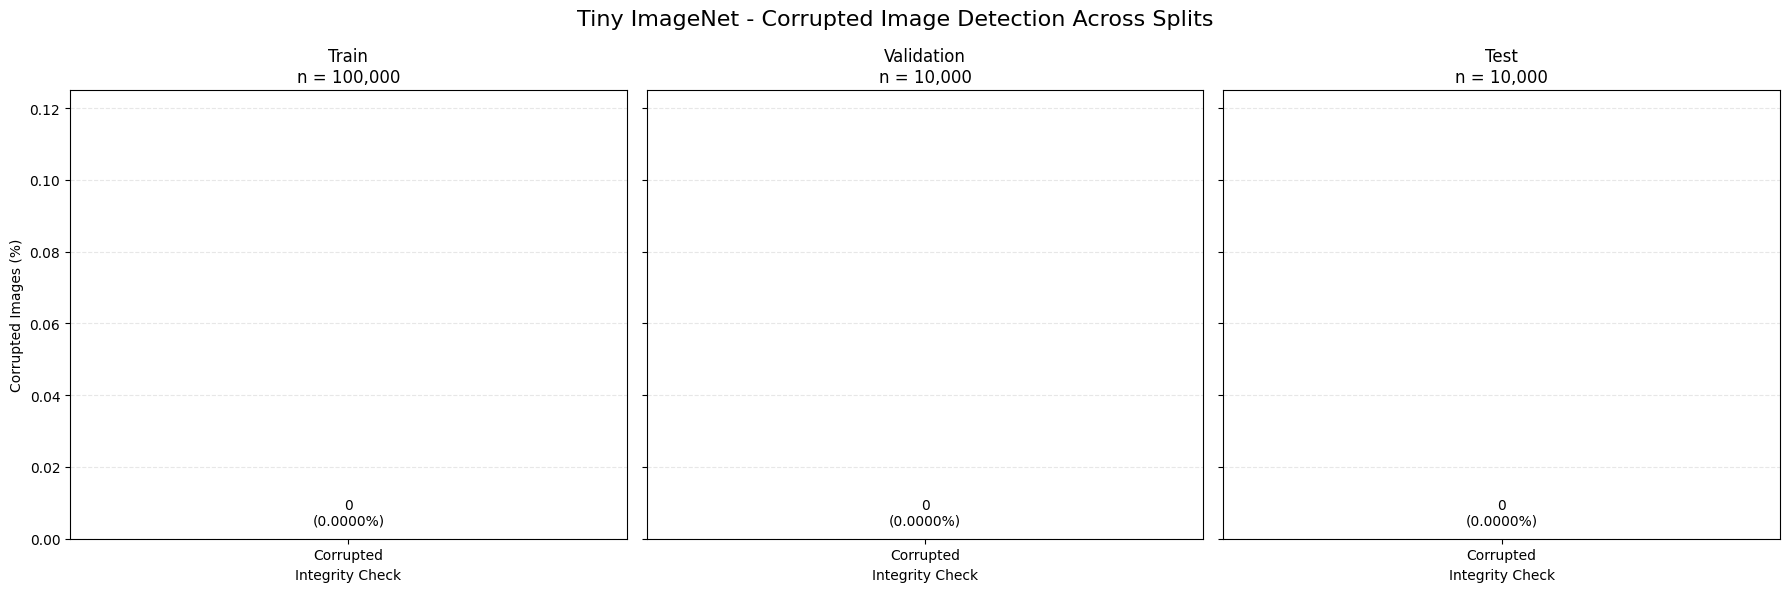

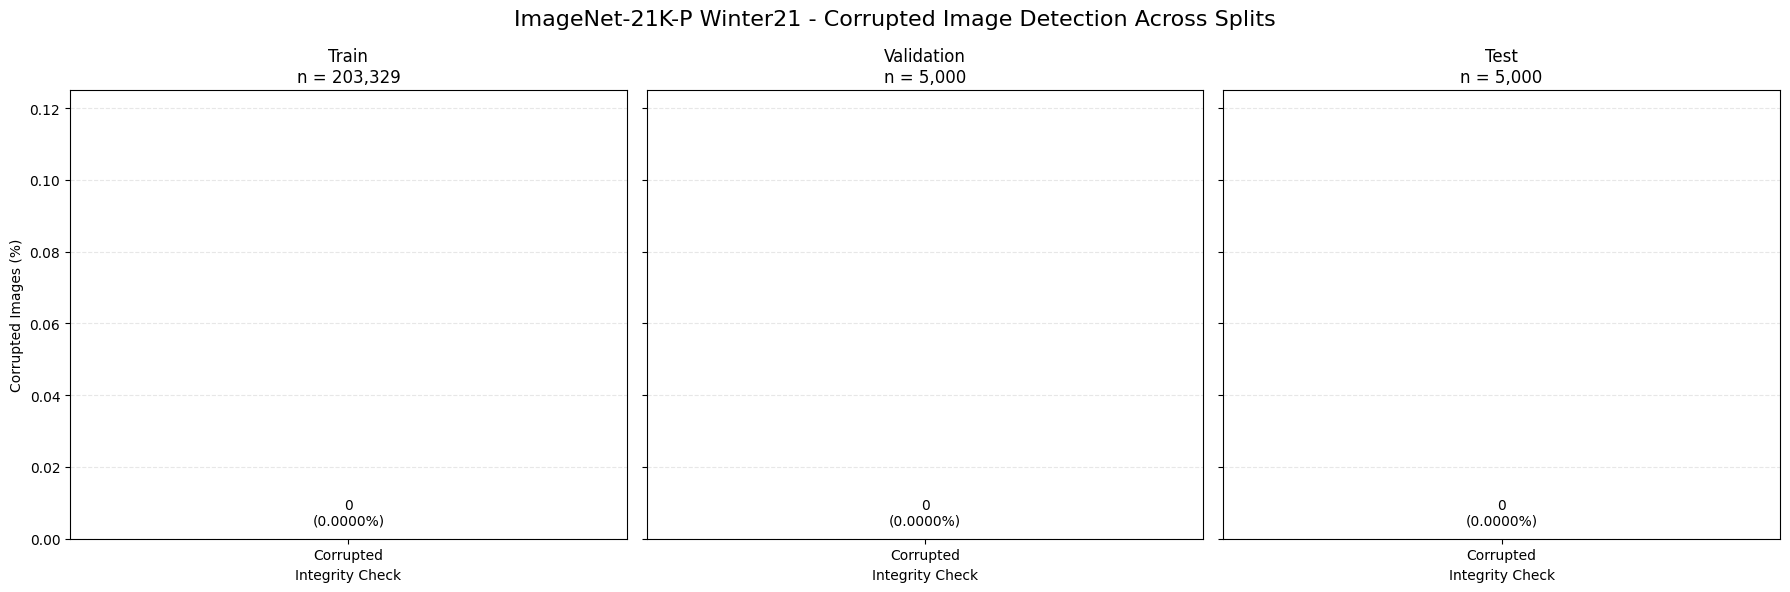

In [40]:
corrupted_image_analysis.plot_corrupted_images(
    corruption_stats
)

#### 15. Duplicate Image and Data Leakage Detection

In [41]:
import src.eda.anomalies_leakage.duplicate_leakage_analysis as duplicate_leakage_analysis

duplicate_stats, duplicate_details = (
    duplicate_leakage_analysis.duplicate_leakage_analysis(
        dataset_list=dataset_list,
        max_images=None,
        seed=42,
    )
)

duplicate_stats

imagenet21k_p splits: 100%|██████████| 3/3 [04:46<00:00, 95.57s/it] 


,Dataset,Analyzed Images,Hash Failures,Train Duplicate Groups,Train Duplicate Images,Train Duplicate (%),Validation Duplicate Groups,Validation Duplicate Images,Validation Duplicate (%),Test Duplicate Groups,Test Duplicate Images,Test Duplicate (%),Train ↔ Validation Leakage,Train ↔ Test Leakage,Validation ↔ Test Leakage,Unique Leakage Groups,Leakage Status
0,tiny_imagenet,120000,0,20,20,0.020,0,0,0.00,2,2,0.02,7,9,1,17,Leakage Detected
1,imagenet21k_p,213329,0,1335,1527,0.751,1,1,0.02,2,4,0.08,76,77,7,158,Leakage Detected


##### Inspect within-split duplicates

In [42]:
duplicate_details["tiny_imagenet"]["Train Duplicates"].head(5)

,Split,Image Index,Target,Image Path,Hash
0,Train,87271,174,data/tiny_imagenet/tiny-imagenet-200/train/n04...,009f48ae262f3d83fc1103e54998c046b3a029a98eb0c5...
1,Train,87649,175,data/tiny_imagenet/tiny-imagenet-200/train/n04...,009f48ae262f3d83fc1103e54998c046b3a029a98eb0c5...
2,Train,91457,182,data/tiny_imagenet/tiny-imagenet-200/train/n07...,0226189805b100c31f8ccb8a1b1c465c0aedc40a89ad70...
3,Train,95376,190,data/tiny_imagenet/tiny-imagenet-200/train/n07...,0226189805b100c31f8ccb8a1b1c465c0aedc40a89ad70...
4,Train,55355,110,data/tiny_imagenet/tiny-imagenet-200/train/n03...,1699ec8fb9ed0deadd11792413383c4130f274108d6df8...


In [43]:
duplicate_details["imagenet21k_p"]["Train Duplicates"].head(5)

,Split,Image Index,Target,Image Path,Hash
0,Train,7785,5,data/imagenet21k_p/images/train/n01543632/n015...,0016e8548079e5dad3a5c09b737bc121c621dfc9c78ae0...
1,Train,7883,5,data/imagenet21k_p/images/train/n01543632/n015...,0016e8548079e5dad3a5c09b737bc121c621dfc9c78ae0...
2,Train,24908,22,data/imagenet21k_p/images/train/n02044778/n020...,0025061b607afce3ac9650c68b580400f9eccbddf05a0d...
3,Train,26527,23,data/imagenet21k_p/images/train/n02044908/n020...,0025061b607afce3ac9650c68b580400f9eccbddf05a0d...
4,Train,188946,183,data/imagenet21k_p/images/train/n12529220/n125...,0042221982aa9cf8cc95446686edda1e4e71646a55dbb6...


##### Inspect specific leakage records

In [46]:
duplicate_details["tiny_imagenet"]["Cross-Split Leakage"].head(5)

,Split,Image Index,Target,Image Path,Hash
0,Train,5879,11,data/tiny_imagenet/tiny-imagenet-200/train/n01...,083118a5bbd48877661e067f24d7988a61bc47e5d7e283...
1,Validation,1006,20,data/tiny_imagenet/tiny-imagenet-200/val/n0200...,083118a5bbd48877661e067f24d7988a61bc47e5d7e283...
2,Test,8085,0,data/tiny_imagenet/tiny-imagenet-200/test/imag...,1ceced1539c5e09874ee698b9c49380f30beed084ca9dc...
3,Train,93352,186,data/tiny_imagenet/tiny-imagenet-200/train/n07...,1ceced1539c5e09874ee698b9c49380f30beed084ca9dc...
4,Test,3554,0,data/tiny_imagenet/tiny-imagenet-200/test/imag...,1e412b2ddb0d49bd3bf15bb24bf0d146f214b42ecf4417...


In [47]:
duplicate_details["imagenet21k_p"]["Cross-Split Leakage"].head(5)

,Split,Image Index,Target,Image Path,Hash
0,Train,31345,27,data/imagenet21k_p/images/train/n02104365/n021...,0408494ac6141c5bc8c8e752017d91e2735ad8ccfee2de...
1,Validation,1428,27,data/imagenet21k_p/images/validation/n02104365...,0408494ac6141c5bc8c8e752017d91e2735ad8ccfee2de...
2,Test,4292,185,data/imagenet21k_p/images/validation/n12574320...,04d23cc8ffcf87ffea1129cdf443e92cbf7dd7c1a3f40a...
3,Train,190418,185,data/imagenet21k_p/images/train/n12574320/n125...,04d23cc8ffcf87ffea1129cdf443e92cbf7dd7c1a3f40a...
4,Train,176338,169,data/imagenet21k_p/images/train/n11940599/n119...,05398a1e69f2cbe8d32246c83eb4271d641e5aca0f57d1...


##### Duplicate plots

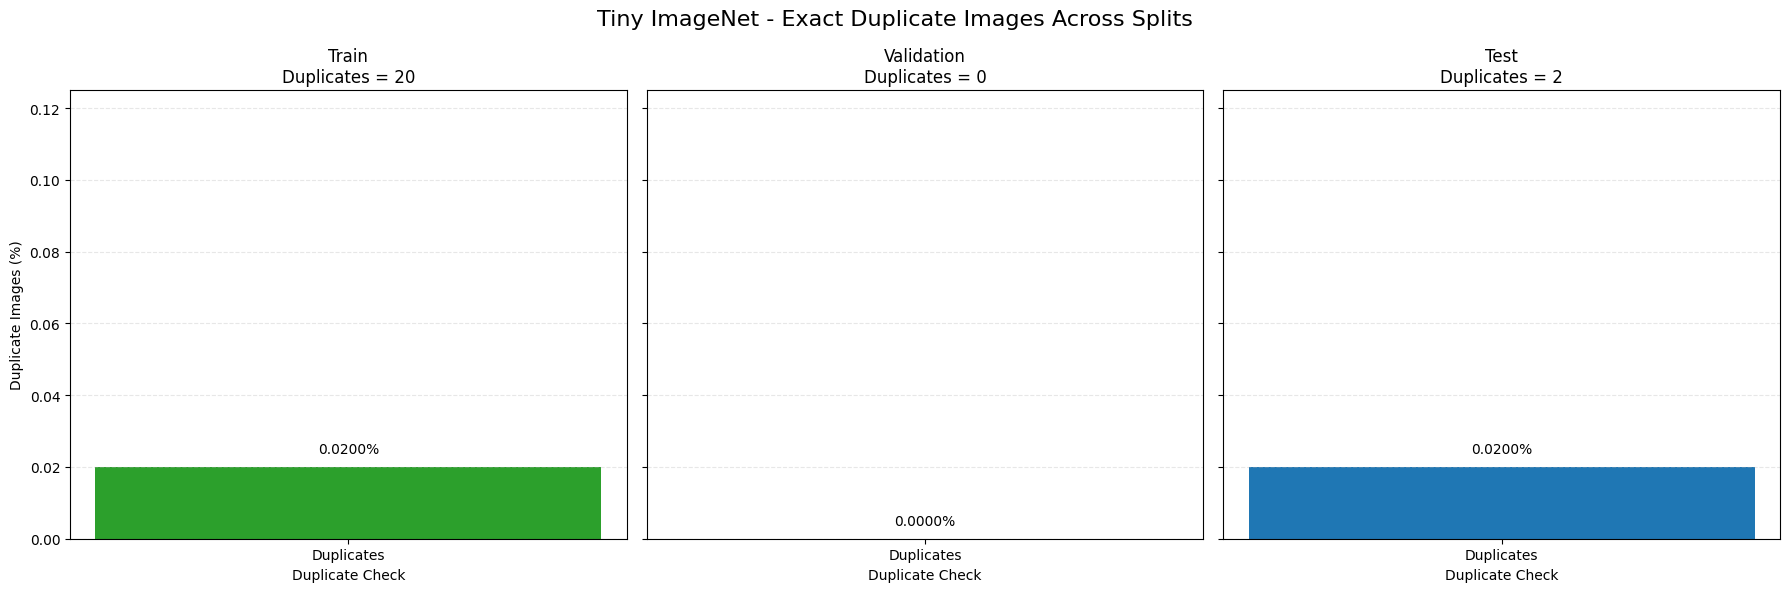

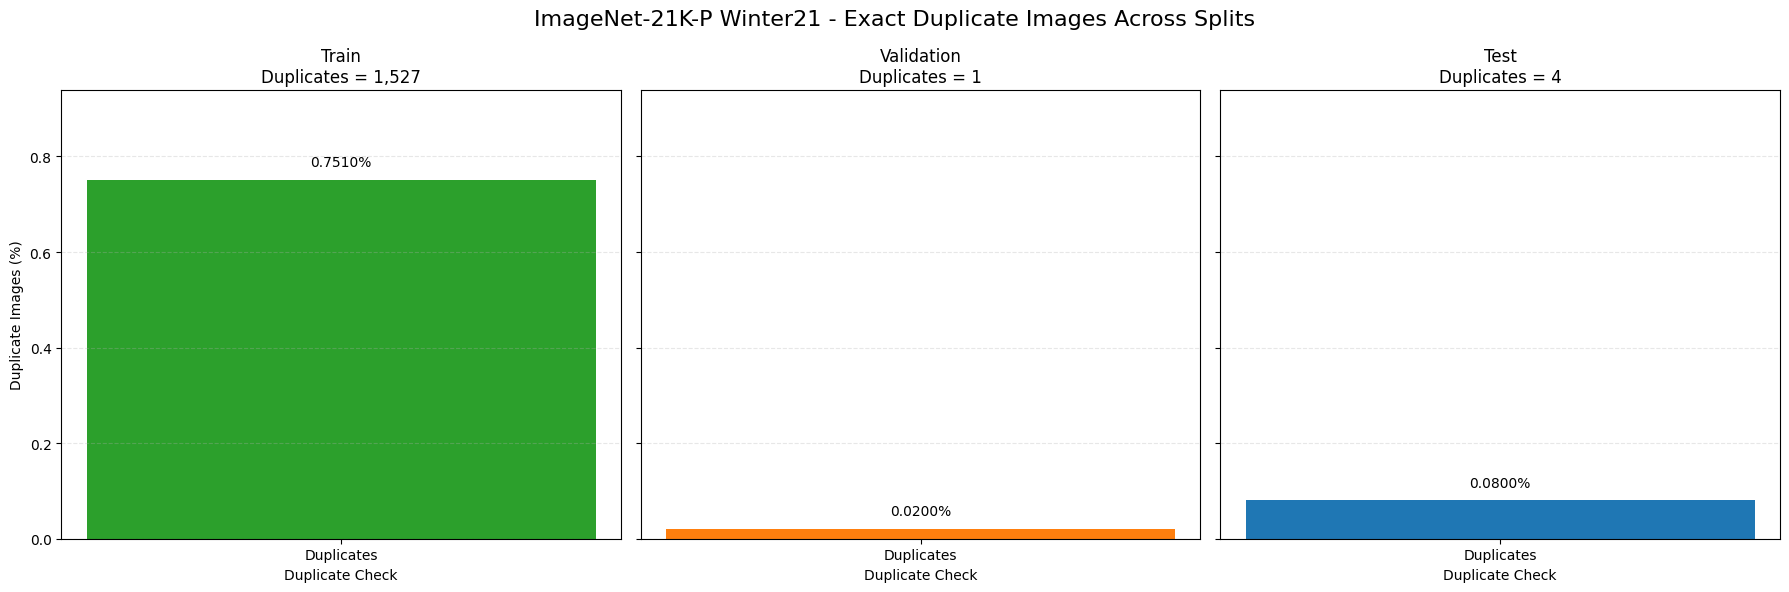

In [48]:
duplicate_leakage_analysis.plot_duplicate_images(
    duplicate_stats
)

##### Leakage plots

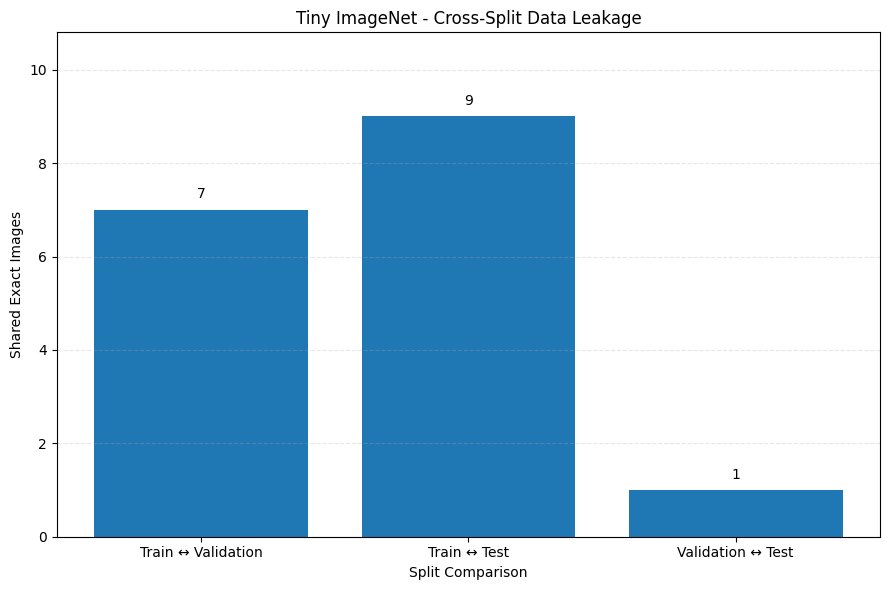

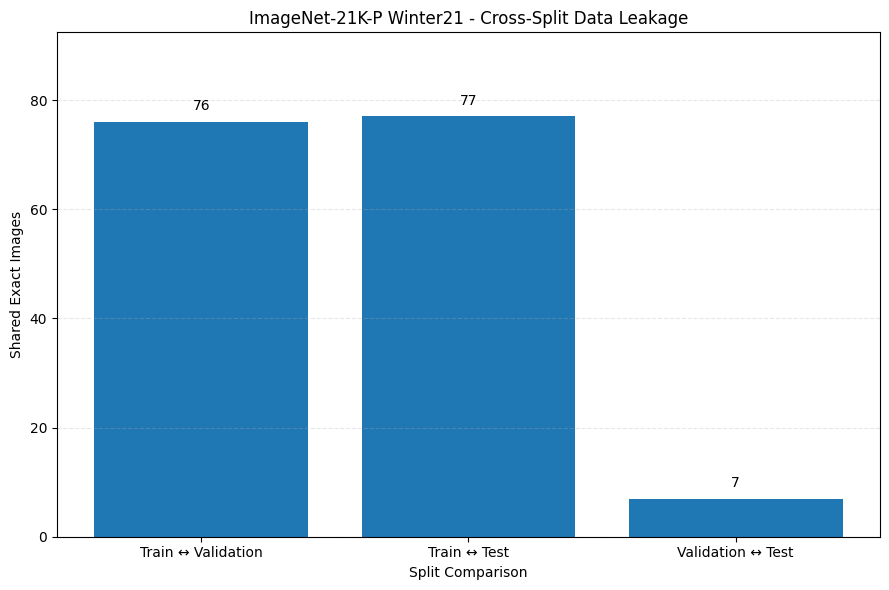

In [49]:
duplicate_leakage_analysis.plot_data_leakage(
    duplicate_stats
)

##### Label consistency check

In [50]:
duplicate_label_details = (
    duplicate_leakage_analysis.analyze_duplicate_label_consistency(
        duplicate_details
    )
)

duplicate_label_details

,Dataset,Hash,Occurrences,Splits,Unique Targets,Targets,Label Consistency
0,tiny_imagenet,083118a5bbd48877661e067f24d7988a61bc47e5d7e283...,2,"Train, Validation",2,"11, 20",Conflict
1,tiny_imagenet,1ceced1539c5e09874ee698b9c49380f30beed084ca9dc...,2,"Test, Train",2,"0, 186",Conflict
2,tiny_imagenet,1e412b2ddb0d49bd3bf15bb24bf0d146f214b42ecf4417...,2,"Test, Train",2,"0, 140",Conflict
3,tiny_imagenet,24950b78fcc0e2ad486cf2982ad02d4b3f9cf6e020e8c0...,2,"Train, Validation",2,"101, 132",Conflict
4,tiny_imagenet,314992fee8ab2323e771f04f76afbc73bd17be9fe7f83e...,2,"Train, Validation",2,"105, 120",Conflict
...,...,...,...,...,...,...,...
170,imagenet21k_p,f7a023bde1e994e2ae7df439fce9ea2bb57948aefa395e...,2,"Train, Validation",2,"9, 10",Conflict
171,imagenet21k_p,fb4b1d6cd967b6fad2cf470f0866f0e4c2f61d838ce78a...,2,"Train, Validation",2,"160, 161",Conflict
172,imagenet21k_p,fbfb318ac864fc23d2a49498a35fede9970b22b7de4063...,2,"Train, Validation",1,61,Consistent
173,imagenet21k_p,fda17d72b4ea325c10d0a80c20d6d5ba69f69c6a3a0208...,2,"Test, Train",2,"22, 23",Conflict


In [51]:
duplicate_label_summary = (
    duplicate_leakage_analysis.duplicate_label_consistency_summary(
        duplicate_label_details
    )
)

duplicate_label_summary

,Dataset,Label Consistency,Leakage Groups
0,imagenet21k_p,Conflict,53
1,imagenet21k_p,Consistent,105
2,tiny_imagenet,Conflict,17


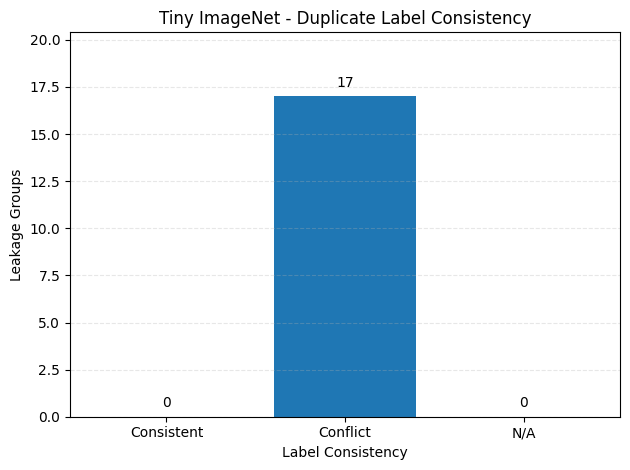

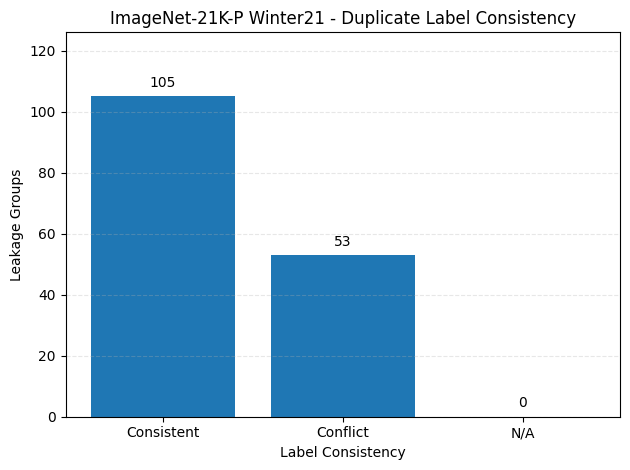

In [52]:
duplicate_leakage_analysis.plot_label_consistency(
    duplicate_label_details
)

## F. Class Variation

#### 16. Intra-Class Variation Analysis

In [53]:
import src.eda.class_variation.intra_class_variation_analysis as intra_class_variation_analysis

In [54]:

intra_class_stats, intra_class_details = (
    intra_class_variation_analysis.intra_class_variation_analysis(
        dataset_list=dataset_list,
        max_classes=200,
        max_images_per_class=50,
        min_images_per_class=2,
        feature_size=32,
        seed=42,
    )
)

intra_class_stats

imagenet21k_p splits: 100%|██████████| 3/3 [00:26<00:00,  8.94s/it]


,Dataset,Split,Label Status,Classes Available,Classes Analyzed,Images Analyzed,Mean Intra-Class Variation,Median Intra-Class Variation,Std Intra-Class Variation,Min Intra-Class Variation,Max Intra-Class Variation,Status
0,tiny_imagenet,Train,Labelled,200,200,10000,0.233939,0.23155,0.021839,0.176067,0.2931,Analyzed
1,tiny_imagenet,Validation,Labelled,200,200,10000,0.233351,0.233378,0.020969,0.17076,0.292181,Analyzed
2,tiny_imagenet,Test,Unlabelled,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
3,imagenet21k_p,Train,Labelled,200,200,10000,0.237231,0.234041,0.037519,0.157668,0.332381,Analyzed
4,imagenet21k_p,Validation,Labelled,200,200,5000,0.234512,0.233983,0.037072,0.159912,0.331671,Analyzed
5,imagenet21k_p,Test,Labelled,200,200,5000,0.232784,0.224424,0.038429,0.146298,0.333782,Analyzed


In [55]:
intra_class_details.sort_values(
    "Intra-Class Variation",
    ascending=False,
).head(5)

,Dataset,Split,Class ID,Class Name,Available Images,Analyzed Images,Intra-Class Variation,Min Distance,Max Distance,Mean Distance,Median Distance
906,imagenet21k_p,Test,106,oboe,25,25,0.333782,0.137699,0.523379,0.333782,0.323825
464,imagenet21k_p,Train,64,compact disk,1077,50,0.332381,0.199273,0.498971,0.332381,0.338362
663,imagenet21k_p,Validation,63,collar,25,25,0.331671,0.173148,0.462130,0.331671,0.348443
864,imagenet21k_p,Test,64,compact disk,25,25,0.329085,0.208471,0.472882,0.329085,0.309762
523,imagenet21k_p,Train,123,spatula,1416,50,0.325631,0.191543,0.516340,0.325631,0.327698


In [56]:
intra_class_details.sort_values(
    "Intra-Class Variation",
    ascending=True,
).head(5)

,Dataset,Split,Class ID,Class Name,Available Images,Analyzed Images,Intra-Class Variation,Min Distance,Max Distance,Mean Distance,Median Distance
992,imagenet21k_p,Test,192,dodder,25,25,0.146298,0.085917,0.300303,0.146298,0.140169
824,imagenet21k_p,Test,24,grebe,25,25,0.153718,0.083056,0.283103,0.153718,0.129778
994,imagenet21k_p,Test,194,royal fern,25,25,0.155753,0.097839,0.260574,0.155753,0.146540
424,imagenet21k_p,Train,24,grebe,1230,50,0.157668,0.062856,0.384090,0.157668,0.147309
967,imagenet21k_p,Test,167,winter purslane,25,25,0.158924,0.102663,0.226585,0.158924,0.155883


##### Visualization 1: Variation distribution across splits

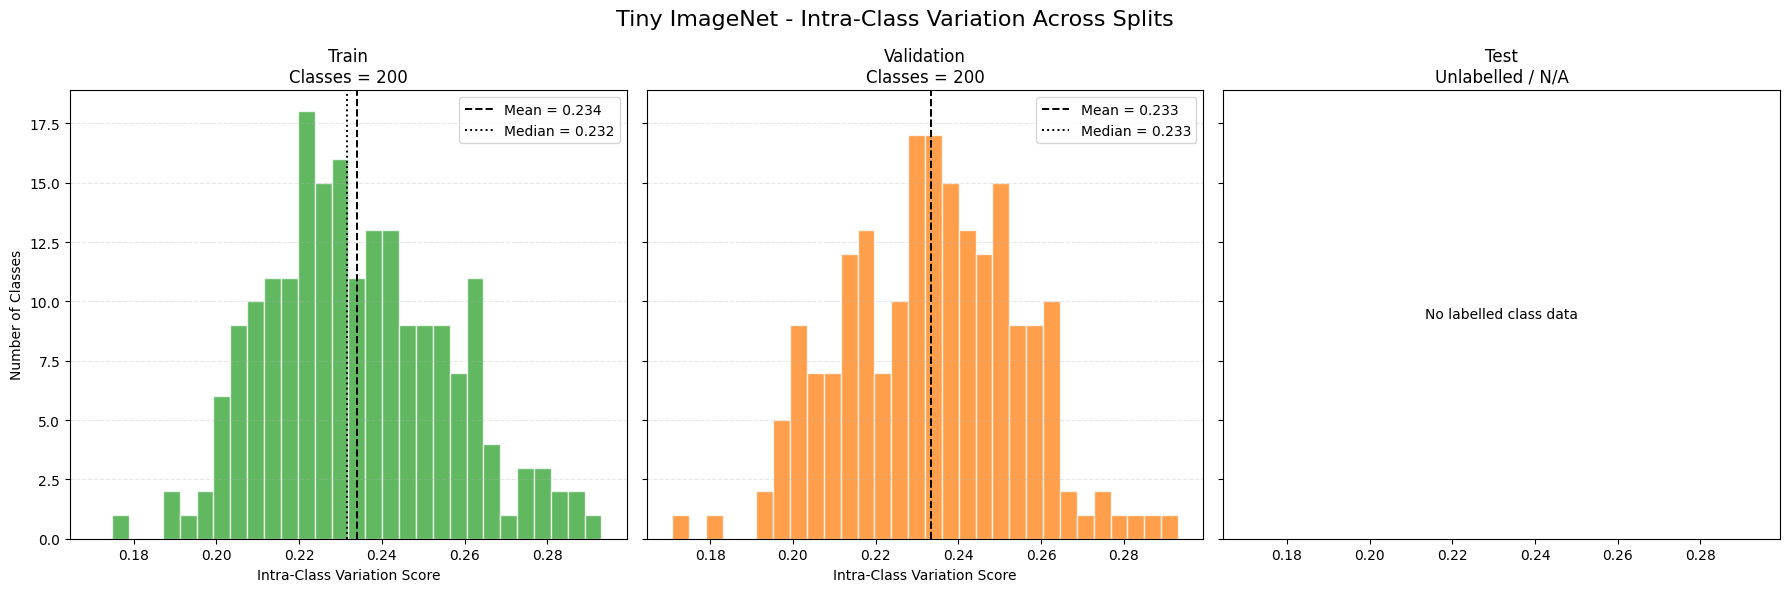

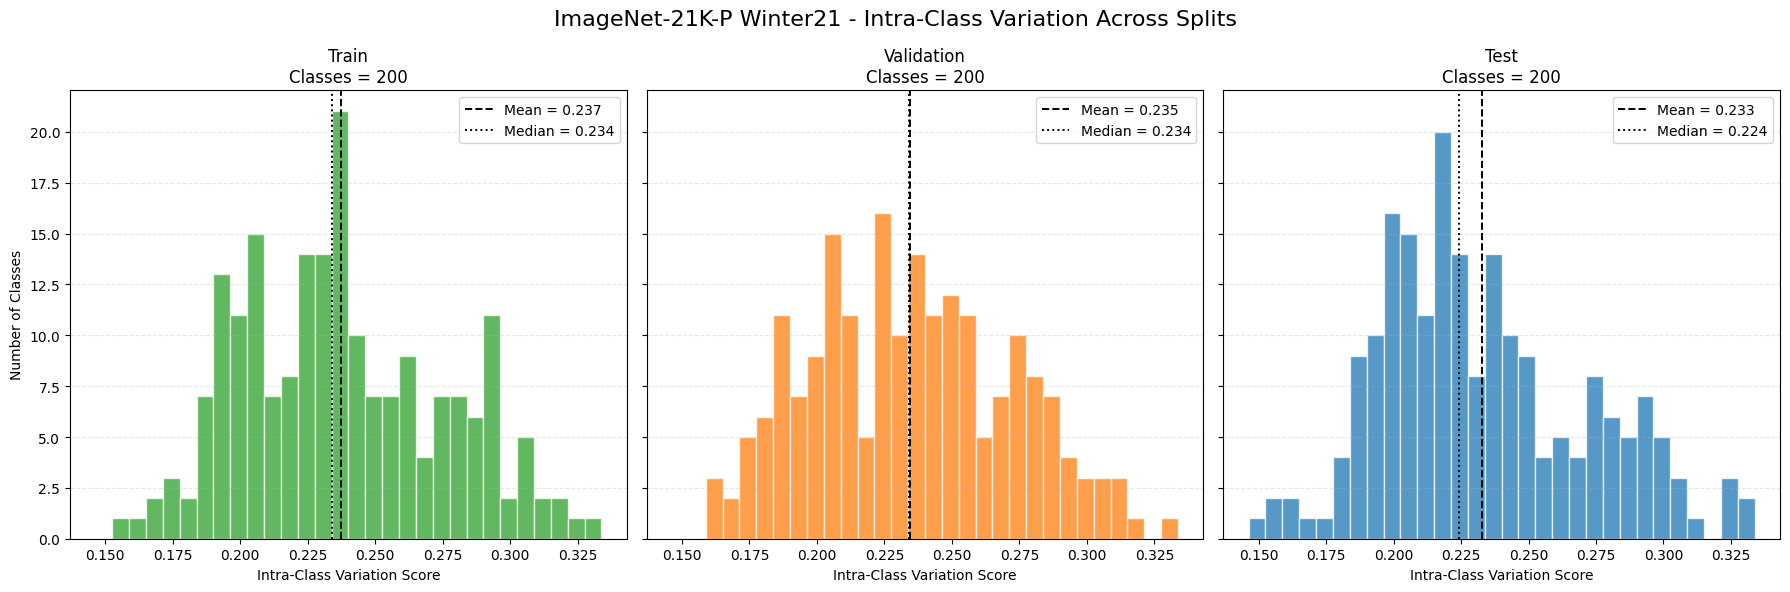

In [57]:
intra_class_variation_analysis.plot_intra_class_distribution(
    intra_class_details
)

##### Visualization 2: Top 10 most variable classes

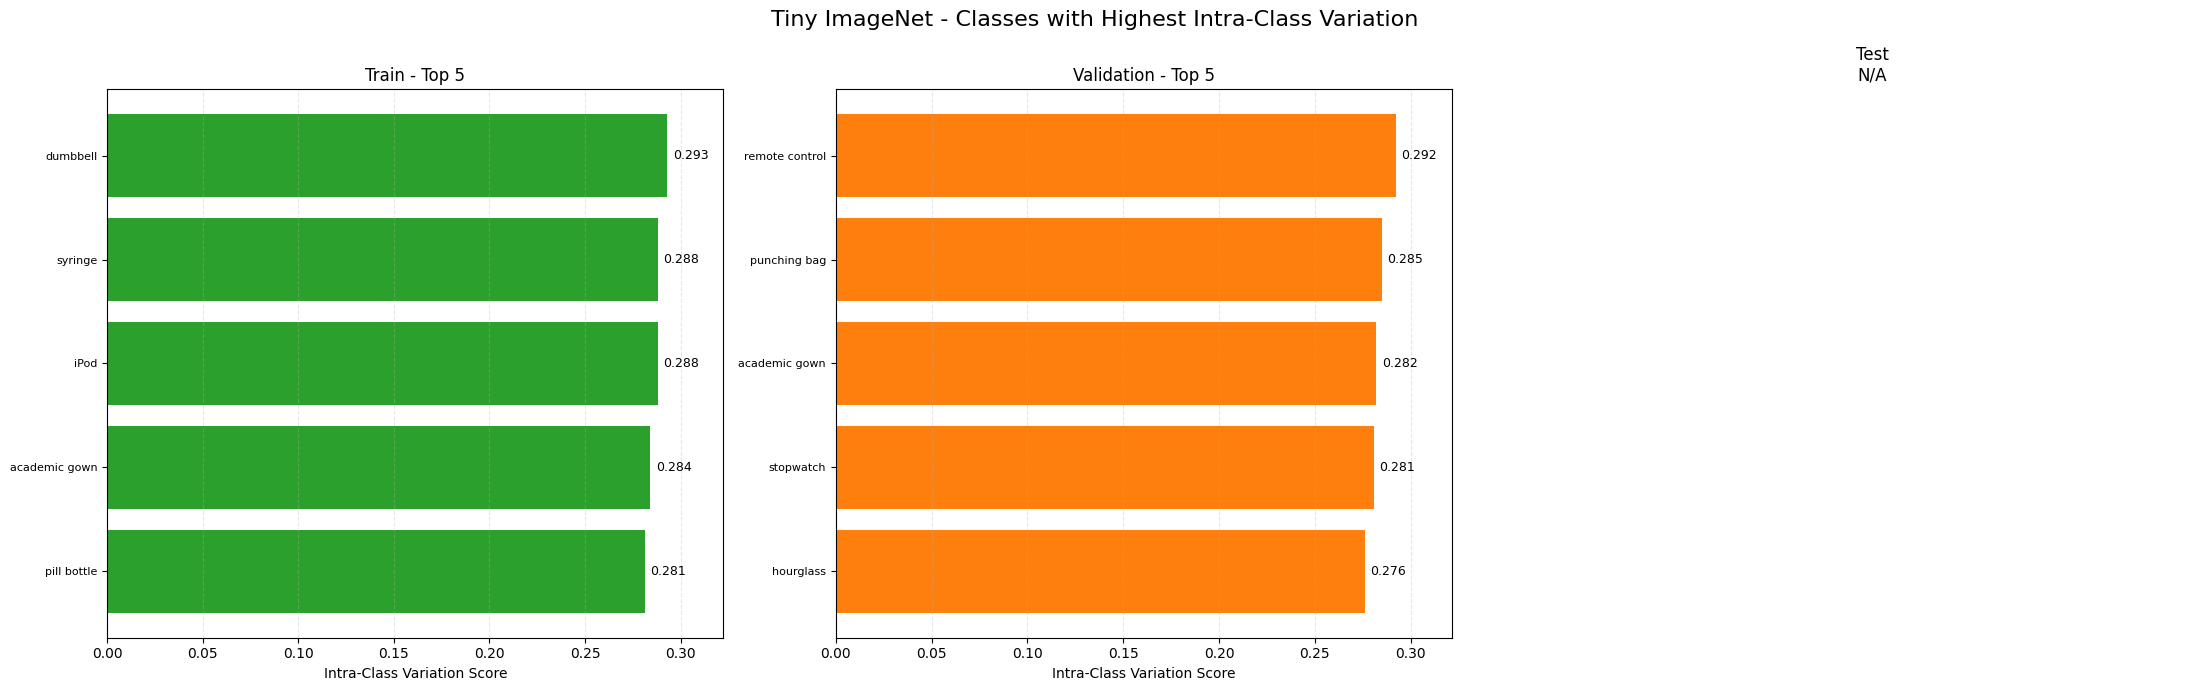

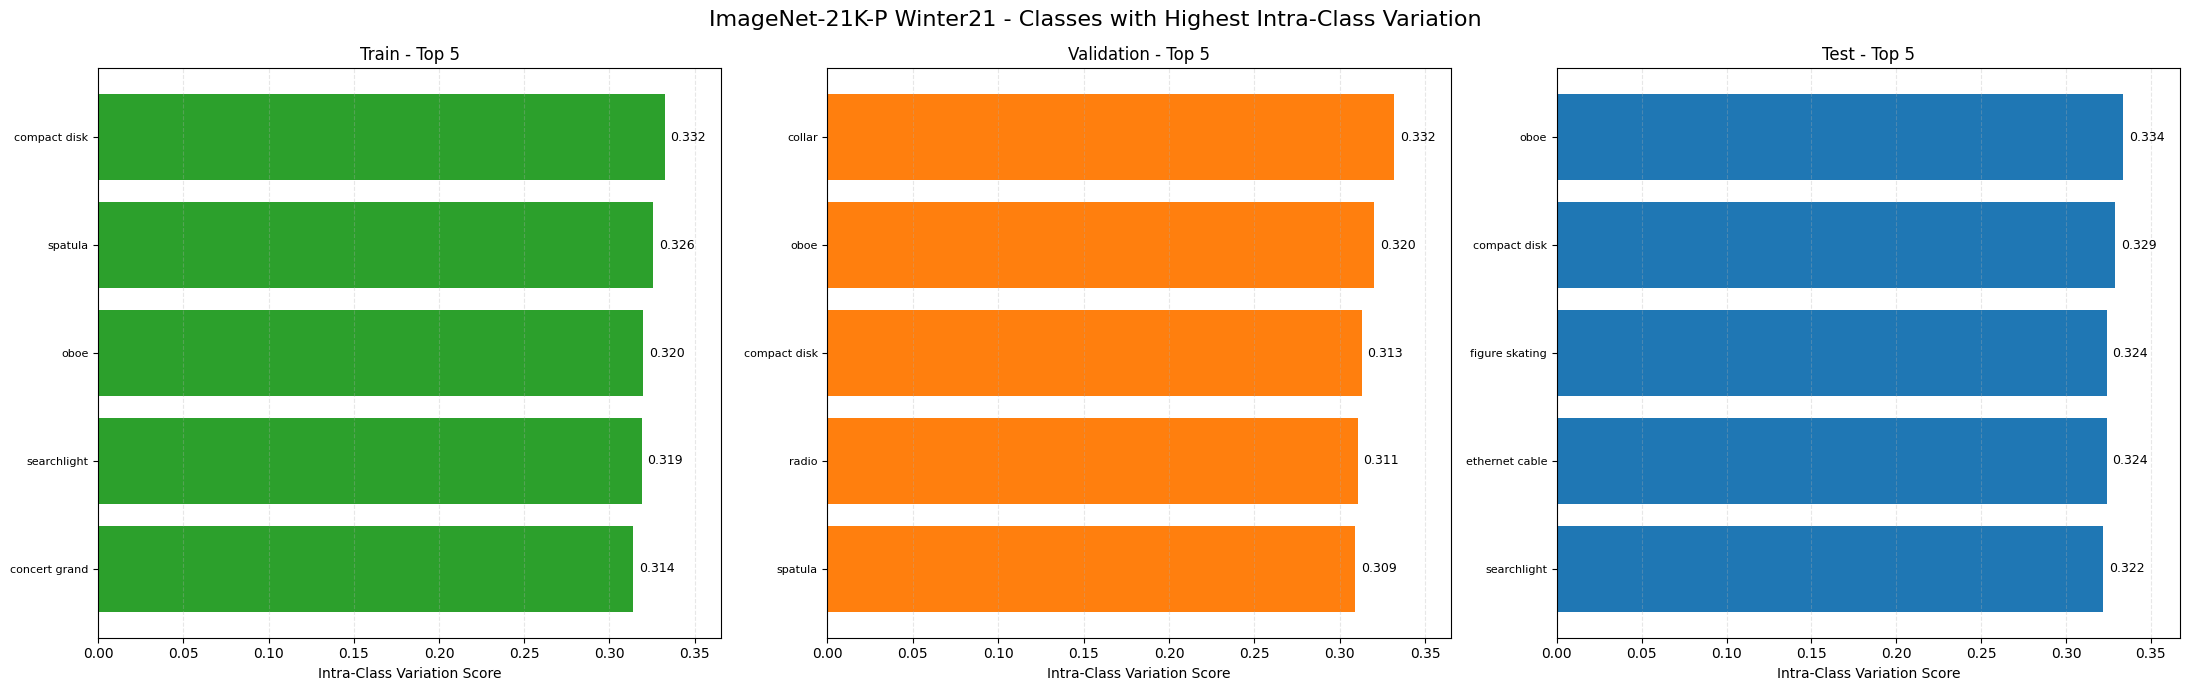

In [58]:
intra_class_variation_analysis.plot_top_variable_classes(
    intra_class_details,
    top_n=5,
)

##### Visualization 3: Lowest 10 variable classes

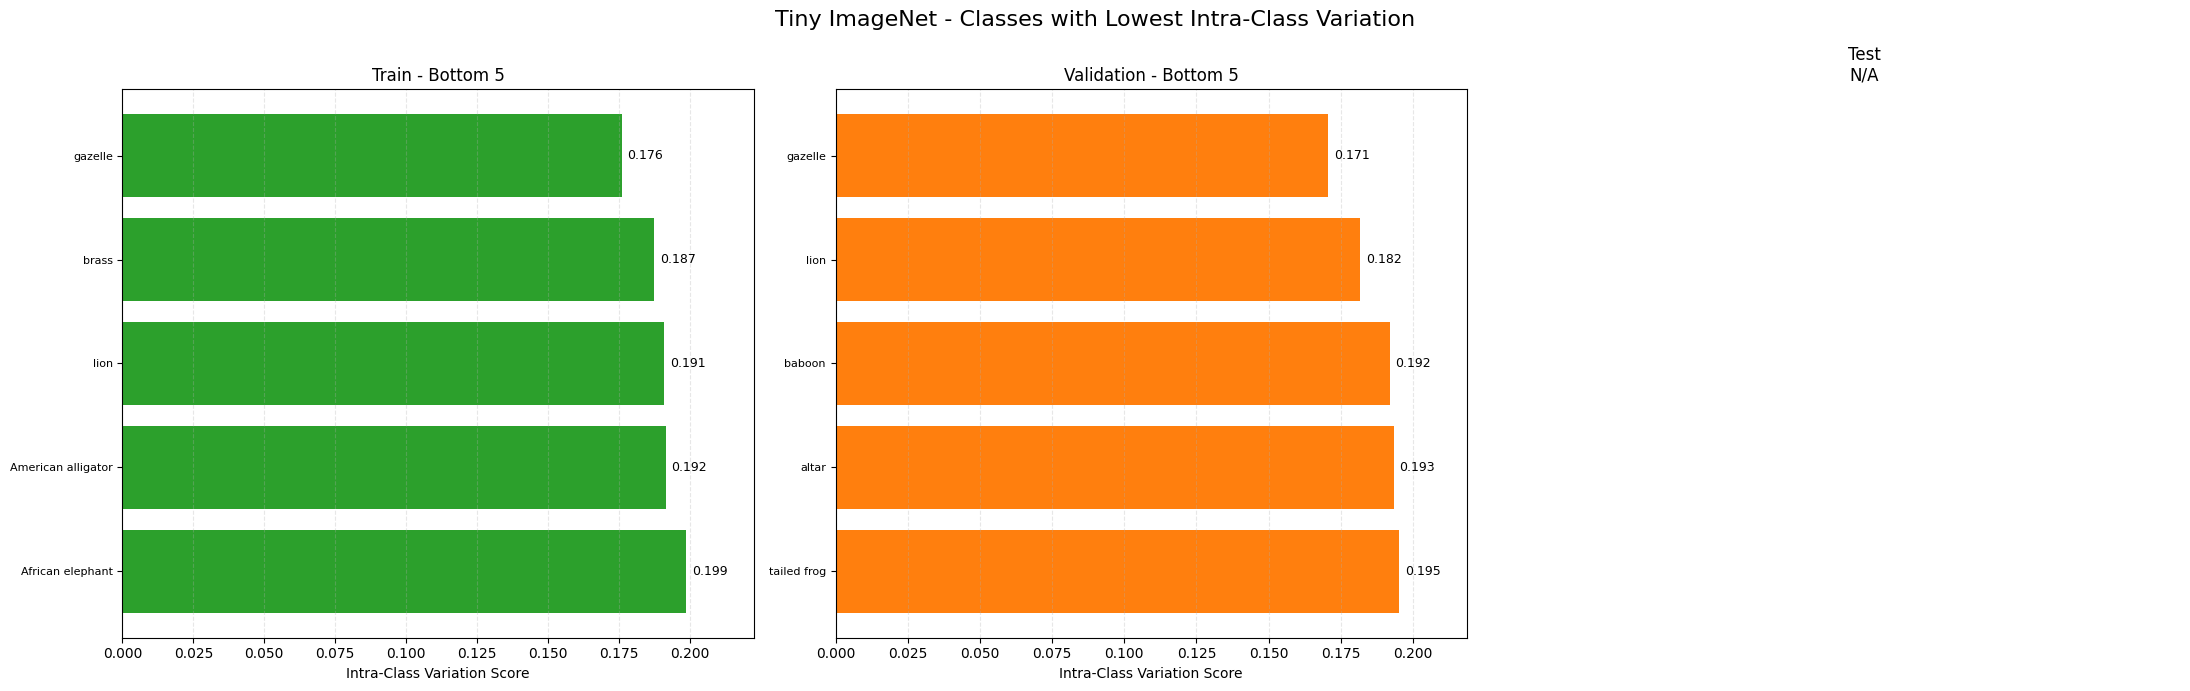

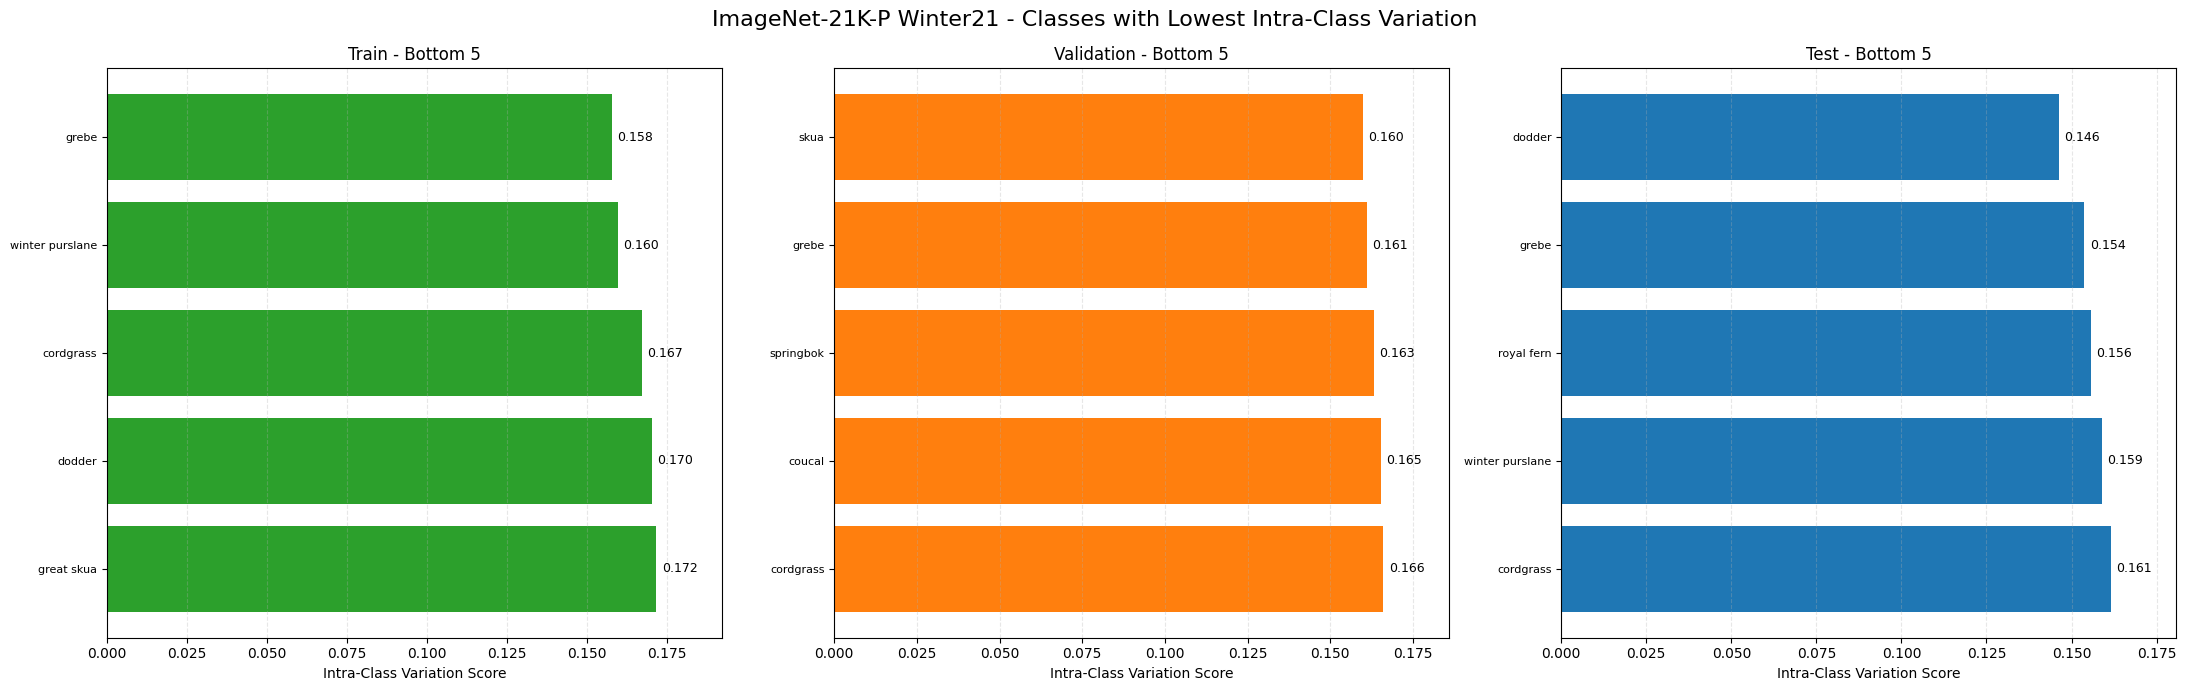

In [59]:
intra_class_variation_analysis.plot_least_variable_classes(
    intra_class_details,
    bottom_n=5,
)

#### 17. Inter-Class Variation Analysis

In [60]:
import src.eda.class_variation.inter_class_variation_analysis as inter_class_variation_analysis

In [61]:
inter_class_stats, inter_class_details = (
    inter_class_variation_analysis.inter_class_variation_analysis(
        dataset_list=dataset_list,
        max_classes=200,
        max_images_per_class=50,
        min_images_per_class=2,
        feature_size=32,
        seed=42,
    )
)

inter_class_stats

Train:  99%|█████████▉| 198/200 [00:03<00:00, 56.78it/s]
                                                        
Validation:  97%|█████████▋| 194/200 [00:03<00:00, 62.64it/s]
                                                             
Train: 100%|██████████| 200/200 [00:14<00:00, 11.77it/s]
                                                        
Validation: 100%|██████████| 200/200 [00:07<00:00, 21.34it/s]
                                                             
Test:  99%|█████████▉| 198/200 [00:06<00:00, 29.56it/s]
                                                       
imagenet21k_p splits: 100%|██████████| 3/3 [00:29<00:00,  9.78s/it]  


,Dataset,Split,Label Status,Classes Available,Classes Analyzed,Images Analyzed,Class Pairs,Mean Inter-Class Distance,Median Inter-Class Distance,Std Inter-Class Distance,Min Inter-Class Distance,Max Inter-Class Distance,Status
0,tiny_imagenet,Train,Labelled,200,200,10000,19900,0.095929,0.089254,0.03491,0.030106,0.307577,Analyzed
1,tiny_imagenet,Validation,Labelled,200,200,10000,19900,0.098445,0.092607,0.03487,0.032256,0.280165,Analyzed
2,tiny_imagenet,Test,Unlabelled,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
3,imagenet21k_p,Train,Labelled,200,200,10000,19900,0.144993,0.128078,0.070785,0.028791,0.527822,Analyzed
4,imagenet21k_p,Validation,Labelled,200,200,5000,19900,0.154166,0.136878,0.068864,0.042685,0.508814,Analyzed
5,imagenet21k_p,Test,Labelled,200,200,5000,19900,0.155262,0.138169,0.070567,0.042005,0.591249,Analyzed


##### Closest classes overall

In [62]:
inter_class_details.sort_values(
    "Inter-Class Distance",
    ascending=True,
).head(5)

,Dataset,Split,Class A ID,Class A Name,Class A Images,Class B ID,Class B Name,Class B Images,Inter-Class Distance
57491,imagenet21k_p,Train,133,washtub,50,136,whip,50,0.028791
41569,imagenet21k_p,Train,9,hawk,50,24,grebe,50,0.028805
17626,tiny_imagenet,Train,132,pole,50,137,projectile,50,0.030106
12640,tiny_imagenet,Train,79,broom,50,80,bucket,50,0.032224
21081,tiny_imagenet,Validation,6,trilobite,50,9,tarantula,50,0.032256


##### Most separated classes

In [63]:
inter_class_details.sort_values(
    "Inter-Class Distance",
    ascending=False,
).head(5)

,Dataset,Split,Class A ID,Class A Name,Class A Images,Class B ID,Class B Name,Class B Images,Inter-Class Distance
83058,imagenet21k_p,Test,18,nematode,25,48,antiperspirant,25,0.591249
83089,imagenet21k_p,Test,18,nematode,25,79,entrenching tool,25,0.583376
83071,imagenet21k_p,Test,18,nematode,25,61,chafing dish,25,0.541682
83114,imagenet21k_p,Test,18,nematode,25,104,nailfile,25,0.532861
83110,imagenet21k_p,Test,18,nematode,25,100,light pen,25,0.530231


##### Distribution plots

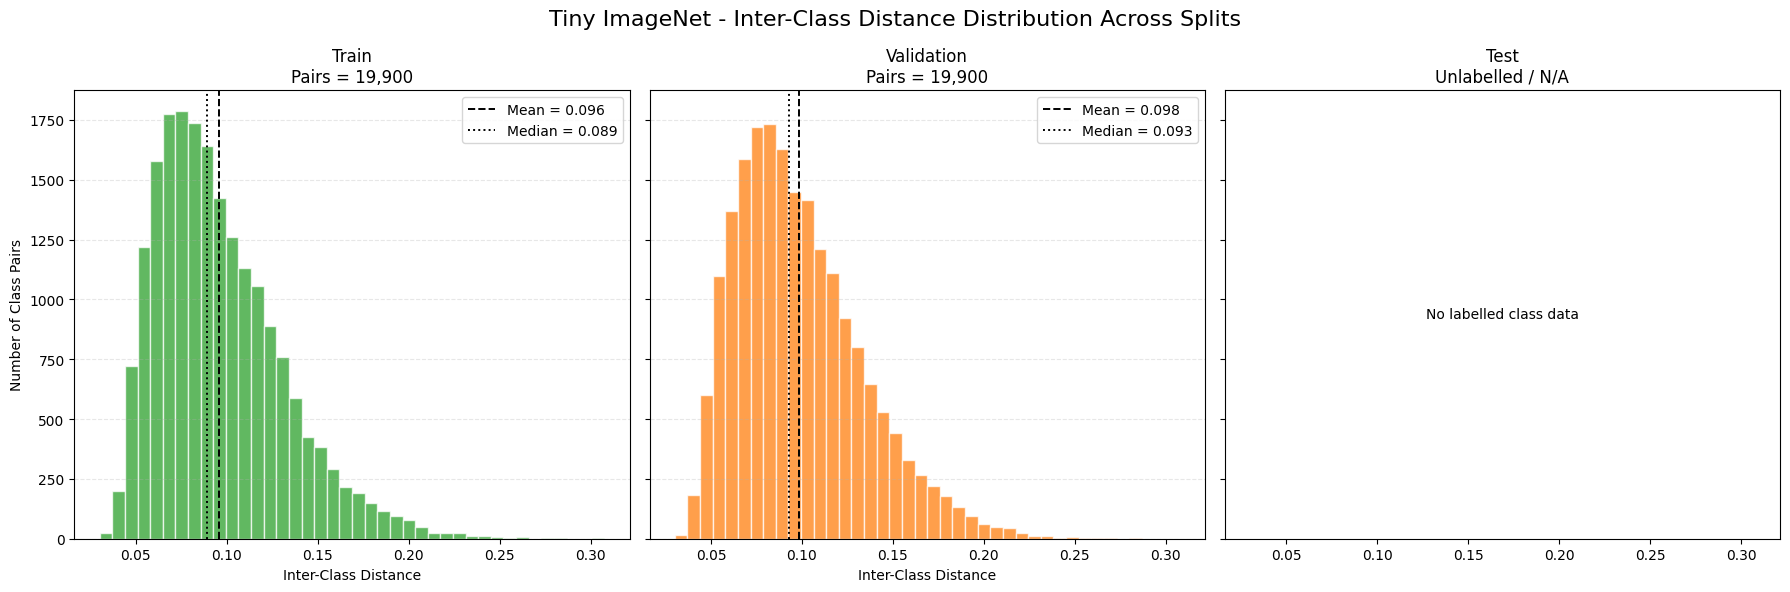

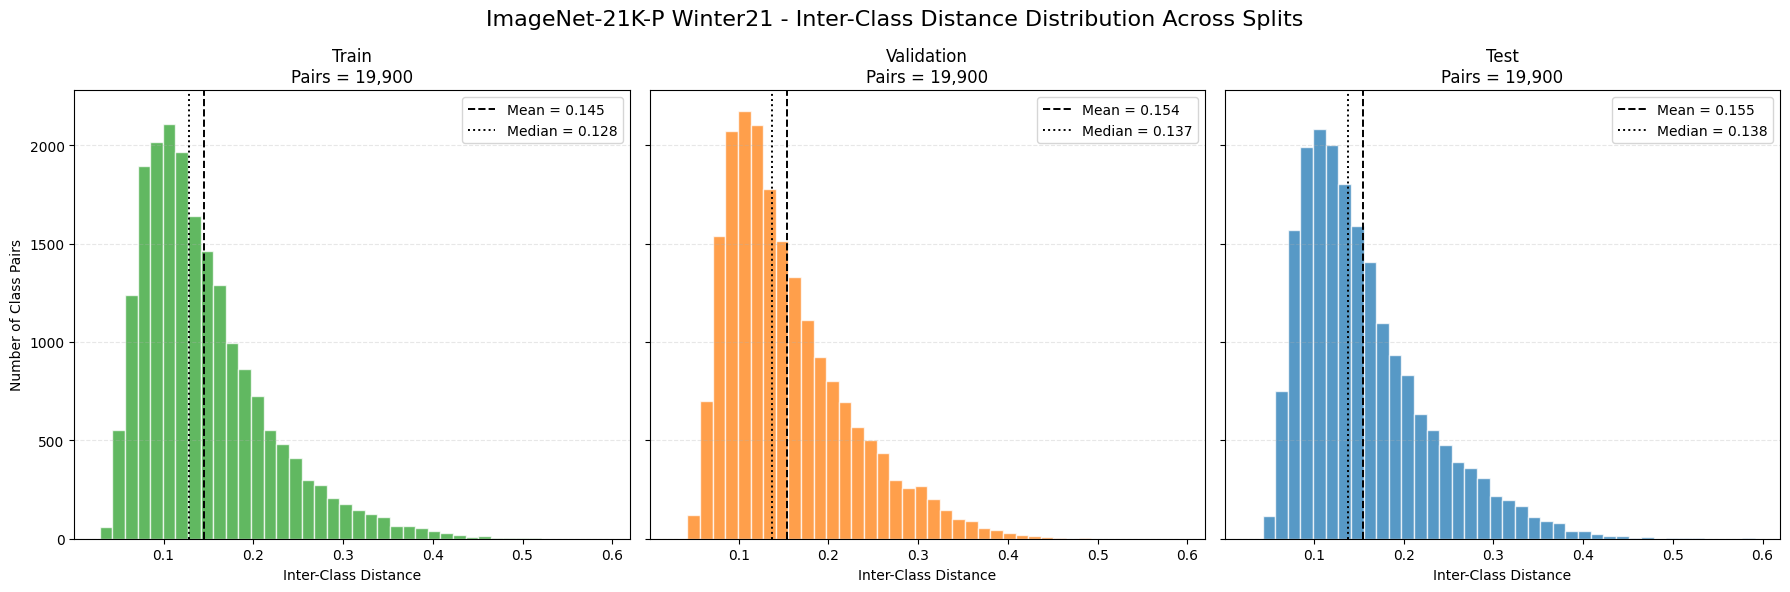

In [64]:
inter_class_variation_analysis.plot_inter_class_distribution(
    inter_class_details
)

##### Most visually similar class pairs

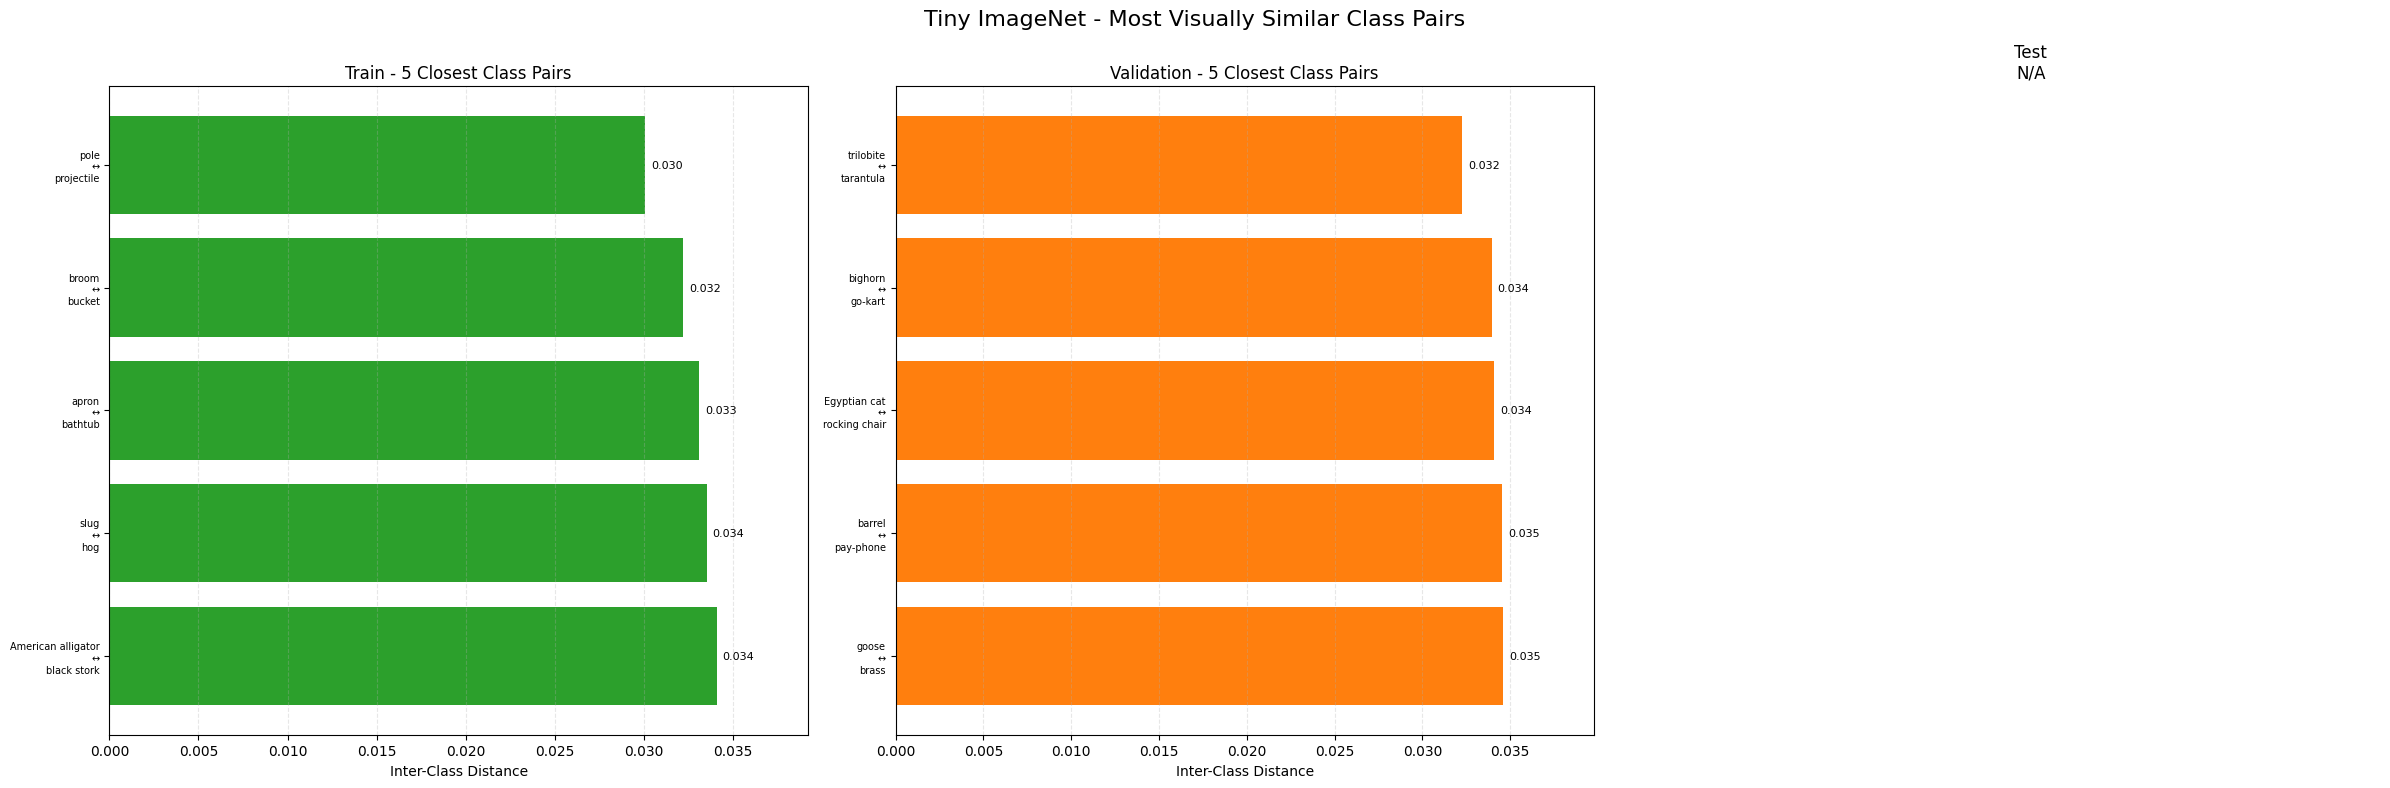

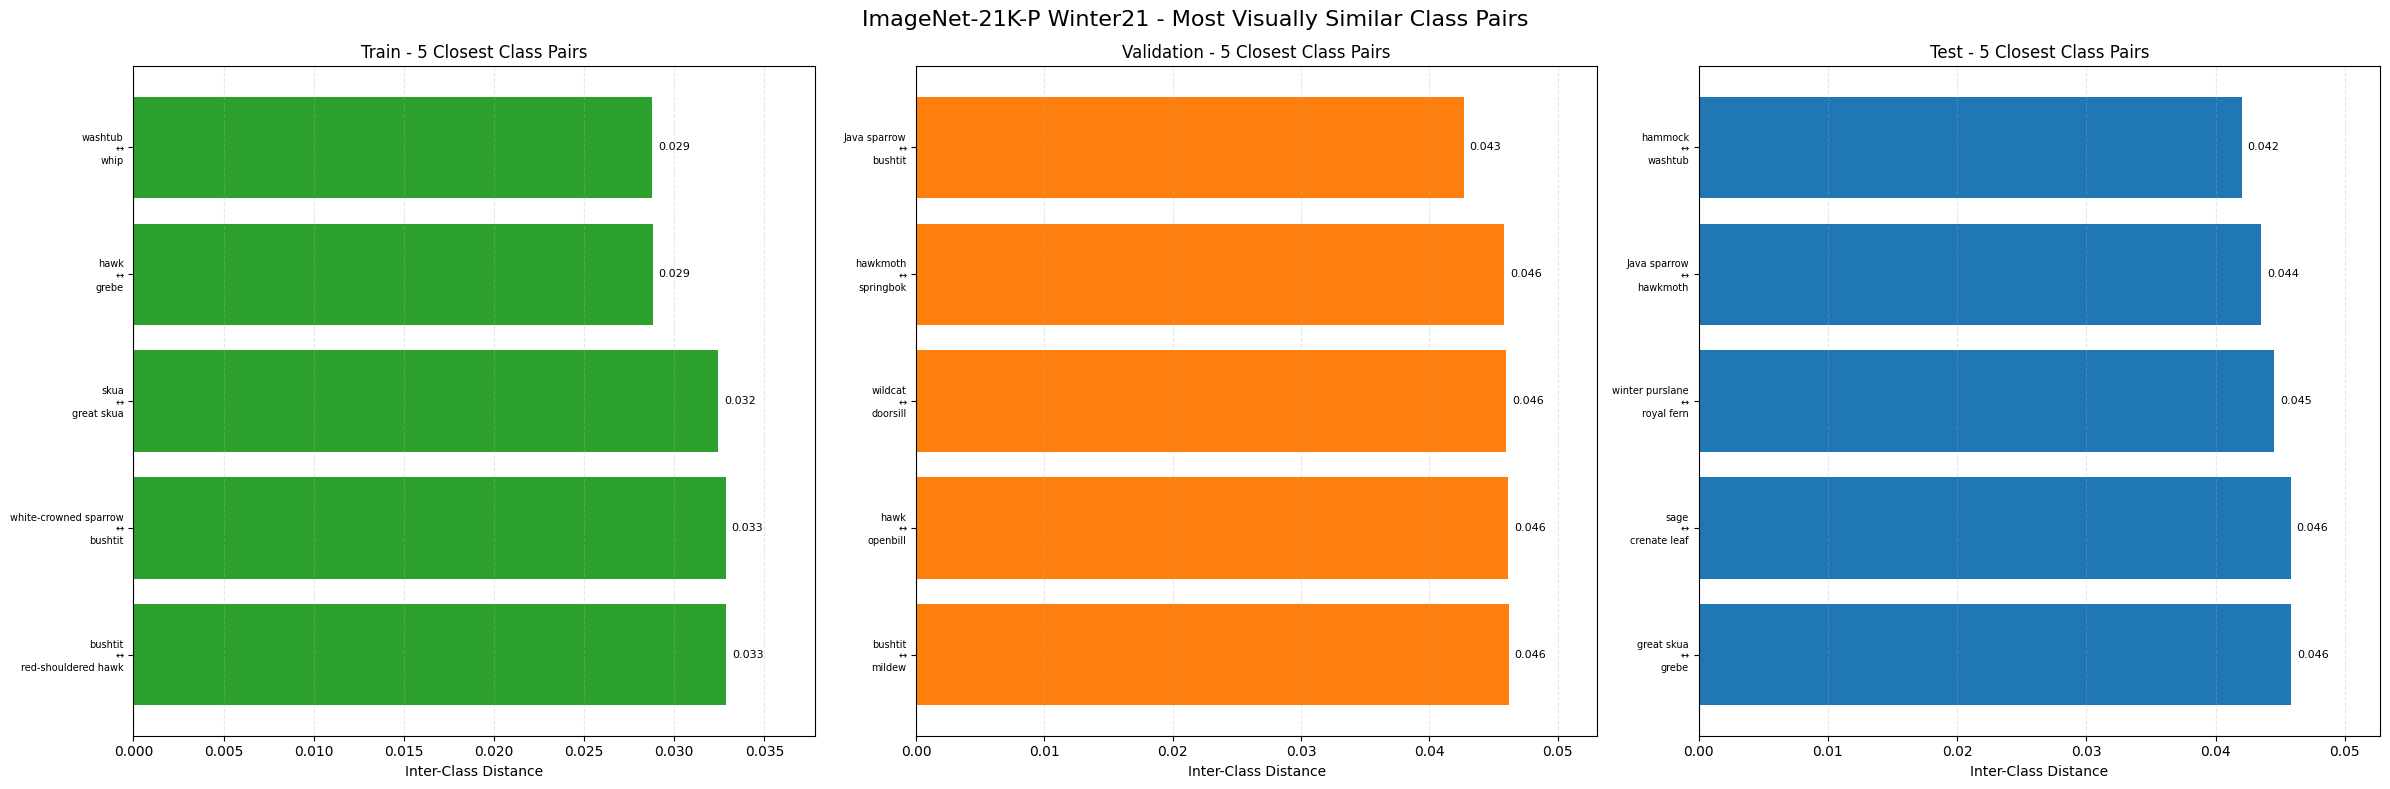

In [65]:
inter_class_variation_analysis.plot_closest_class_pairs(
    inter_class_details,
    top_n=5,
    min_plot_images=10,
)

##### Most visually separated class pairs

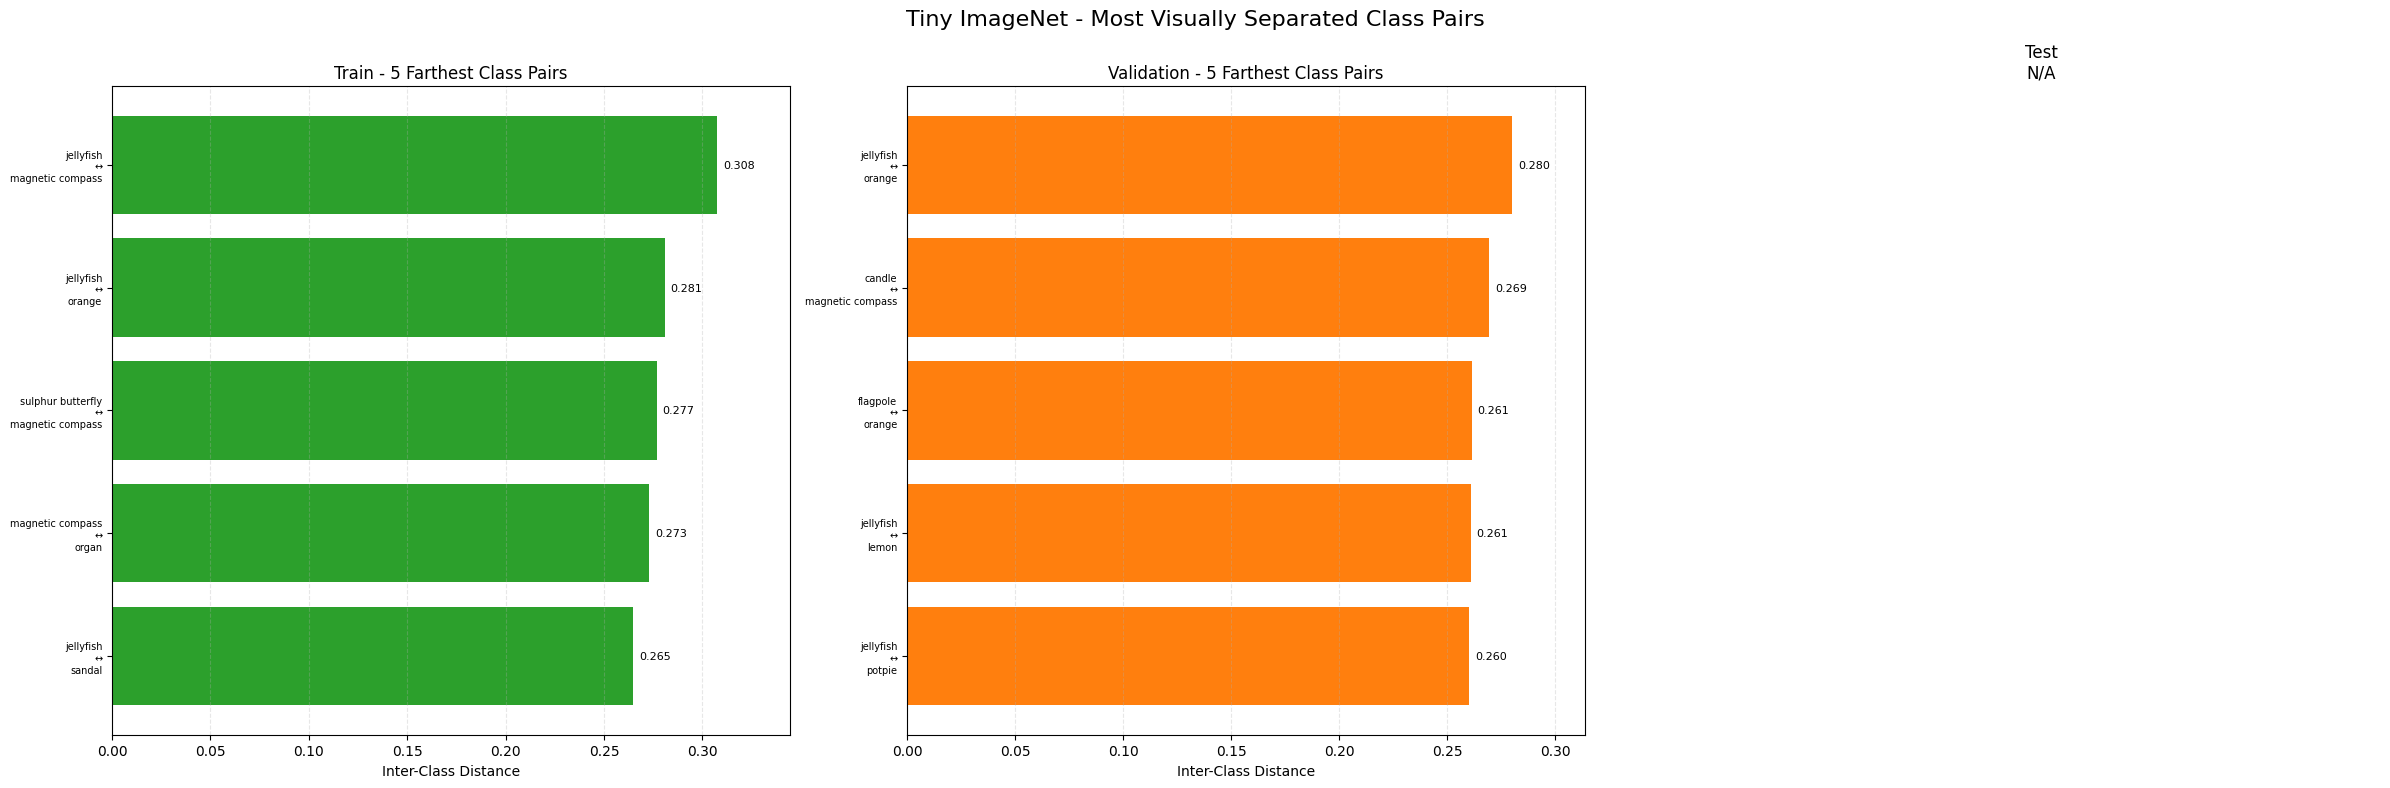

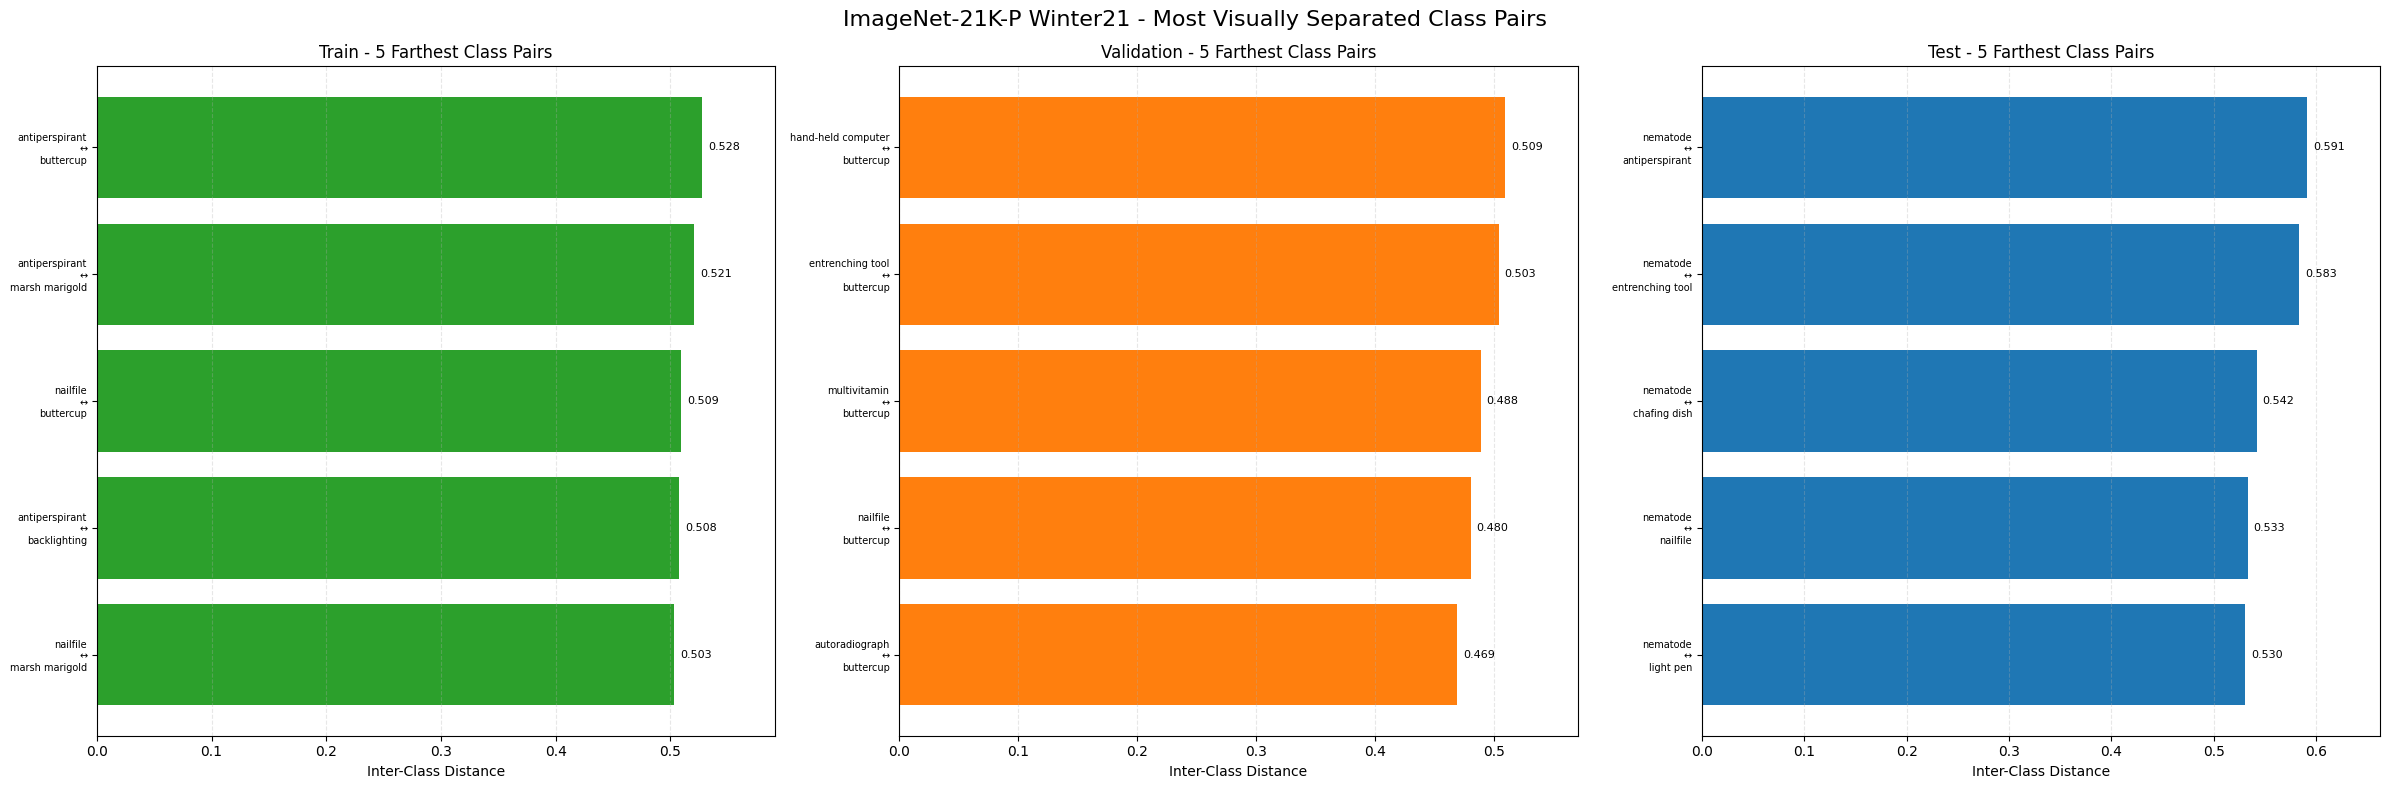

In [66]:
inter_class_variation_analysis.plot_farthest_class_pairs(
    inter_class_details,
    top_n=5,
    min_plot_images=10,
)

## Dataset Difficulty

#### 18. Dataset Difficulty Comparison

In [67]:
import src.eda.dataset_difficulty.dataset_difficulty_analysis as dataset_difficulty_analysis

In [69]:
difficulty_stats = (
    dataset_difficulty_analysis.dataset_difficulty_analysis(
        class_distribution,
        image_dimensions,
        intra_class_stats,
        inter_class_stats,
        duplicate_stats,
    )
)

difficulty_stats

tiny_imagenet splits:   0%|          | 0/3 [00:00<?, ?it/s]
                                                           
Structural ranking: 100%|██████████| 3/3 [00:00<00:00, 1796.53it/s]


,Dataset,Split,Label Status,Total Images,Classes,Imbalance Ratio,Class CV,Unique Resolutions,Resolution Diversity (%),Mean Intra-Class Variation,Mean Inter-Class Distance,Low-Level Structural Difficulty Ratio,Relative Structural Rank,Duplicate (%),Dataset Leakage Groups,Dataset Leakage Status,Status
0,tiny_imagenet,Train,Labelled,100000,200.0,1.000,0.000,1,0.0010,0.233939,0.095929,2.438668,1,0.020,17,Leakage Detected,Analyzed
1,tiny_imagenet,Validation,Labelled,10000,200.0,1.000,0.000,1,0.0100,0.233351,0.098445,2.370369,1,0.000,17,Leakage Detected,Analyzed
2,tiny_imagenet,Test,Unlabelled,10000,NaN,NaN,NaN,1,0.0100,NaN,NaN,NaN,<NA>,0.020,17,Leakage Detected,N/A
3,imagenet21k_p,Train,Labelled,203329,200.0,5.328,0.335,36123,17.7658,0.237231,0.144993,1.636155,2,0.751,158,Leakage Detected,Analyzed
4,imagenet21k_p,Validation,Labelled,5000,200.0,1.000,0.000,2236,44.7200,0.234512,0.154166,1.521165,2,0.020,158,Leakage Detected,Analyzed
5,imagenet21k_p,Test,Labelled,5000,200.0,1.000,0.000,2216,44.3200,0.232784,0.155262,1.499298,1,0.080,158,Leakage Detected,Analyzed


###### Training-set comparison

In [70]:
train_difficulty_summary = (
    dataset_difficulty_analysis.get_train_difficulty_summary(
        difficulty_stats
    )
)

train_difficulty_summary

,Dataset,Total Images,Classes,Imbalance Ratio,Class CV,Unique Resolutions,Resolution Diversity (%),Mean Intra-Class Variation,Mean Inter-Class Distance,Low-Level Structural Difficulty Ratio,Relative Structural Rank,Duplicate (%),Dataset Leakage Groups,Dataset Leakage Status
0,tiny_imagenet,100000,200.0,1.000,0.000,1,0.0010,0.233939,0.095929,2.438668,1,0.020,17,Leakage Detected
1,imagenet21k_p,203329,200.0,5.328,0.335,36123,17.7658,0.237231,0.144993,1.636155,2,0.751,158,Leakage Detected


##### Difficulty map

Structural difficulty plots: 100%|██████████| 3/3 [00:00<00:00, 317.26it/s]


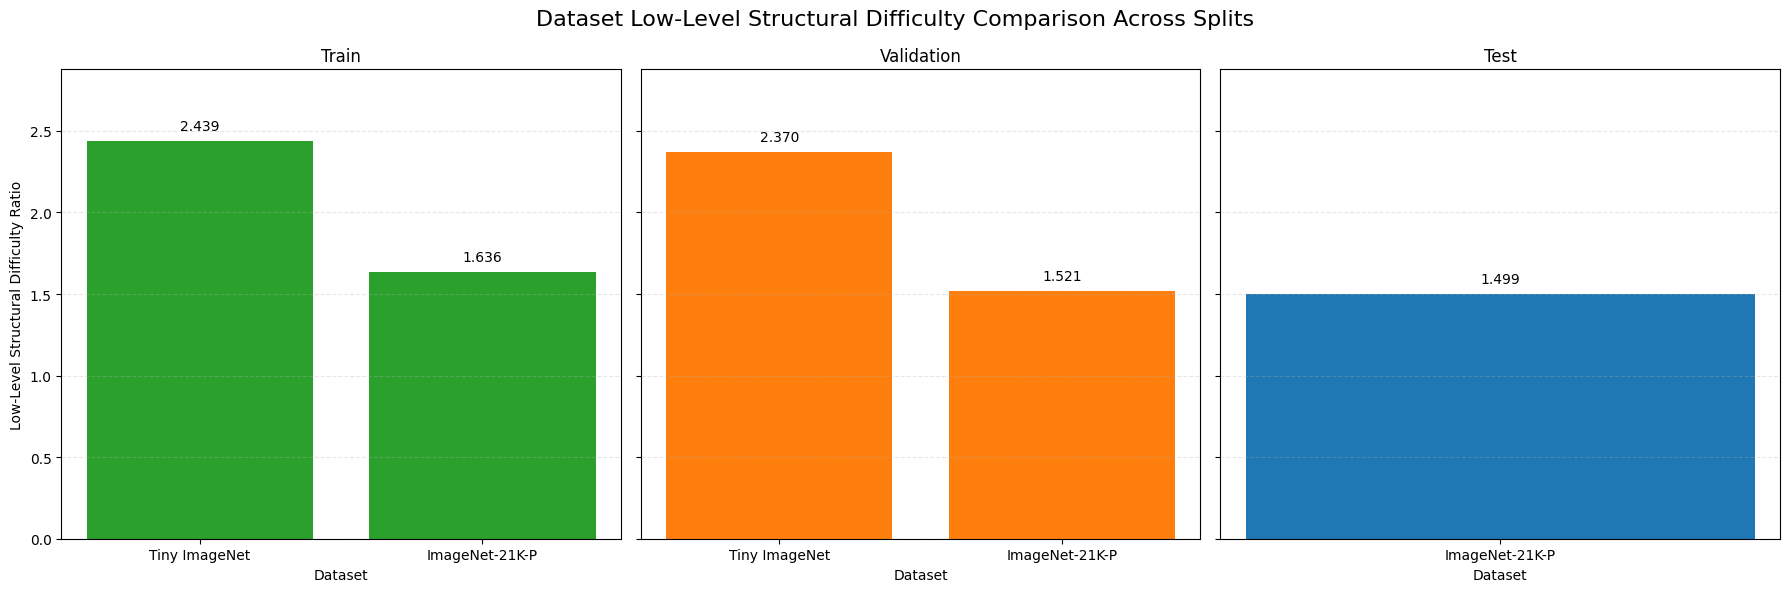

In [71]:
dataset_difficulty_analysis.plot_structural_difficulty(
    difficulty_stats
)

##### Class imbalance graph

Class imbalance plots: 100%|██████████| 3/3 [00:00<00:00, 392.97it/s]


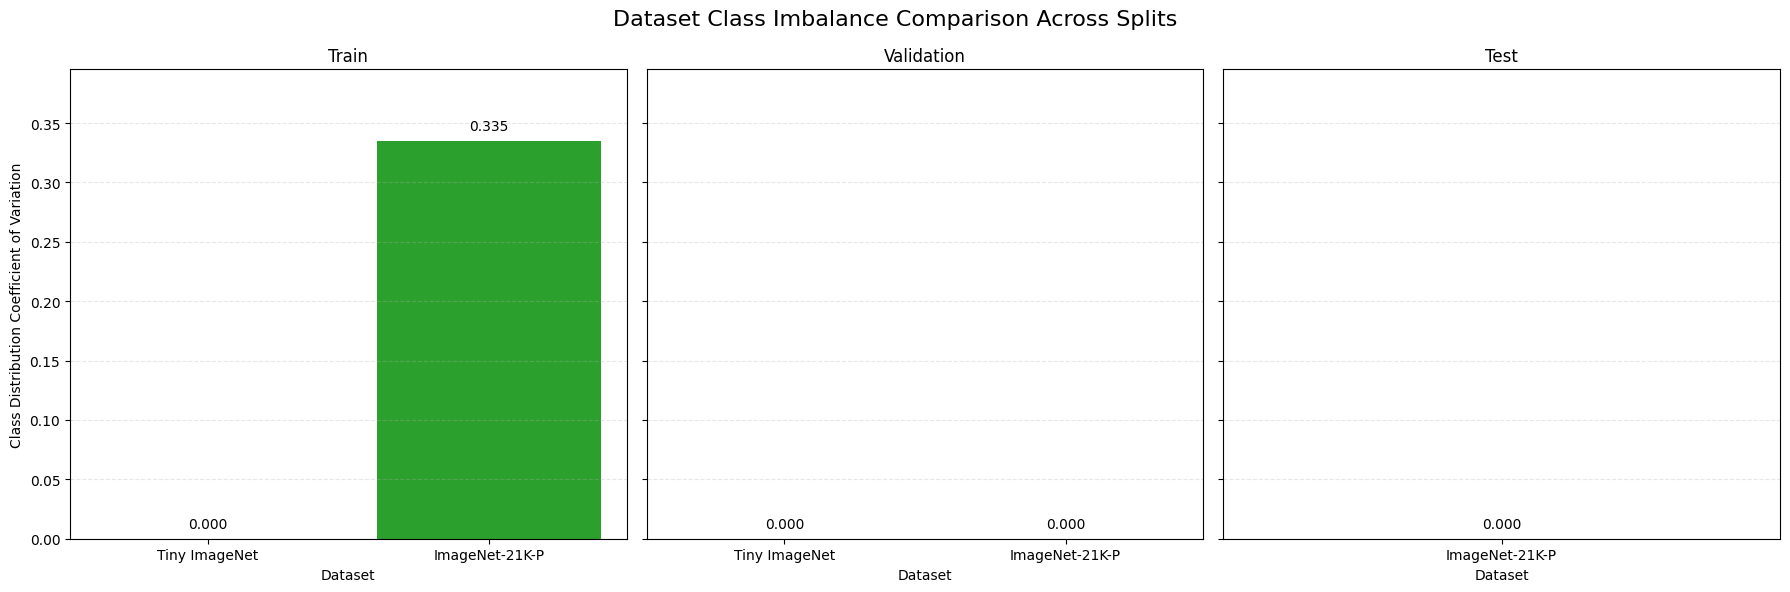

In [72]:
dataset_difficulty_analysis.plot_class_imbalance_difficulty(
    difficulty_stats
)

##### Resolution diversity graph

Resolution diversity plots: 100%|██████████| 3/3 [00:00<00:00, 371.06it/s]


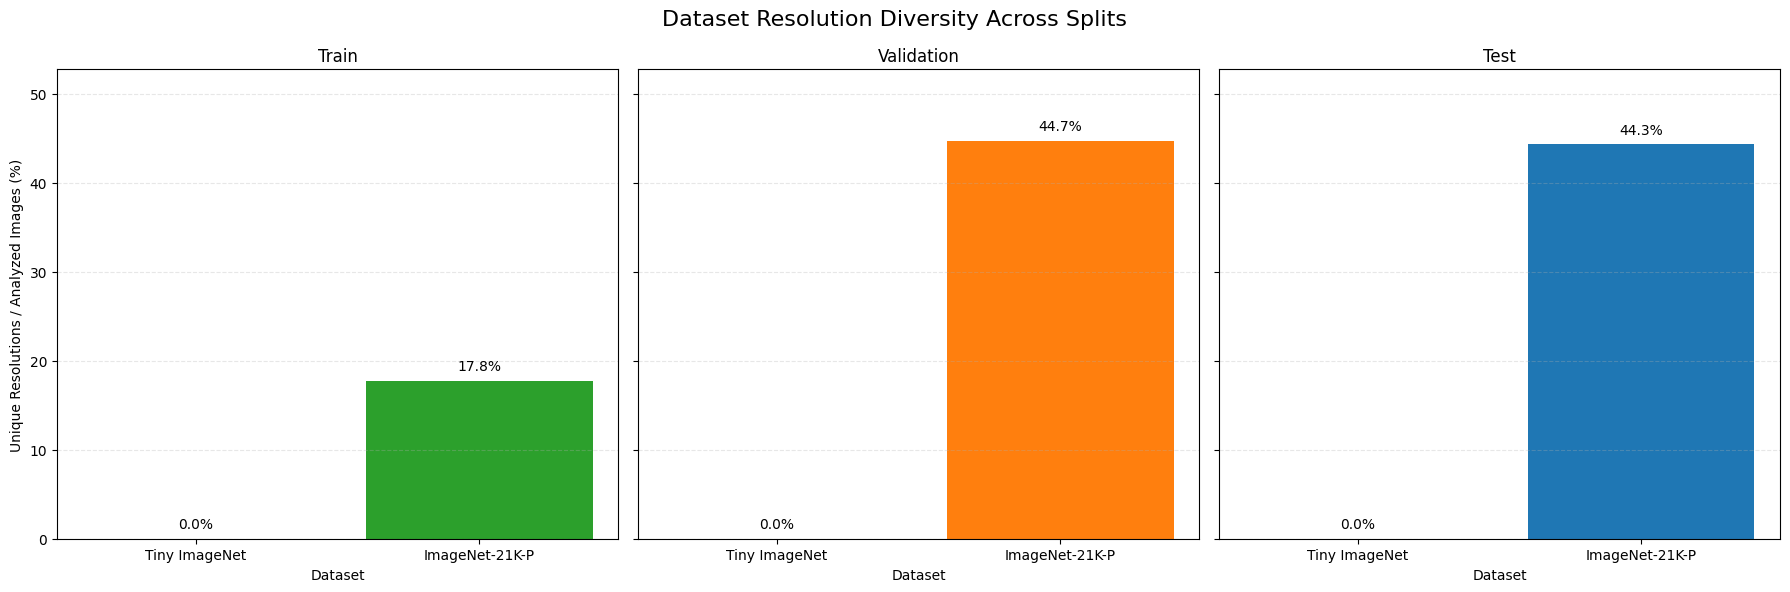

In [73]:
dataset_difficulty_analysis.plot_resolution_diversity(
    difficulty_stats
)

### 19: Data Cleaning & Preprocessing

##### 19 A–E cleaning actually passed before touching normalization.

In [74]:
import importlib

from pathlib import Path
import src.data_cleaning_and_preprocessing.data_cleaning as data_cleaning

importlib.reload(data_cleaning)

<module 'src.data_cleaning_and_preprocessing.data_cleaning' from '/Users/sumanneupane/Documents/MIT in AI/Semister 4/cnn_vs_pc_cnn/src/data_cleaning_and_preprocessing/data_cleaning.py'>

In [75]:
dataset_roots = {
    "tiny_imagenet": Path(TINY_ROOT),
    "imagenet21k_p": Path(IMAGENET21K_P_ROOT),
}

clean_results = data_cleaning.clean_datasets(
    [
        tiny_imagenet,
        imagenet_21k_p,
    ],
    duplicate_details,
    dataset_roots,
    imagenet21k_min_images_per_class=3,
    seed=42,
)

Cleaning datasets: 100%|██████████| 2/2 [00:08<00:00,  4.34s/it]


In [76]:
clean_results["cleaning_summary"]

,Dataset,Split,Original Images,Clean Images,Net Change
0,tiny_imagenet,Train,100000,99953,-47
1,tiny_imagenet,Validation,10000,9993,-7
2,tiny_imagenet,Test,10000,9988,-12
3,imagenet21k_p,Train,203329,201319,-2010
4,imagenet21k_p,Validation,5000,4958,-42
5,imagenet21k_p,Test,5000,4977,-23


In [77]:
clean_results["verification"]

,Dataset,Split,Images,Classes,Duplicate Groups
0,tiny_imagenet,Train,99953,200,0
1,tiny_imagenet,Validation,9993,200,0
2,tiny_imagenet,Test,9988,N/A,0
3,imagenet21k_p,Train,201319,200,0
4,imagenet21k_p,Validation,4958,200,0
5,imagenet21k_p,Test,4977,200,0


In [78]:
clean_results["removal_reason_summary"]

,Dataset,Reason,Removed Images
0,tiny_imagenet,Cross-Split Leakage,10
1,tiny_imagenet,Label Conflict,54
2,tiny_imagenet,Within-Split Duplicate,2
3,imagenet21k_p,Cross-Split Leakage,105
4,imagenet21k_p,Label Conflict,966
5,imagenet21k_p,Within-Split Duplicate,1004


In [79]:
clean_results["audit_summary"]

,Dataset,Original Images,Clean Images,Removed Images,Manifest Entries,Audit Status
0,tiny_imagenet,120000,119934,66,66,Passed
1,imagenet21k_p,213329,211254,2075,2075,Passed


In [80]:
clean_results["leakage_verification"]

,Dataset,Train ↔ Validation,Train ↔ Test,Validation ↔ Test,Status
0,tiny_imagenet,0,0,0,Passed
1,imagenet21k_p,0,0,0,Passed


In [81]:
clean_results["conflicts"]["tiny_imagenet"]

,Dataset,Hash,Split,Image Index,Target,Labelled Targets
0,tiny_imagenet,009f48ae262f3d83fc1103e54998c046b3a029a98eb0c5...,Train,87271,174,"[174, 175]"
1,tiny_imagenet,009f48ae262f3d83fc1103e54998c046b3a029a98eb0c5...,Train,87649,175,"[174, 175]"
2,tiny_imagenet,0226189805b100c31f8ccb8a1b1c465c0aedc40a89ad70...,Train,91457,182,"[182, 190]"
3,tiny_imagenet,0226189805b100c31f8ccb8a1b1c465c0aedc40a89ad70...,Train,95376,190,"[182, 190]"
4,tiny_imagenet,083118a5bbd48877661e067f24d7988a61bc47e5d7e283...,Train,5879,11,"[11, 20]"
5,tiny_imagenet,083118a5bbd48877661e067f24d7988a61bc47e5d7e283...,Validation,1006,20,"[11, 20]"
6,tiny_imagenet,1699ec8fb9ed0deadd11792413383c4130f274108d6df8...,Train,55355,110,"[110, 149]"
7,tiny_imagenet,1699ec8fb9ed0deadd11792413383c4130f274108d6df8...,Train,74725,149,"[110, 149]"
8,tiny_imagenet,24950b78fcc0e2ad486cf2982ad02d4b3f9cf6e020e8c0...,Train,66443,132,"[101, 132]"
9,tiny_imagenet,24950b78fcc0e2ad486cf2982ad02d4b3f9cf6e020e8c0...,Validation,5056,101,"[101, 132]"


In [82]:
clean_results["conflicts"]["imagenet21k_p"]

,Dataset,Hash,Split,Image Index,Target,Labelled Targets
0,imagenet21k_p,0025061b607afce3ac9650c68b580400f9eccbddf05a0d...,Train,24908,22,"[22, 23]"
1,imagenet21k_p,0025061b607afce3ac9650c68b580400f9eccbddf05a0d...,Train,26527,23,"[22, 23]"
2,imagenet21k_p,00449fd78c0b96c799d770279aa53d6728b57492d21dd4...,Train,70204,64,"[64, 74]"
3,imagenet21k_p,00449fd78c0b96c799d770279aa53d6728b57492d21dd4...,Train,80469,74,"[64, 74]"
4,imagenet21k_p,005eae4b12cc6e9498478187a403a07a59aeff4daa6f62...,Train,191343,186,"[186, 187]"
...,...,...,...,...,...,...
961,imagenet21k_p,fec187081718a35b19e4f4ba5f3b6ec35c788e11902de2...,Train,25950,23,"[22, 23]"
962,imagenet21k_p,fec93dd039040a0ef8778e208426d1e5cf81449e9c5a4f...,Train,11717,9,"[9, 10]"
963,imagenet21k_p,fec93dd039040a0ef8778e208426d1e5cf81449e9c5a4f...,Train,13039,10,"[9, 10]"
964,imagenet21k_p,ff0b93ab53a2c5e564059bd2d3ab329ea6166e1b0807cd...,Train,25236,22,"[22, 23]"


In [83]:
clean_tiny_imagenet = clean_results["datasets"][0]
clean_imagenet_21k_p = clean_results["datasets"][1]

##### 19. F. Spatial Preprocessing

In [84]:
import importlib
import src.data_cleaning_and_preprocessing.image_resize as image_resize

importlib.reload(image_resize)

<module 'src.data_cleaning_and_preprocessing.image_resize' from '/Users/sumanneupane/Documents/MIT in AI/Semister 4/cnn_vs_pc_cnn/src/data_cleaning_and_preprocessing/image_resize.py'>

In [85]:
clean_dataset_lists = [
    clean_tiny_imagenet,
    clean_imagenet_21k_p,
]

In [86]:
resized_datasets = image_resize.resize_datasets(clean_dataset_lists)

Preparing resized datasets: 100%|██████████| 2/2 [00:00<00:00, 32388.45it/s]


In [87]:
resize_verification = image_resize.verify_image_sizes(
    resized_datasets
)

resize_verification

imagenet21k_p: verifying sizes: 100%|██████████| 3/3 [06:23<00:00, 127.71s/it]


,Dataset,Split,Total Images,Expected Shape,Unique Shapes,3-Channel Images,Invalid Images,Status
0,tiny_imagenet,Train,99953,3 × 224 × 224,1,99953,0,Passed
1,tiny_imagenet,Validation,9993,3 × 224 × 224,1,9993,0,Passed
2,tiny_imagenet,Test,9988,3 × 224 × 224,1,9988,0,Passed
3,imagenet21k_p,Train,201319,3 × 224 × 224,1,201319,0,Passed
4,imagenet21k_p,Validation,4958,3 × 224 × 224,1,4958,0,Passed
5,imagenet21k_p,Test,4977,3 × 224 × 224,1,4977,0,Passed


##### 19. G Train-Only Normalization

In [88]:
import importlib
import src.data_cleaning_and_preprocessing.normalization_statistics as normalization_statistics

importlib.reload(normalization_statistics)

<module 'src.data_cleaning_and_preprocessing.normalization_statistics' from '/Users/sumanneupane/Documents/MIT in AI/Semister 4/cnn_vs_pc_cnn/src/data_cleaning_and_preprocessing/normalization_statistics.py'>

In [89]:
normalization_stats, normalization_summary = (
    normalization_statistics.compute_normalization_statistics(
        resized_datasets,
        batch_size=64,
        num_workers=0,
    )
)
normalization_summary

Computing Train normalization statistics: 100%|██████████| 2/2 [08:19<00:00, 249.72s/it]


,Dataset,Train Images,Mean R,Mean G,Mean B,Std R,Std G,Std B,Min Pixel,Max Pixel
0,tiny_imagenet,99953,0.480225,0.448059,0.397521,0.266165,0.258236,0.271813,0.0,1.000000
1,imagenet21k_p,201319,0.502246,0.480837,0.425286,0.290523,0.284098,0.304992,0.0,1.000001


In [90]:
normalization_statistics.save_normalization_statistics(
    normalization_stats,
    dataset_roots,
)

tiny_imagenet: saved data/tiny_imagenet/preprocessing/normalization.json
imagenet21k_p: saved data/imagenet21k_p/preprocessing/normalization.json


##### Apply normalization

In [91]:
import importlib
import src.data_cleaning_and_preprocessing.image_normalization as image_normalization

importlib.reload(image_normalization)

<module 'src.data_cleaning_and_preprocessing.image_normalization' from '/Users/sumanneupane/Documents/MIT in AI/Semister 4/cnn_vs_pc_cnn/src/data_cleaning_and_preprocessing/image_normalization.py'>

In [92]:
normalized_datasets = image_normalization.normalize_datasets(
    resized_datasets,
    normalization_stats,
)

Applying normalization: 100%|██████████| 2/2 [00:00<00:00, 8065.97it/s]


##### Verify

In [93]:
normalization_verification = image_normalization.verify_normalization(
    normalized_datasets,
    batch_size=64,
    num_workers=0,
)

normalization_verification

imagenet21k_p: verifying normalization: 100%|██████████| 3/3 [07:39<00:00, 153.00s/it]


,Dataset,Split,Images,Mean R,Mean G,Mean B,Std R,Std G,Std B,Invalid Images,Status
0,tiny_imagenet,Train,99953,-4.121397e-08,-1.475161e-08,3.489721e-08,1.000000,1.000000,1.000000,0,Passed
1,tiny_imagenet,Validation,9993,7.879440e-03,5.205313e-03,1.576028e-03,1.000339,1.001149,1.003290,0,Passed
2,tiny_imagenet,Test,9988,-3.195371e-02,-2.532038e-02,-2.005761e-02,0.991979,0.992577,0.988355,0,Passed
3,imagenet21k_p,Train,201319,-2.672332e-08,1.171737e-08,-3.676739e-08,1.000000,1.000000,1.000000,0,Passed
4,imagenet21k_p,Validation,4958,4.574072e-03,6.165473e-03,4.872871e-03,0.998592,0.996178,0.998899,0,Passed
5,imagenet21k_p,Test,4977,-2.074605e-02,-1.018198e-02,-1.003371e-02,0.997837,0.992838,0.995564,0,Passed


#### 19.I Final Dataset Documentation

In [94]:
import src.data_cleaning_and_preprocessing._model_ready_dataset as model_ready_dataset
import importlib
importlib.reload(model_ready_dataset)

<module 'src.data_cleaning_and_preprocessing._model_ready_dataset' from '/Users/sumanneupane/Documents/MIT in AI/Semister 4/cnn_vs_pc_cnn/src/data_cleaning_and_preprocessing/_model_ready_dataset.py'>

In [95]:
cleaned_tiny_imagenet = model_ready_dataset.ModelReadyDatasetLoader(
    TinyImageNetLoader(
        seed=42
    )
).load()

In [96]:
cleaned_imagenet_21k_p = model_ready_dataset.ModelReadyDatasetLoader(
    ImageNet21KPLoader(
        mode="sample",
        sample_classes=200,
        train_images_per_class=None,
        seed=42,
    )
).load()


ImageNet-21K-P Winter21 Sample
-------------------------------------------------------
Classes               : 200
Train images/class    : ALL
Expected train        : depends on selected classes
Validation/class      : 50
Expected validation   : 10,000
Output folder         : data/imagenet21k_p/images
-------------------------------------------------------


Building ImageNet-21K-P sample: 100%|██████████| 200/200 [00:03<00:00, 55.04class/s, wnid=n14765422]


In [97]:
cleaned_dataset_list = [
    cleaned_tiny_imagenet,
    cleaned_imagenet_21k_p,
]

In [98]:
model_ready_verification = (
    model_ready_dataset.verify_model_ready_datasets(
        dataset_list=cleaned_dataset_list,
        max_images=None,
        seed=42,
    )
)
model_ready_verification

tiny_imagenet Train: 100%|█████████▉| 99794/99953 [00:49<00:00, 2072.95it/s]
                                                                            
tiny_imagenet Validation:  99%|█████████▉| 9871/9993 [00:05<00:00, 1754.33it/s]
                                                                               
imagenet21k_p Train: 100%|█████████▉| 201283/201319 [06:59<00:00, 449.80it/s]
                                                                             
imagenet21k_p Validation: 100%|█████████▉| 4945/4958 [00:11<00:00, 401.89it/s]
                                                                              
Model-ready datasets: 100%|██████████| 2/2 [08:23<00:00, 251.75s/it]    


,Dataset,Split,Total Images,Verified Images,Classes,Expected Shape,Invalid Shape,Invalid Channels,Invalid Values,Invalid Targets,Status
0,tiny_imagenet,Train,99953,99953,200,3 × 224 × 224,0,0,0,0,Passed
1,tiny_imagenet,Validation,9993,9993,200,3 × 224 × 224,0,0,0,0,Passed
2,tiny_imagenet,Test,9988,9988,N/A,3 × 224 × 224,0,0,0,N/A,Passed
3,imagenet21k_p,Train,201319,201319,200,3 × 224 × 224,0,0,0,0,Passed
4,imagenet21k_p,Validation,4958,4958,200,3 × 224 × 224,0,0,0,0,Passed
5,imagenet21k_p,Test,4977,4977,200,3 × 224 × 224,0,0,0,0,Passed


# From above eda, we have found below lists we have already done, or dont have to do

| Stage | Analysis Area                     | Detailed Analysis Steps                                                                                                                                                                                                                            | Status   |
| ----- | --------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------- |
| **A** | **Corrupted Image Check**         | **1.** Full Corruption Scan  <br> **2.** Corrupted Image Verification  <br> **3.** Current Result: 0 Corrupted Images                                                                                                                              | **Done** |
| **B** | **RGB / Channel Standardization** | **4.** Tiny ImageNet RGB Conversion  <br> **5.** ImageNet-21K RGB Conversion During Processing and Loading  <br> **6.** ImageNet-21K-P RGB Conversion During Processing and Loading  <br> **7.** Grayscale / CMYK to 3-Channel RGB Standardization | **Done** |
| **C** | **Image Size Standardization**    | **8.** Resize All Datasets to 224 × 224  <br> **9.** Antialiased Image Resizing  <br> **10.** Final Model Input Standardization to 3 × 224 × 224                                                                                                   | **Done** |
| **D** | **Statistical Outlier Decision**  | **11.** Review Brightness, Contrast and Sharpness Outliers  <br> **12.** Review Dimension and Aspect-Ratio Outliers  <br> **13.** Preserve Valid Statistical Outliers and Natural Image Variation                                                  | **Done** |


Already resolved, so we do not redo them
Corrupted images: 0 found ✅
RGB/channel standardization: 100% RGB at loader output ✅
Statistical outliers: preserve, do not automatically remove ✅
Natural brightness/contrast/sharpness variation: preserve ✅
Class imbalance: handle later during training, not by cleaning ✅

# Step 19: Data Cleaning & Preprocessing

| Stage | Analysis Area                            | Detailed Steps                                                                                                                                                                                                             | Status  |
| ----- | ---------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------- |
| **A** | **Duplicate Cleaning**                   | **1.** Resolve exact within-split duplicates <br> **2.** Keep one appropriate representative per duplicate group                                                                                                           | Pending |
| **B** | **Cross-Split Leakage Cleaning**         | **3.** Resolve Train ↔ Validation leakage <br> **4.** Resolve Train ↔ Test leakage <br> **5.** Resolve Validation ↔ Test leakage <br> **6.** Achieve zero cross-split exact-content leakage                                | Pending |
| **C** | **Label-Conflict Review**                | **7.** Review duplicate groups with different labels <br> **8.** Determine genuine annotation conflict vs legitimate synset overlap <br> **9.** Record final keep/remove decision                                          | Pending |
| **D** | **Rare-Class & Class-Coverage Handling** | **10.** Recheck class counts after cleaning <br> **11.** Handle ImageNet-21K classes with insufficient samples <br> **12.** Validate Train/Validation/Test class coverage                                                  | Pending |
| **E** | **Clean Split Construction**             | **13.** Build final clean Train indices <br> **14.** Build final clean Validation indices <br> **15.** Build final clean Test indices                                                                                      | Pending |
| **F** | **Spatial Preprocessing**                | **16.** Standardize final model input size to 224 × 224 when model preprocessing is activated <br> **17.** Use identical spatial preprocessing for CNN and PC-CNN                                                          | Pending |
| **G** | **Train-Only Normalization**             | **18.** Calculate RGB mean from clean Train only <br> **19.** Calculate RGB standard deviation from clean Train only <br> **20.** Apply Train-derived normalization to Train, Validation and Test                          | Pending |
| **H** | **Post-Cleaning Verification**           | **21.** Recheck corrupted images <br> **22.** Recheck exact duplicates <br> **23.** Recheck cross-split leakage <br> **24.** Recheck class coverage <br> **25.** Verify final tensor channels/dimensions and normalization | Pending |
| **I** | **Final Dataset Documentation**          | **26.** Recalculate final image/class statistics <br> **27.** Save cleaning manifest <br> **28.** Save final clean split information <br> **29.** Save normalization statistics <br> **30.** Declare datasets model-ready  | Pending |


# Whole CNN vs PC-CNN thesis project

| Project Phase                                                    | Approx. Weight | Current Status |
| ---------------------------------------------------------------- | -------------: | -------------- |
| Research problem, objectives, experimental design                |             5% | ✅ Done         |
| Dataset selection, loaders, download pipeline, unified interface |            10% | ✅ Mostly done  |
| Dataset EDA Steps 1–18                                           |            20% | ✅ **Done**     |
| Data cleaning & preprocessing                                    |            10% | ⏭️ Next        |
| Standard CNN implementation & tuning                             |            10% | ⏳              |
| Full PC-CNN implementation & tuning                              |            12% | ⏳              |
| Clean-image baseline experiments                                 |             8% | ⏳              |
| Gaussian noise experiments                                       |             7% | ⏳              |
| Salt-and-Pepper noise experiments                                |             7% | ⏳              |
| CNN vs PC-CNN robustness analysis                                |             5% | ⏳              |
| Statistical analysis, figures, tables                            |             3% | ⏳              |
| Final dissertation results/discussion/conclusion                 |             3% | ⏳              |
